# BC카드 업종별 소비구조·공급·폐업 전체 분석

2026년 1~6월 BC카드 결제자료와 주민인구, 소진공 상가정보, 국세청·LOCALDATA 공급·폐업, 등록외국인을 연결한 **발표용 단일 재현 노트북**입니다.

이 파일 하나에 데이터 검증, 공통 전처리, 11개 업종 동일 포맷 분석, 외부데이터 결합, 15개 추가 분석, 결론 검증을 모두 담았습니다.


## 실행 방법과 발표 순서

1. Jupyter 또는 VS Code에서 이 파일을 엽니다.
2. `Restart Kernel and Run All`을 실행합니다.
3. 노트북은 `../data`만 읽으며 인터넷·API 호출을 하지 않습니다.
4. 15개 상세 CSV는 실행 후 `../data/분석결과/`에 생성됩니다.

발표는 `문제정의 → 전처리 → 전체 흐름 → 11개 업종 → 외부자료 → 15개 심화분석 → 폐업정보 사용법 → 제한`의 순서로 진행합니다.


## 0. 해석 원칙

- `CNT`는 고객 수나 방문자 수가 아니라 **결제건수**입니다.
- `AMT/CNT`는 가격·마진·이익이 아니라 **건당 평균 결제금액**입니다.
- 6개월의 로그선형 기울기는 전년동월 증감률이 아니며 장기추세로 일반화하지 않습니다.
- 소진공 상가수는 2026년 9월 현재 스냅샷이며 2026년 1~6월 공급변화가 아닙니다.
- 국세청 사업자·LOCALDATA 인허·소진공 상가·BC 가맹점은 모집단이 서로 다릅니다.
- 폐업은 개별 점포 예측값이 아니라 **지역×업종 교체압력**으로 사용합니다.


## 1. 환경 설정과 상대경로

절대경로나 개인 API 키를 사용하지 않습니다. 발표용 폴더를 다른 컴퓨터로 옮겨도 같은 구조라면 실행됩니다.


In [1]:
from pathlib import Path
import json
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from scipy.stats import linregress, spearmanr
from IPython.display import display, Markdown

warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.unicode_minus'] = False
# OS별로 실제 설치된 한글 글꼴 하나만 선택: 미설치 글꼴 findfont 경고 방지
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
font_candidates = ['Apple SD Gothic Neo', 'AppleGothic', 'Malgun Gothic', 'NanumGothic',
                   'Noto Sans CJK KR', 'Noto Sans KR', 'DejaVu Sans']
KOREAN_FONT = next(font for font in font_candidates if font in available_fonts)
plt.rcParams['font.family'] = KOREAN_FONT
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

# code/ 또는 발표용/ 어디에서 실행해도 data/ 찾기
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
PRESENTATION_ROOT = next((p for p in candidates if (p/'data'/'BC카드_제공데이터'/'ABP_CONTEST_DATA.csv').exists()), None)
if PRESENTATION_ROOT is None:
    raise FileNotFoundError('발표용/data/BC카드_제공데이터/ABP_CONTEST_DATA.csv를 찾지 못했습니다.')
DATA_ROOT = PRESENTATION_ROOT/'data'
BC_PATH = DATA_ROOT/'BC카드_제공데이터'/'ABP_CONTEST_DATA.csv'
EXT = DATA_ROOT/'외부데이터'
OUTPUT_DIR = DATA_ROOT/'분석결과'
OUTPUT_DIR.mkdir(exist_ok=True)
print('matplotlib font:', KOREAN_FONT)
print('presentation root:', PRESENTATION_ROOT.resolve())
print('BC data:', BC_PATH.resolve())
print('external data:', EXT.resolve())


matplotlib font: Apple SD Gothic Neo
presentation root: /Users/chanhopark/Desktop/Code/BC금융공모전/발표용
BC data: /Users/chanhopark/Desktop/Code/BC금융공모전/발표용/data/BC카드_제공데이터/ABP_CONTEST_DATA.csv
external data: /Users/chanhopark/Desktop/Code/BC금융공모전/발표용/data/외부데이터


## 2. 외부데이터 구성

외부자료는 BC 소비를 대신하지 않고, 소비변화가 주민구성·공급·시장교체와 같이 나타나는지를 확인하는 보조근거입니다.

- 핵심: 주민등록 연령인구, 정확 업종 월별 공급, 소진공 현재 공급, 국세청·LOCALDATA 개폐업
- 보조: 등록외국인, CPI, 기상, 생활인구, 임대료·공실
- 출처·재취득: `../data/외부데이터/외부데이터_출처_및_재취득_방법.md`


In [2]:
source_doc = EXT/'외부데이터_출처_및_재취득_방법.md'
print(source_doc.read_text(encoding='utf-8').split('## 2.')[0])


# 발표용 외부데이터 출처·재취득·활용 방법

기준일: 2026-09-09  
분석 기간: BC 소비 2026.01~06

이 문서는 발표용 단일 노트북이 사용하는 외부자료와, 분석에서 검토했지만 핵심 결론에서 제외한 자료를 모두 정리한다. 인증키는 공유 파일에 포함하지 않는다.

## 1. 자료별 매칭표

| 자료 | 공식 기관·출처 | 로컬 위치 | 실제 범위 | 노트북 역할 | 재취득 |
|---|---|---|---|---|---|
| 주민등록 연령인구 | [행정안전부 주민등록 인구통계](https://jumin.mois.go.kr/ageStatMonth.do) | `행정안전부_주민등록인구/` | 2026.01~06, 251/255 BC 지역 | 연령별 소비비중·주민인구 비교 | 월별·연령별 인구현황에서 2026.01~06 CSV 다운로드 |
| 국세청 월간 지역 경제지표 | [국세통계포털 TASIS](https://tasis.nts.go.kr/) | `국세청_7업종_공급개폐업/`, `폐업_전국/raw/nts/` | 2026.01~06 | 가동사업자·신규·폐업·회전률 | TASIS에서 각 월 `월간 지역 경제지표` Excel 다운로드 |
| LOCALDATA 일반·휴게음식점, 제과점 | [행정안전부 LOCALDATA](https://www.localdata.go.kr/) / [일반음식점](https://www.data.go.kr/data/15045016/fileData.do) / [휴게음식점](https://www.data.go.kr/data/15006730/fileData.do) / [제과점](https://www.data.go.kr/data/15006688/fileData.do) | `폐업_전국/raw/localdata/` | 현재 전국 스냅샷의 인허일·폐업일로 2026.01~06 재구성 | 중국음식·제과점 폐업압력, 개·폐업 회전률 | 공공데이터포털 파일데이터 또는 LOCALDATA 전국파일 다운로드 |
| LOCALDATA 대규모·준대규모점포 외

## 3. BC 원본 로딩·품질검사·공통 함수

먼저 9개 필수 컬럼, 2026.01~06, 11개 업종, 음수 금액·건수 여부를 검사합니다. 월평균 성장률은 6개 월 값에 `log(y)=a+b·t`를 적합한 뒤 `100·(exp(b)-1)`로 계산합니다. 같은 산식을 금액·건수·건당금액에 모두 적용합니다.


In [3]:
SEMAS_PATH = EXT/'소진공_상가정보_공급스냅샷'/'05_industry_national_counts.csv'
NTS_PATH = EXT/'국세청_7업종_공급개폐업'/'01_national_monthly.csv'

# 1) 분석 설정
MONTHS = list(range(202601, 202607))
INDUSTRY_NAMES = {4004:'대형할인점', 4010:'편의점', 4020:'슈퍼마켓', 8001:'일반한식',
                  8002:'갈비전문점', 8003:'한정식', 8004:'일식회집', 8005:'중국음식',
                  8006:'서양음식', 8021:'스넥', 8301:'제과점'}
GENDER_LABELS = {'1':'남성', '2':'여성', '3':'외국인', 'x':'법인'}
AGE_LABELS = {'1':'20대 이하', '2':'20대', '3':'30대', '4':'40대', '5':'50대', '6':'60대 이상'}
REQUIRED = ['STRD_YYMM','TP_BUZ_NO','TP_BUZ_NM','SIDO_NM','CCG_NM','GENDER_CD','AGE_CD','amt','cnt']

# 2) 원본 로딩과 최소 정제
data = pd.read_csv(BC_PATH, dtype={'GENDER_CD':'string', 'AGE_CD':'string'})
missing_columns = sorted(set(REQUIRED) - set(data.columns))
assert not missing_columns, f'필수 컬럼 누락: {missing_columns}'
data = data[REQUIRED].copy()
data['TP_BUZ_NM'] = data.TP_BUZ_NM.astype(str).str.replace(' ', '', regex=False)
data['STRD_YYMM'] = pd.to_numeric(data.STRD_YYMM, errors='raise').astype(int)
data['TP_BUZ_NO'] = pd.to_numeric(data.TP_BUZ_NO, errors='raise').astype(int)
data[['amt','cnt']] = data[['amt','cnt']].apply(pd.to_numeric, errors='raise')
assert sorted(data.STRD_YYMM.unique().tolist()) == MONTHS
assert not (data[['amt','cnt']] < 0).any().any()
assert set(data.TP_BUZ_NO.unique()) == set(INDUSTRY_NAMES)

# 3) 공통 계산 함수: 모든 업종에 같은 산식 적용
def add_ticket(frame):
    result = frame.copy()
    result['avg_ticket'] = result.amt / result.cnt.replace(0, np.nan)
    return result

def log_trend(values):
    y = np.asarray(values, dtype=float)
    if len(y) < 2 or np.isnan(y).any() or (y <= 0).any():
        return {'growth_pct_m':np.nan, 'r2':np.nan, 'fitted_change_pct':np.nan}
    x = np.arange(len(y), dtype=float)
    slope, intercept = np.polyfit(x, np.log(y), 1)
    fitted = intercept + slope*x
    ss_res = np.square(np.log(y)-fitted).sum(); ss_tot = np.square(np.log(y)-np.log(y).mean()).sum()
    return {'growth_pct_m':np.expm1(slope)*100, 'r2':np.nan if ss_tot==0 else 1-ss_res/ss_tot,
            'fitted_change_pct':np.expm1(slope*(len(y)-1))*100}

def decompose(frame):
    frame = frame.sort_values('STRD_YYMM')
    a, c, t = log_trend(frame.amt), log_trend(frame.cnt), log_trend(frame.avg_ticket)
    return {'amt_growth_pct_m':a['growth_pct_m'], 'amt_r2':a['r2'],
            'cnt_growth_pct_m':c['growth_pct_m'], 'cnt_r2':c['r2'],
            'ticket_growth_pct_m':t['growth_pct_m'], 'ticket_r2':t['r2'],
            'amt_fitted_change_pct':a['fitted_change_pct'],
            'cnt_fitted_change_pct':c['fitted_change_pct'],
            'ticket_fitted_change_pct':t['fitted_change_pct']}

def pattern(row):
    return f"결제건수 {'증가' if row['cnt_growth_pct_m']>=0 else '감소'}·건당금액 {'증가' if row['ticket_growth_pct_m']>=0 else '감소'}"

def segment_table(target, code_column, labels):
    monthly = target.groupby([code_column,'STRD_YYMM'], as_index=False)[['amt','cnt']].sum()
    total = target.groupby(code_column, as_index=False)[['amt','cnt']].sum()
    total['amt_share_pct'] = total.amt/total.amt.sum()*100
    total['cnt_share_pct'] = total.cnt/total.cnt.sum()*100
    total['avg_ticket'] = total.amt/total.cnt
    trends=[]
    for code, group in monthly.groupby(code_column):
        row=decompose(add_ticket(group)); row[code_column]=code; trends.append(row)
    result=total.merge(pd.DataFrame(trends), on=code_column, how='left')
    result['segment']=result[code_column].astype(str).map(labels).fillna('기타/미상')
    return result.sort_values('amt_share_pct', ascending=False)

def region_table(target):
    monthly=add_ticket(target.groupby(['SIDO_NM','CCG_NM','STRD_YYMM'],as_index=False)[['amt','cnt']].sum())
    rows=[]
    for (sido,region),group in monthly.groupby(['SIDO_NM','CCG_NM']):
        group=group.sort_values('STRD_YYMM')
        if group.STRD_YYMM.nunique()!=6: continue
        row=decompose(group); row.update(SIDO_NM=sido,CCG_NM=region,total_amt_6m=group.amt.sum(),total_cnt_6m=group.cnt.sum()); rows.append(row)
    return pd.DataFrame(rows).sort_values('amt_growth_pct_m',ascending=False)

# 4) 전체 및 업종별 월 자료
overall_monthly = add_ticket(data.groupby('STRD_YYMM',as_index=False)[['amt','cnt']].sum())
industry_monthly = add_ticket(data.groupby(['TP_BUZ_NO','TP_BUZ_NM','STRD_YYMM'],as_index=False)[['amt','cnt']].sum())
total = industry_monthly.groupby(['TP_BUZ_NO','TP_BUZ_NM'],as_index=False)[['amt','cnt']].sum()
total['amt_share_pct']=total.amt/total.amt.sum()*100; total['cnt_share_pct']=total.cnt/total.cnt.sum()*100; total['avg_ticket_6m']=total.amt/total.cnt
trend_rows=[]
for (code,name),group in industry_monthly.groupby(['TP_BUZ_NO','TP_BUZ_NM']):
    row=decompose(group); row.update(TP_BUZ_NO=code,TP_BUZ_NM=name,peak_month=int(group.loc[group.amt.idxmax(),'STRD_YYMM']),low_month=int(group.loc[group.amt.idxmin(),'STRD_YYMM'])); row['growth_pattern']=pattern(row); trend_rows.append(row)
overview=total.merge(pd.DataFrame(trend_rows),on=['TP_BUZ_NO','TP_BUZ_NM']).sort_values('TP_BUZ_NO')

# 5) 복구 검증을 통과한 핵심 외부자료 캐시 로딩
# 소진공은 2026.09 현재 공급수준이라는 원래 정의 그대로 사용한다(상반기 공급변화로 해석하지 않음).
semas=pd.read_csv(SEMAS_PATH) if SEMAS_PATH.exists() else pd.DataFrame(columns=['BC업종','점포수'])
semas=semas.rename(columns={'BC업종':'TP_BUZ_NM','점포수':'current_store_count'})
# 국세청은 2026.01~06 월별 원본 6개와 해시가 보존되어 동일 결과를 복구할 수 있다.
nts=pd.read_csv(NTS_PATH) if NTS_PATH.exists() else pd.DataFrame()
nts_rows=[]
if not nts.empty:
    for (code,name),group in nts.groupby(['TP_BUZ_NO','TP_BUZ_NM']):
        group=group.sort_values('STRD_YYMM'); start=group.active_current.iloc[0]; end=group.active_current.iloc[-1]
        nts_rows.append({'TP_BUZ_NO':int(code),'TP_BUZ_NM':name,'active_business_jan':start,'active_business_jun':end,
                         'active_business_change_pct':(end/start-1)*100,'openings_6m':group.open_current.sum(min_count=1),
                         'closures_6m':group.close_current.sum(min_count=1),'net_open_close_6m':group.net_business_change.sum(min_count=1)})
external=semas.merge(pd.DataFrame(nts_rows),on='TP_BUZ_NM',how='outer') if nts_rows else semas

# 6) 업종별 동일 포맷 분석 실행
industry_results={}; summaries=[]
for code,name in INDUSTRY_NAMES.items():
    target=data[data.TP_BUZ_NO==code].copy()
    monthly=add_ticket(target.groupby('STRD_YYMM',as_index=False)[['amt','cnt']].sum())
    gender=segment_table(target,'GENDER_CD',GENDER_LABELS)
    domestic=target[target.GENDER_CD.isin(['1','2']) & target.AGE_CD.isin(AGE_LABELS)]
    age=segment_table(domestic,'AGE_CD',AGE_LABELS)
    region=region_table(target)
    row=decompose(monthly); row.update(TP_BUZ_NO=code,TP_BUZ_NM=name,total_amt_6m=monthly.amt.sum(),total_cnt_6m=monthly.cnt.sum(),avg_ticket_6m=monthly.amt.sum()/monthly.cnt.sum(),peak_month=int(monthly.loc[monthly.amt.idxmax(),'STRD_YYMM']),low_month=int(monthly.loc[monthly.amt.idxmin(),'STRD_YYMM']),dominant_age=age.iloc[0].segment,dominant_age_amt_share_pct=age.iloc[0].amt_share_pct,complete_region_n=len(region)); row['growth_pattern']=pattern(row)
    ext=external[external.TP_BUZ_NM==name]
    if not ext.empty: row.update({k:v for k,v in ext.iloc[0].dropna().to_dict().items() if k not in ['TP_BUZ_NO','TP_BUZ_NM']})
    industry_results[code]={'name':name,'summary':row,'monthly':monthly,'gender':gender,'age':age,'region':region,'top':region.head(5),'bottom':region.tail(5).sort_values('amt_growth_pct_m')}
    summaries.append(row)
integrated=pd.DataFrame(summaries).sort_values('TP_BUZ_NO')
for optional_column in ['current_store_count','active_business_jan','active_business_jun','active_business_change_pct','openings_6m','closures_6m','net_open_close_6m']:
    if optional_column not in integrated: integrated[optional_column]=np.nan

# 7) 자동검증
quality={'rows':len(data),'months':sorted(data.STRD_YYMM.unique().tolist()),'industry_count':data.TP_BUZ_NO.nunique(),'sido_count':data.SIDO_NM.nunique(),'region_count':data[['SIDO_NM','CCG_NM']].drop_duplicates().shape[0],'missing_required_cells':int(data[REQUIRED].isna().sum().sum()),'amount_total':int(data.amt.sum()),'count_total':int(data.cnt.sum())}
validation={'industry_count_is_11':len(integrated)==11,'months_are_complete':sorted(data.STRD_YYMM.unique().tolist())==MONTHS,'amount_total_preserved':np.isclose(data.amt.sum(),overview.amt.sum()),'count_total_preserved':np.isclose(data.cnt.sum(),overview.cnt.sum()),'industry_codes_unique':not integrated.TP_BUZ_NO.duplicated().any()}
validation['all_passed']=all(validation.values())
display(pd.DataFrame([quality]).T.rename(columns={0:'value'}))
display(pd.DataFrame({'check':validation.keys(),'passed':validation.values()}))
assert validation['all_passed']


,value
rows,242574
months,"[202601, 202602, 202603, 202604, 202605, 202606]"
industry_count,11
sido_count,17
region_count,255
missing_required_cells,0
amount_total,17224900070000
count_total,949105068


,check,passed
0,industry_count_is_11,True
1,months_are_complete,True
2,amount_total_preserved,True
3,count_total_preserved,True
4,industry_codes_unique,True
5,all_passed,True


## 4. 전체 월별 흐름과 업종 비교

결제금액은 `결제건수 × 건당 평균결제금액`으로 분해합니다. 서로 단위가 다른 세 지표는 2026년 1월=100으로 표준화해 비교합니다.


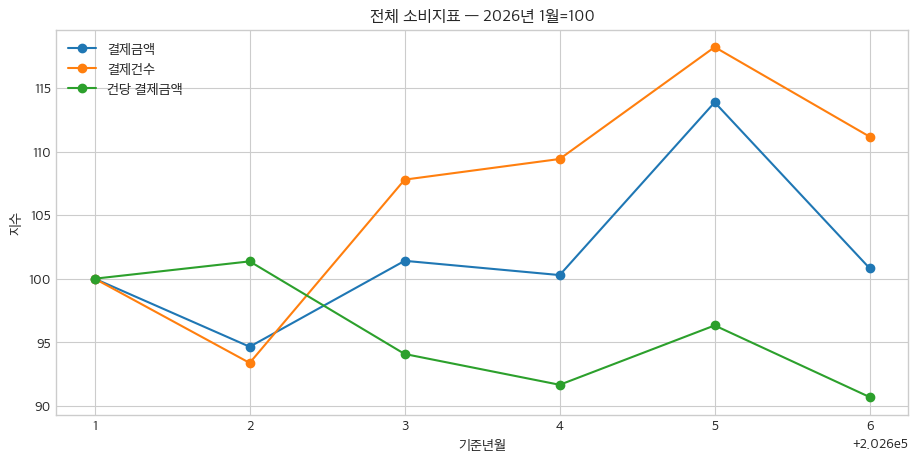

,TP_BUZ_NO,TP_BUZ_NM,amt_share_pct,cnt_share_pct,avg_ticket_6m,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,growth_pattern
0,4004,대형할인점,9.607,5.048,"34,542.187",-3.212,-1.583,-1.655,결제건수 감소·건당금액 감소
1,4010,편의점,14.420,32.242,"8,117.160",3.915,4.887,-0.926,결제건수 증가·건당금액 감소
2,4020,슈퍼마켓,15.814,15.097,"19,010.630",0.710,2.792,-2.025,결제건수 증가·건당금액 감소
3,8001,일반한식,36.856,18.259,"36,632.507",2.309,3.052,-0.721,결제건수 증가·건당금액 감소
4,8002,갈비전문점,0.054,0.013,"75,581.149",4.758,6.308,-1.457,결제건수 증가·건당금액 감소
5,8003,한정식,0.007,0.002,"78,254.231",5.714,7.606,-1.758,결제건수 증가·건당금액 감소
6,8004,일식회집,2.832,1.029,"49,925.957",1.183,2.877,-1.646,결제건수 증가·건당금액 감소
7,8005,중국음식,3.075,1.956,"28,523.192",0.036,1.358,-1.304,결제건수 증가·건당금액 감소
8,8006,서양음식,11.124,18.411,"10,965.327",2.547,4.792,-2.143,결제건수 증가·건당금액 감소
9,8021,스넥,3.318,3.764,"15,998.427",4.563,3.824,0.711,결제건수 증가·건당금액 증가


In [4]:
indexed = overall_monthly.set_index('STRD_YYMM')[['amt', 'cnt', 'avg_ticket']]
indexed = indexed.div(indexed.iloc[0]).mul(100)
indexed.columns = ['결제금액', '결제건수', '건당 결제금액']
ax = indexed.plot(marker='o', title='전체 소비지표 — 2026년 1월=100')
ax.set_xlabel('기준년월'); ax.set_ylabel('지수'); plt.show()

comparison_columns = ['TP_BUZ_NO', 'TP_BUZ_NM', 'amt_share_pct', 'cnt_share_pct', 'avg_ticket_6m',
                      'amt_growth_pct_m', 'cnt_growth_pct_m', 'ticket_growth_pct_m', 'growth_pattern']
display(overview[comparison_columns].sort_values('TP_BUZ_NO'))


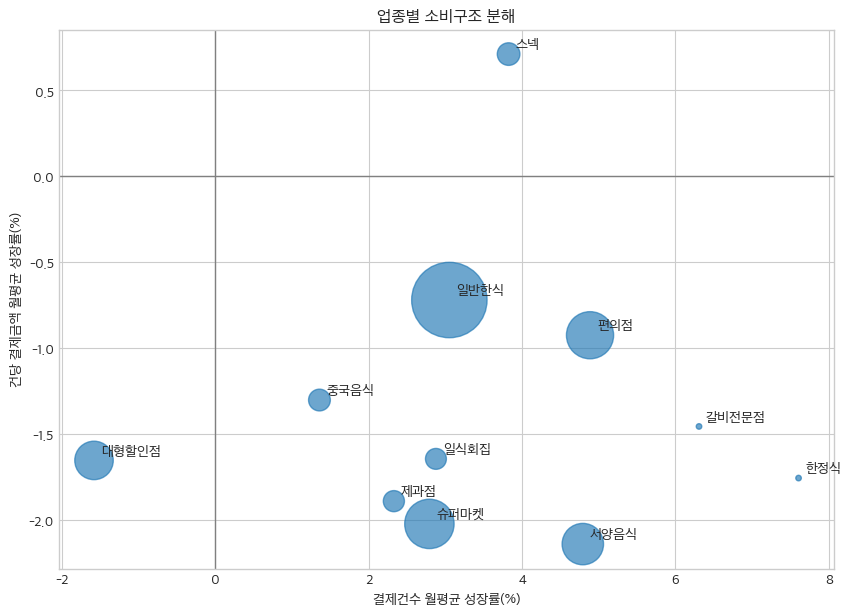

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
sizes = overview['amt_share_pct'].clip(lower=0.2) * 80
ax.scatter(overview.cnt_growth_pct_m, overview.ticket_growth_pct_m, s=sizes, alpha=.65)
ax.axhline(0, color='grey', linewidth=1); ax.axvline(0, color='grey', linewidth=1)
for row in overview.itertuples():
    ax.annotate(row.TP_BUZ_NM, (row.cnt_growth_pct_m, row.ticket_growth_pct_m), xytext=(5, 4), textcoords='offset points')
ax.set(title='업종별 소비구조 분해', xlabel='결제건수 월평균 성장률(%)', ylabel='건당 결제금액 월평균 성장률(%)')
plt.show()


## 5. 11개 업종에 동일한 분석 포맷 적용

모든 업종에서 다음을 같은 순서로 보여줍니다: ① AMT·CNT·건당금액 추세, ② 성별/고객유형, ③ 국내개인 연령, ④ 시군구 성장 상·하위, ⑤ 현재 공급과 개폐업 보조지표.


In [6]:
INDUSTRIES = INDUSTRY_NAMES

def load_industry(code):
    return industry_results[int(code)]

def show_industry(code):
    item = load_industry(code); s = item['summary']; name = item['name']
    display(Markdown(f"## {int(code)} {name}"))
    headline = pd.DataFrame([{
        '업종': name, '금액 성장률/월': s['amt_growth_pct_m'], '건수 성장률/월': s['cnt_growth_pct_m'],
        '건당금액 성장률/월': s['ticket_growth_pct_m'], '패턴': s['growth_pattern'],
        '주요 연령': s['dominant_age'], '현재 공급': s.get('current_store_count'),
        '가동사업자 변화': s.get('active_business_change_pct')
    }])
    display(headline)
    monthly = item['monthly'].set_index('STRD_YYMM')[['amt', 'cnt', 'avg_ticket']]
    normalized = monthly.div(monthly.iloc[0]).mul(100)
    normalized.columns = ['결제금액', '결제건수', '건당 결제금액']
    normalized.plot(marker='o', title=f'{name} 월별 소비구조 — 2026년 1월=100')
    plt.ylabel('지수'); plt.show()
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    item['gender'].plot.bar(x='segment', y='amt_share_pct', ax=axes[0], legend=False, title='성별/고객유형 금액 비중')
    item['age'].plot.bar(x='segment', y='amt_share_pct', ax=axes[1], legend=False, title='국내 개인 연령별 금액 비중')
    axes[0].set_ylabel('%'); axes[1].set_ylabel('%'); plt.tight_layout(); plt.show()
    cols = ['SIDO_NM', 'CCG_NM', 'amt_growth_pct_m', 'cnt_growth_pct_m', 'ticket_growth_pct_m', 'total_amt_6m']
    display(Markdown('**금액 성장 상위 5개 지역**')); display(item['top'][cols])
    display(Markdown('**금액 성장 하위 5개 지역**')); display(item['bottom'][cols])
    return item

print(INDUSTRIES)


{4004: '대형할인점', 4010: '편의점', 4020: '슈퍼마켓', 8001: '일반한식', 8002: '갈비전문점', 8003: '한정식', 8004: '일식회집', 8005: '중국음식', 8006: '서양음식', 8021: '스넥', 8301: '제과점'}


### 4004 대형할인점

결제건수와 건당금액이 함께 약화되는 방어적 업종입니다. 슈퍼마켓·편의점과의 지역 점유율 이동을 우선 확인합니다.


## 4004 대형할인점

,업종,금액 성장률/월,건수 성장률/월,건당금액 성장률/월,패턴,주요 연령,현재 공급,가동사업자 변화
0,대형할인점,-3.212,-1.583,-1.655,결제건수 감소·건당금액 감소,60대 이상,None,None


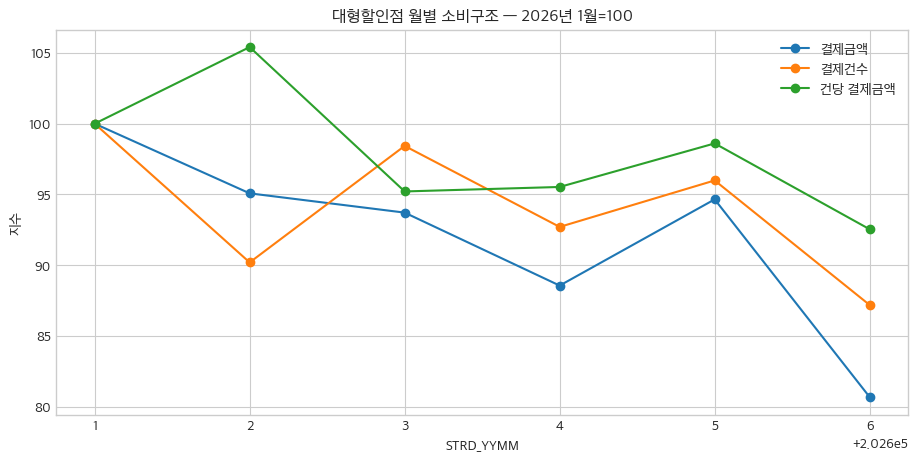

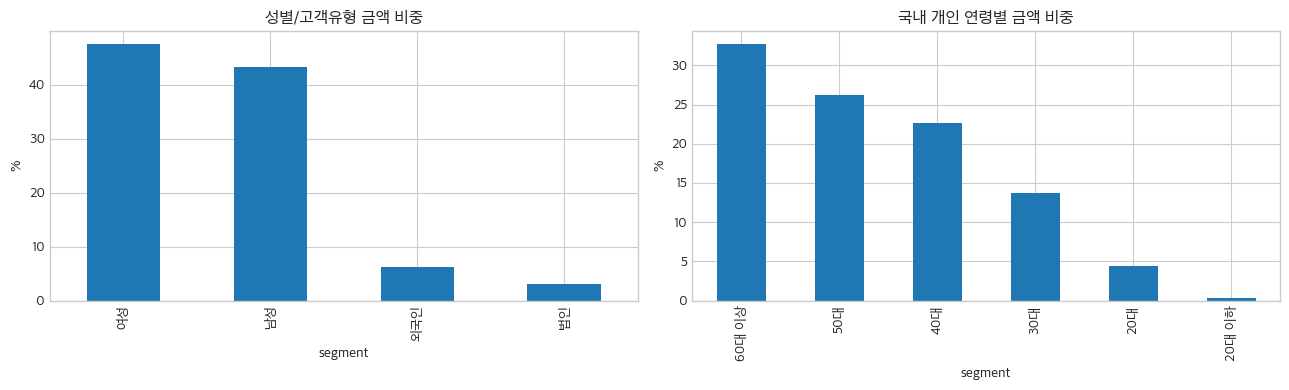

**금액 성장 상위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
6,강원특별자치도,인제군,8.601,2.801,5.642,44810000
188,충청북도,음성군,5.124,6.909,-1.670,168800000
10,강원특별자치도,홍천군,4.039,3.762,0.266,233600000
88,광주광역시,동구,2.106,4.541,-2.329,3273210000
172,전북특별자치도,임실군,1.882,5.071,-3.035,152970000


**금액 성장 하위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
178,충청남도,계룡시,-43.010,-33.904,-13.778,344110000
117,부산광역시,영도구,-33.444,-22.668,-13.935,762320000
91,대구광역시,남구,-24.802,-19.062,-7.092,1140420000
2,강원특별자치도,삼척시,-23.201,-17.443,-6.975,652120000
27,경기도,성남시 중원구,-22.283,-17.652,-5.624,189910000


{'name': '대형할인점',
 'summary': {'amt_growth_pct_m': np.float64(-3.2116645752673847),
  'amt_r2': np.float64(0.6702463601354941),
  'cnt_growth_pct_m': np.float64(-1.5825289173784298),
  'cnt_r2': np.float64(0.319747691448082),
  'ticket_growth_pct_m': np.float64(-1.655331761696396),
  'ticket_r2': np.float64(0.4645561621716543),
  'amt_fitted_change_pct': np.float64(-15.059443028122324),
  'cnt_fitted_change_pct': np.float64(-7.666136830572047),
  'ticket_fitted_change_pct': np.float64(-8.007144880296126),
  'TP_BUZ_NO': 4004,
  'TP_BUZ_NM': '대형할인점',
  'total_amt_6m': np.int64(1654789730000),
  'total_cnt_6m': np.int64(47906339),
  'avg_ticket_6m': np.float64(34542.18720407752),
  'peak_month': 202601,
  'low_month': 202606,
  'dominant_age': '60대 이상',
  'dominant_age_amt_share_pct': np.float64(32.76007484348057),
  'complete_region_n': 197,
  'growth_pattern': '결제건수 감소·건당금액 감소'},
 'monthly':    STRD_YYMM           amt      cnt  avg_ticket
 0     202601  299391180000  8486054  35,280.37

In [7]:
show_industry(4004)


### 4010 편의점

255개 지역 중 70.2%가 안정성장형입니다. 건수는 늘지만 건당금액이 낮아지는 구조를 같이 보아야 합니다.


## 4010 편의점

,업종,금액 성장률/월,건수 성장률/월,건당금액 성장률/월,패턴,주요 연령,현재 공급,가동사업자 변화
0,편의점,3.915,4.887,-0.926,결제건수 증가·건당금액 감소,40대,54446,-0.368


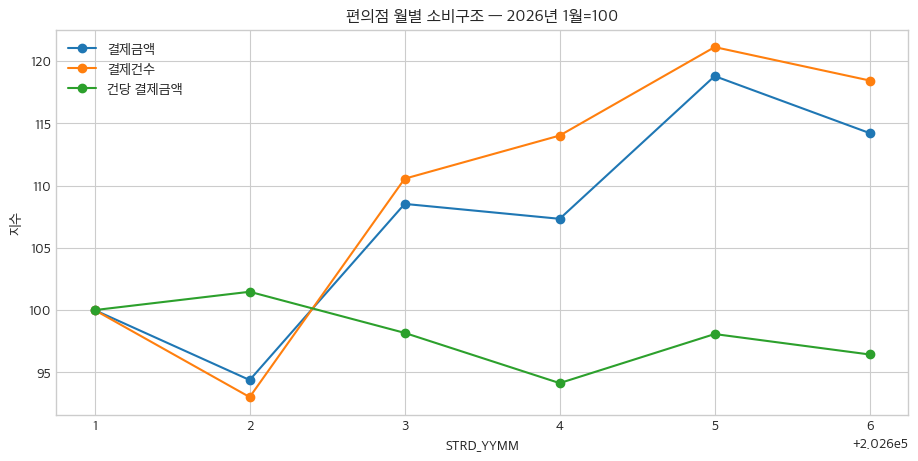

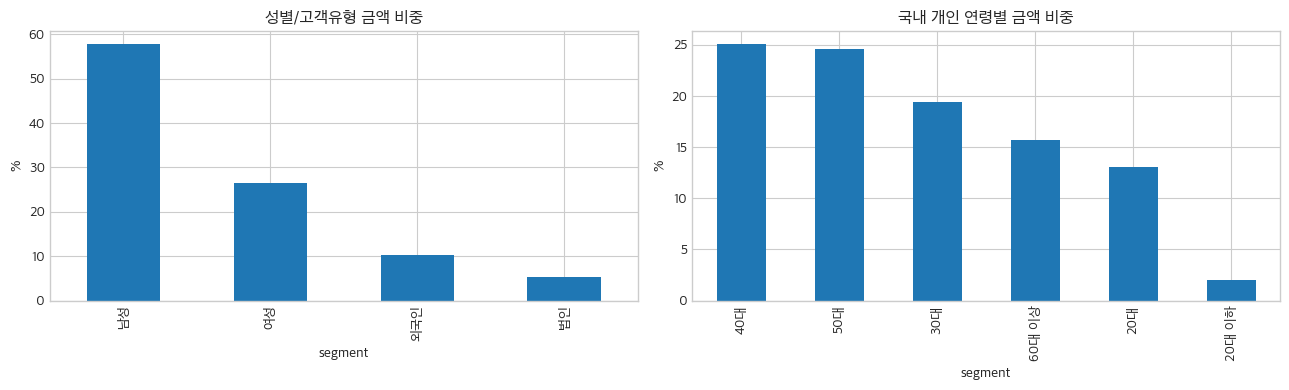

**금액 성장 상위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
98,경상북도,영양군,16.016,15.996,0.017,360620000
102,경상북도,울릉군,14.779,18.855,-3.429,795570000
239,충청남도,태안군,13.116,14.882,-1.537,3789210000
218,전북특별자치도,장수군,12.647,13.779,-0.995,573830000
67,경상남도,고성군,11.503,10.068,1.304,2195980000


**금액 성장 하위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
212,전북특별자치도,무주군,-10.534,-9.769,-0.847,816530000
14,강원특별자치도,평창군,-5.090,-5.101,0.012,2583550000
204,전라남도,진도군,-0.154,1.438,-1.569,1422420000
185,인천광역시,중구,0.328,0.833,-0.501,14953470000
178,인천광역시,남동구,0.773,1.792,-1.001,21451970000


{'name': '편의점',
 'summary': {'amt_growth_pct_m': np.float64(3.914971507568138),
  'amt_r2': np.float64(0.722026643442834),
  'cnt_growth_pct_m': np.float64(4.88659378695225),
  'cnt_r2': np.float64(0.7534657546038528),
  'ticket_growth_pct_m': np.float64(-0.9263550700843763),
  'ticket_r2': np.float64(0.43250262859314326),
  'amt_fitted_change_pct': np.float64(21.16874628597263),
  'cnt_fitted_change_pct': np.float64(26.940413657056993),
  'ticket_fitted_change_pct': np.float64(-4.546753240207534),
  'TP_BUZ_NO': 4010,
  'TP_BUZ_NM': '편의점',
  'total_amt_6m': np.int64(2483898980000),
  'total_cnt_6m': np.int64(306005921),
  'avg_ticket_6m': np.float64(8117.159863713879),
  'peak_month': 202605,
  'low_month': 202602,
  'dominant_age': '40대',
  'dominant_age_amt_share_pct': np.float64(25.12354435049417),
  'complete_region_n': 255,
  'growth_pattern': '결제건수 증가·건당금액 감소',
  'current_store_count': 54446,
  'active_business_jan': 51872.0,
  'active_business_jun': 51681.0,
  'active_business_

In [8]:
show_industry(4010)


### 4020 슈퍼마켓

소비증가 지역에서도 공급증가·공급감소가 나뉘어 지역차가 큰 업종입니다.


## 4020 슈퍼마켓

,업종,금액 성장률/월,건수 성장률/월,건당금액 성장률/월,패턴,주요 연령,현재 공급,가동사업자 변화
0,슈퍼마켓,0.710,2.792,-2.025,결제건수 증가·건당금액 감소,60대 이상,63862,0.230


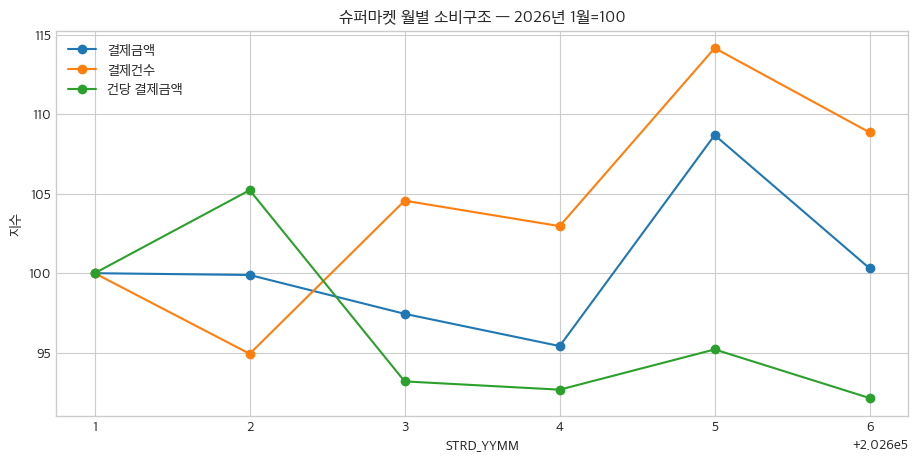

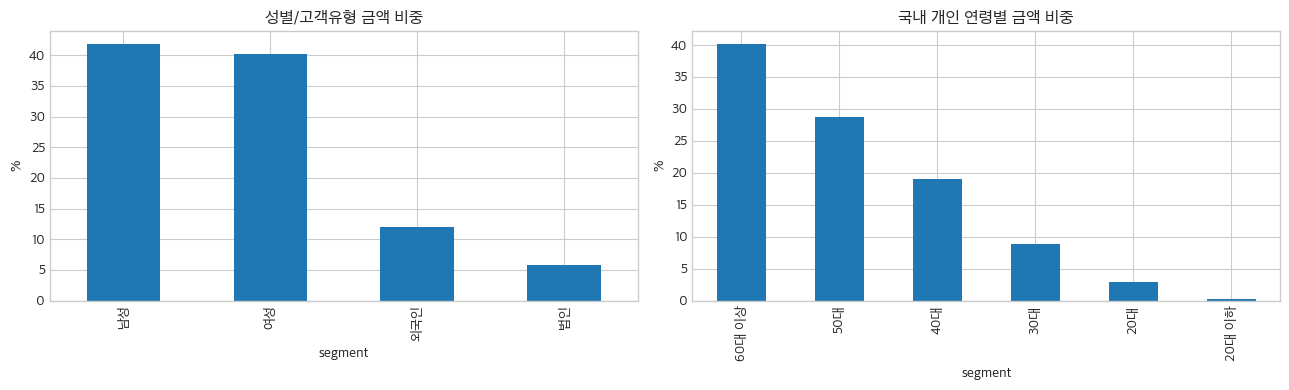

**금액 성장 상위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
115,대구광역시,군위군,24.689,23.516,0.950,867510000
10,강원특별자치도,정선군,23.812,23.186,0.508,1957780000
188,전라남도,곡성군,23.772,24.382,-0.491,286080000
98,경상북도,영양군,22.559,20.083,2.062,986530000
238,충청남도,청양군,19.623,18.060,1.323,1026520000


**금액 성장 하위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
9,강원특별자치도,인제군,-22.479,-12.014,-11.894,564380000
73,경상남도,양산시,-7.281,-3.789,-3.630,18904870000
204,전라남도,진도군,-5.389,-1.705,-3.749,2312100000
241,충청북도,괴산군,-4.541,1.737,-6.171,2541820000
155,서울특별시,동대문구,-4.069,-0.708,-3.385,11879700000


{'name': '슈퍼마켓',
 'summary': {'amt_growth_pct_m': np.float64(0.7100364832030679),
  'amt_r2': np.float64(0.08915998172939177),
  'cnt_growth_pct_m': np.float64(2.7916088330913045),
  'cnt_r2': np.float64(0.6369412443376106),
  'ticket_growth_pct_m': np.float64(-2.0250411230243506),
  'ticket_r2': np.float64(0.5252055471380286),
  'amt_fitted_change_pct': np.float64(3.6009568355895776),
  'cnt_fitted_change_pct': np.float64(14.759412739649811),
  'ticket_fitted_change_pct': np.float64(-9.723346989737545),
  'TP_BUZ_NO': 4020,
  'TP_BUZ_NM': '슈퍼마켓',
  'total_amt_6m': np.int64(2723898860000),
  'total_cnt_6m': np.int64(143282938),
  'avg_ticket_6m': np.float64(19010.629583823862),
  'peak_month': 202605,
  'low_month': 202604,
  'dominant_age': '60대 이상',
  'dominant_age_amt_share_pct': np.float64(40.20796025290956),
  'complete_region_n': 255,
  'growth_pattern': '결제건수 증가·건당금액 감소',
  'current_store_count': 63862,
  'active_business_jan': 26527.0,
  'active_business_jun': 26588.0,
  'activ

In [9]:
show_industry(4020)


### 8001 일반한식

시장규모와 성장률의 음의 관계가 가장 크며, 대규모 지역의 성숙·둔화 여부가 핵심 질문입니다.


## 8001 일반한식

,업종,금액 성장률/월,건수 성장률/월,건당금액 성장률/월,패턴,주요 연령,현재 공급,가동사업자 변화
0,일반한식,2.309,3.052,-0.721,결제건수 증가·건당금액 감소,60대 이상,98173,-0.536


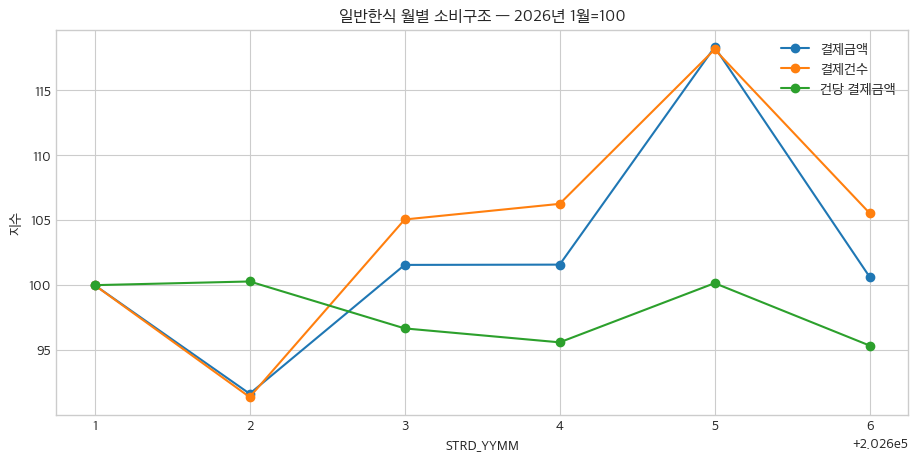

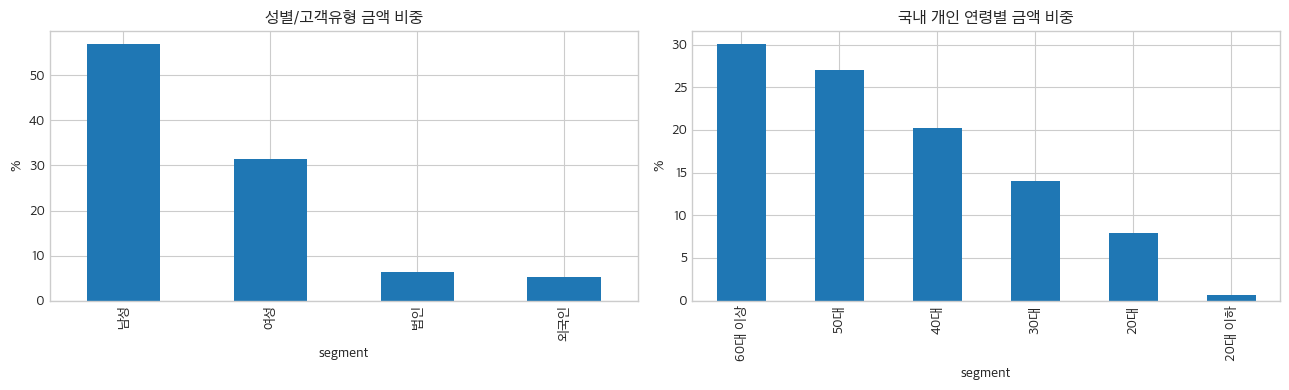

**금액 성장 상위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
102,경상북도,울릉군,32.487,38.960,-4.658,1584100000
188,전라남도,곡성군,15.786,11.336,3.997,2890480000
98,경상북도,영양군,15.006,9.557,4.974,1109180000
218,전북특별자치도,장수군,13.989,9.517,4.083,2561480000
7,강원특별자치도,영월군,13.961,12.017,1.736,4021130000


**금액 성장 하위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
212,전북특별자치도,무주군,-6.690,-5.098,-1.678,2728220000
97,경상북도,영덕군,-6.100,-0.651,-5.485,7445380000
181,인천광역시,부평구,-1.962,-0.896,-1.076,42716050000
177,인천광역시,계양구,-1.672,-1.183,-0.494,26060210000
105,경상북도,청도군,-1.627,0.350,-1.970,7502170000


{'name': '일반한식',
 'summary': {'amt_growth_pct_m': np.float64(2.3087644605925424),
  'amt_r2': np.float64(0.2668299231821575),
  'cnt_growth_pct_m': np.float64(3.0520803713878264),
  'cnt_r2': np.float64(0.4474606474141194),
  'ticket_growth_pct_m': np.float64(-0.7213012179050469),
  'ticket_r2': np.float64(0.30879665849107185),
  'amt_fitted_change_pct': np.float64(12.089310980560791),
  'cnt_fitted_change_pct': np.float64(16.220788551483125),
  'ticket_fitted_change_pct': np.float64(-3.5548524686633978),
  'TP_BUZ_NO': 8001,
  'TP_BUZ_NM': '일반한식',
  'total_amt_6m': np.int64(6348450610000),
  'total_cnt_6m': np.int64(173301016),
  'avg_ticket_6m': np.float64(36632.50658611257),
  'peak_month': 202605,
  'low_month': 202602,
  'dominant_age': '60대 이상',
  'dominant_age_amt_share_pct': np.float64(30.103423908558224),
  'complete_region_n': 255,
  'growth_pattern': '결제건수 증가·건당금액 감소',
  'current_store_count': 98173,
  'active_business_jan': 406261.0,
  'active_business_jun': 404083.0,
  'ac

In [10]:
show_industry(8001)


### 8002 갈비전문점

소비층 이동의 극단값이 있지만 완전관측 지역이 적어 일반화를 유보합니다.


## 8002 갈비전문점

,업종,금액 성장률/월,건수 성장률/월,건당금액 성장률/월,패턴,주요 연령,현재 공급,가동사업자 변화
0,갈비전문점,4.758,6.308,-1.457,결제건수 증가·건당금액 감소,60대 이상,61512,None


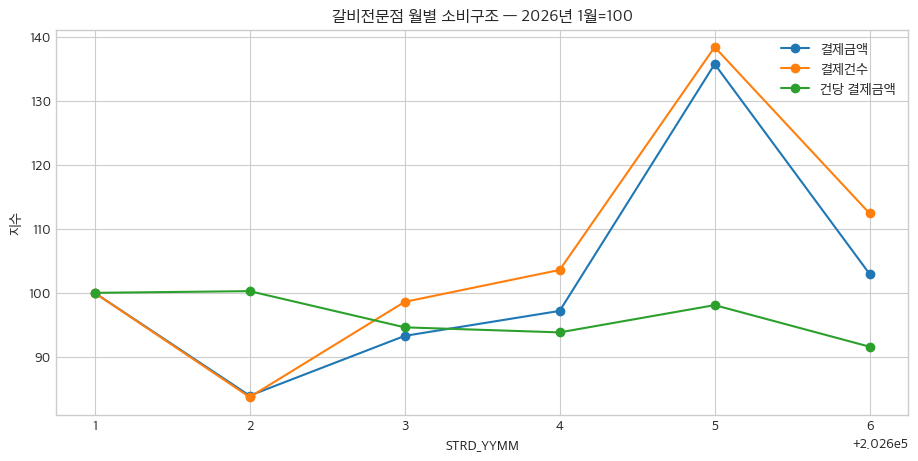

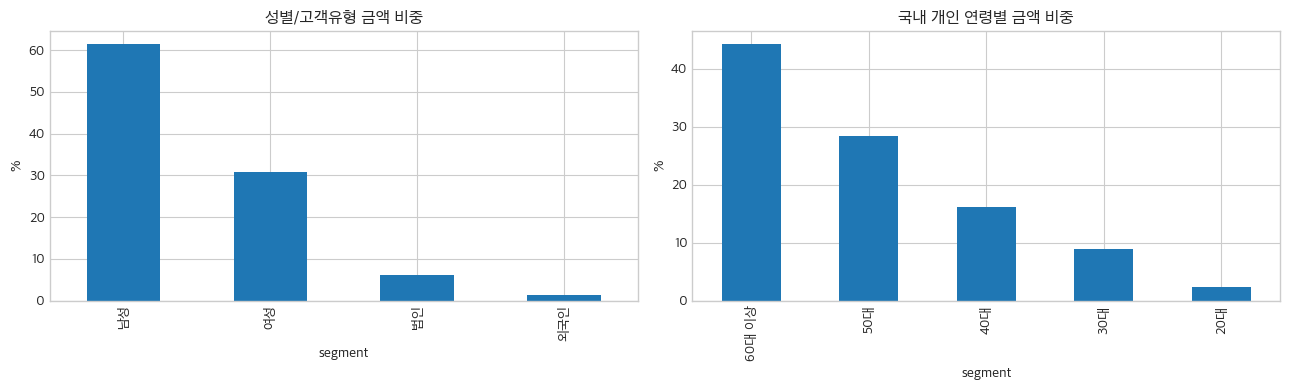

**금액 성장 상위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
69,인천광역시,강화군,47.827,44.632,2.210,25000000
40,대전광역시,유성구,43.824,44.865,-0.719,125980000
62,서울특별시,양천구,38.945,41.448,-1.770,44720000
20,경상남도,남해군,31.683,35.731,-2.983,22160000
37,대구광역시,서구,28.849,43.652,-10.305,6600000


**금액 성장 하위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
70,인천광역시,남동구,-17.242,-12.186,-5.757,15620000
74,전라남도,여수시,-12.009,-7.384,-4.994,73370000
68,울산광역시,중구,-11.485,-7.361,-4.452,36100000
71,인천광역시,부평구,-10.748,-5.112,-5.939,7340000
7,경기도,광명시,-9.126,-8.016,-1.207,32670000


{'name': '갈비전문점',
 'summary': {'amt_growth_pct_m': np.float64(4.758422354734519),
  'amt_r2': np.float64(0.29133837291645315),
  'cnt_growth_pct_m': np.float64(6.3078535089300285),
  'cnt_r2': np.float64(0.4723200507493077),
  'ticket_growth_pct_m': np.float64(-1.4574945340848033),
  'ticket_r2': np.float64(0.5472569721978356),
  'amt_fitted_change_pct': np.float64(26.16670090753533),
  'cnt_fitted_change_pct': np.float64(35.777168109867674),
  'ticket_fitted_change_pct': np.float64(-7.078117282985263),
  'TP_BUZ_NO': 8002,
  'TP_BUZ_NM': '갈비전문점',
  'total_amt_6m': np.int64(9269650000),
  'total_cnt_6m': np.int64(122645),
  'avg_ticket_6m': np.float64(75581.1488442252),
  'peak_month': 202605,
  'low_month': 202602,
  'dominant_age': '60대 이상',
  'dominant_age_amt_share_pct': np.float64(44.3024494142705),
  'complete_region_n': 82,
  'growth_pattern': '결제건수 증가·건당금액 감소',
  'current_store_count': 61512},
 'monthly':    STRD_YYMM         amt    cnt  avg_ticket
 0     202601  1512040000  19

In [11]:
show_industry(8002)


### 8003 한정식

표본 지역이 매우 적어 사례형 업종으로만 해석합니다.


## 8003 한정식

,업종,금액 성장률/월,건수 성장률/월,건당금액 성장률/월,패턴,주요 연령,현재 공급,가동사업자 변화
0,한정식,5.714,7.606,-1.758,결제건수 증가·건당금액 감소,60대 이상,180762,None


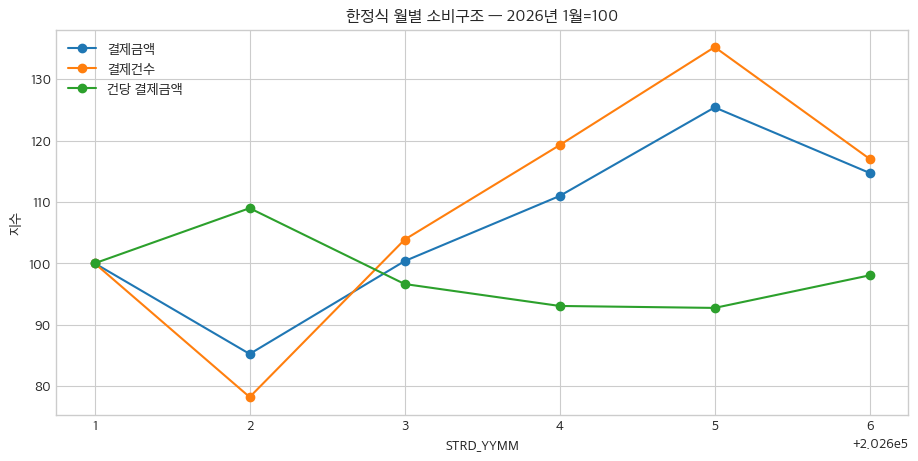

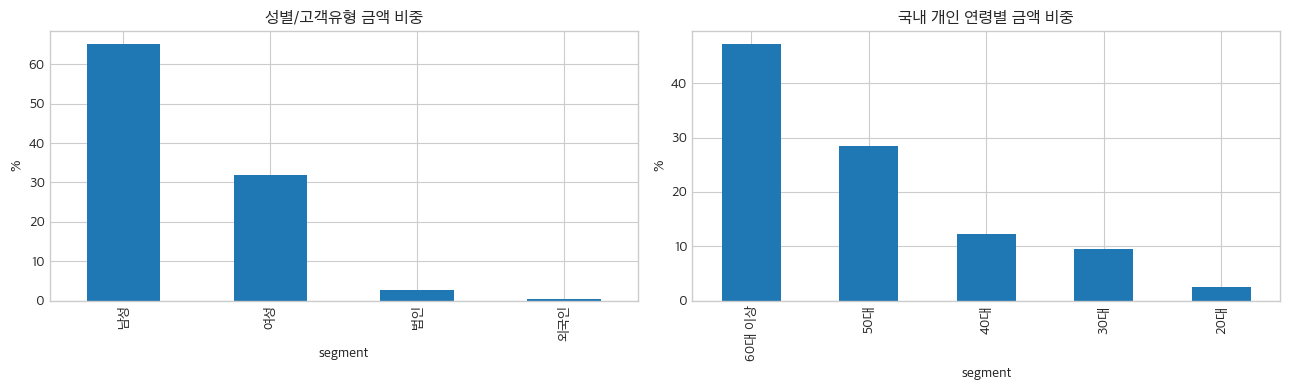

**금액 성장 상위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
17,제주특별자치도,제주시,38.302,41.663,-2.373,4580000
1,경기도,시흥시,26.821,18.378,7.132,52000000
6,경상남도,산청군,24.494,16.433,6.924,22410000
3,경기도,용인시 처인구,19.743,17.648,1.781,24510000
14,서울특별시,송파구,16.152,10.623,4.998,18890000


**금액 성장 하위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
5,경상남도,사천시,-10.533,-9.937,-0.662,17590000
0,강원특별자치도,춘천시,-7.741,-4.418,-3.477,18030000
13,서울특별시,마포구,-5.068,4.386,-9.057,188760000
10,부산광역시,기장군,-1.425,0.300,-1.720,206940000
16,서울특별시,용산구,-1.194,-0.176,-1.019,52440000


{'name': '한정식',
 'summary': {'amt_growth_pct_m': np.float64(5.7144213791577),
  'amt_r2': np.float64(0.5988754148308245),
  'cnt_growth_pct_m': np.float64(7.606282639738309),
  'cnt_r2': np.float64(0.5279508256044048),
  'ticket_growth_pct_m': np.float64(-1.7581327169479628),
  'ticket_r2': np.float64(0.31255734142607605),
  'amt_fitted_change_pct': np.float64(32.0295628294178),
  'cnt_fitted_change_pct': np.float64(44.27402323154309),
  'ticket_fitted_change_pct': np.float64(-8.486947357442958),
  'TP_BUZ_NO': 8003,
  'TP_BUZ_NM': '한정식',
  'total_amt_6m': np.int64(1230000000),
  'total_cnt_6m': np.int64(15718),
  'avg_ticket_6m': np.float64(78254.23081817025),
  'peak_month': 202605,
  'low_month': 202602,
  'dominant_age': '60대 이상',
  'dominant_age_amt_share_pct': np.float64(47.31099965670554),
  'complete_region_n': 18,
  'growth_pattern': '결제건수 증가·건당금액 감소',
  'current_store_count': 180762},
 'monthly':    STRD_YYMM        amt   cnt  avg_ticket
 0     202601  193190000  2405  80,328

In [12]:
show_industry(8003)


### 8004 일식회집

고변동·피크의존 비율이 높아 특정월 사건과 기저효과 점검이 필요합니다.


## 8004 일식회집

,업종,금액 성장률/월,건수 성장률/월,건당금액 성장률/월,패턴,주요 연령,현재 공급,가동사업자 변화
0,일식회집,1.183,2.877,-1.646,결제건수 증가·건당금액 감소,50대,44227,0.347


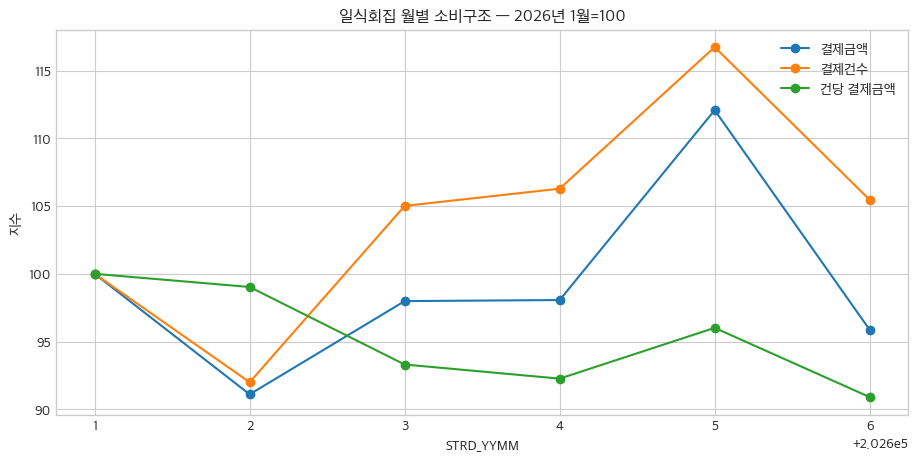

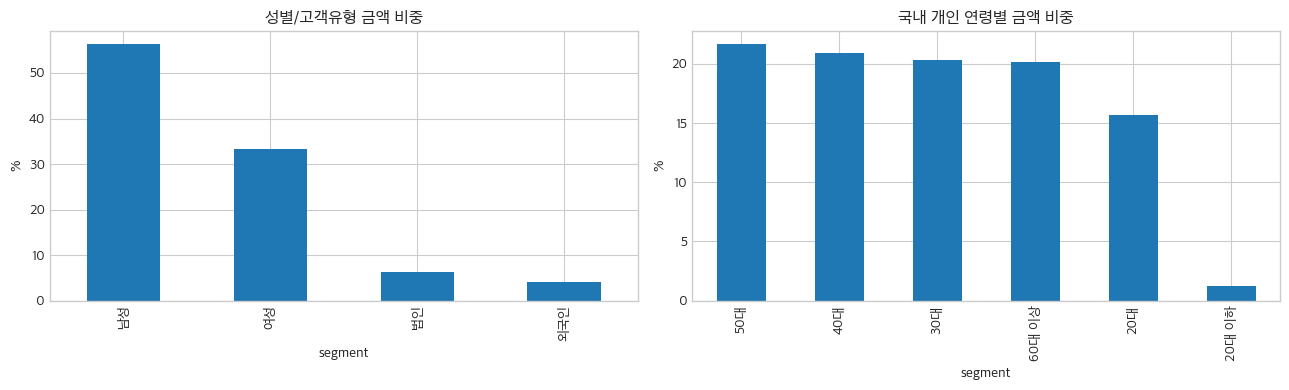

**금액 성장 상위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
97,경상북도,영양군,44.188,45.420,-0.847,23150000
103,경상북도,청도군,37.228,70.211,-19.377,37290000
102,경상북도,의성군,34.274,28.310,4.648,31590000
67,경상남도,고성군,25.897,22.637,2.658,495280000
186,전라남도,구례군,24.827,25.495,-0.533,25570000


**금액 성장 하위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
231,충청남도,홍성군,-25.534,-14.473,-12.932,2530140000
213,전북특별자치도,진안군,-22.048,-10.991,-12.422,20890000
74,경상남도,의령군,-16.062,-17.689,1.976,43830000
86,경상남도,합천군,-13.913,-7.327,-7.106,86980000
14,강원특별자치도,평창군,-12.542,-11.001,-1.732,119650000


{'name': '일식회집',
 'summary': {'amt_growth_pct_m': np.float64(1.1829815684000147),
  'amt_r2': np.float64(0.1023635913169314),
  'cnt_growth_pct_m': np.float64(2.876764131379722),
  'cnt_r2': np.float64(0.4586016875230109),
  'ticket_growth_pct_m': np.float64(-1.6464189725258296),
  'ticket_r2': np.float64(0.6373981261813417),
  'amt_fitted_change_pct': np.float64(6.056517714626317),
  'cnt_fitted_change_pct': np.float64(15.235549699575824),
  'ticket_fitted_change_pct': np.float64(-7.965451641337697),
  'TP_BUZ_NO': 8004,
  'TP_BUZ_NM': '일식회집',
  'total_amt_6m': np.int64(487750290000),
  'total_cnt_6m': np.int64(9769473),
  'avg_ticket_6m': np.float64(49925.95711150438),
  'peak_month': 202605,
  'low_month': 202602,
  'dominant_age': '50대',
  'dominant_age_amt_share_pct': np.float64(21.703408022465005),
  'complete_region_n': 246,
  'growth_pattern': '결제건수 증가·건당금액 감소',
  'current_store_count': 44227,
  'active_business_jan': 23352.0,
  'active_business_jun': 23433.0,
  'active_busines

In [13]:
show_industry(8004)


### 8005 중국음식

객단가 하락이 소비층이동·공급확대·수요위축으로 나뉘며, 고특화·고폐업압력 지역이 14곳입니다.


## 8005 중국음식

,업종,금액 성장률/월,건수 성장률/월,건당금액 성장률/월,패턴,주요 연령,현재 공급,가동사업자 변화
0,중국음식,0.036,1.358,-1.304,결제건수 증가·건당금액 감소,50대,31984,0.235


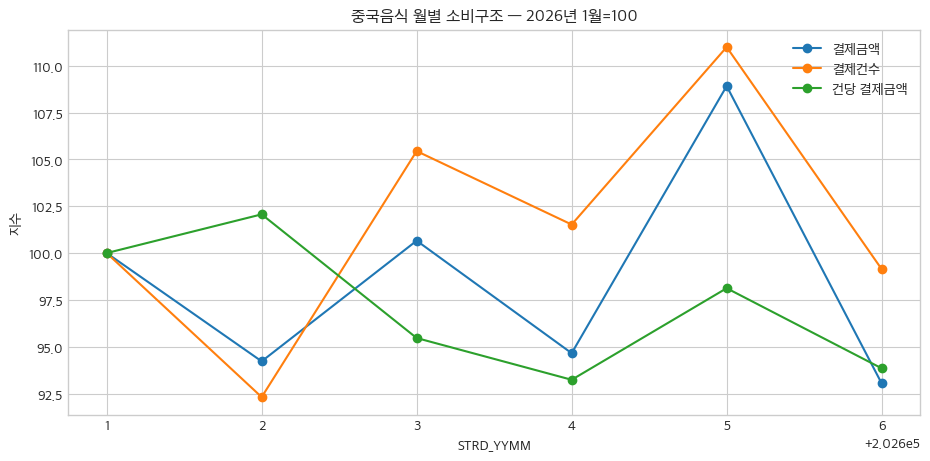

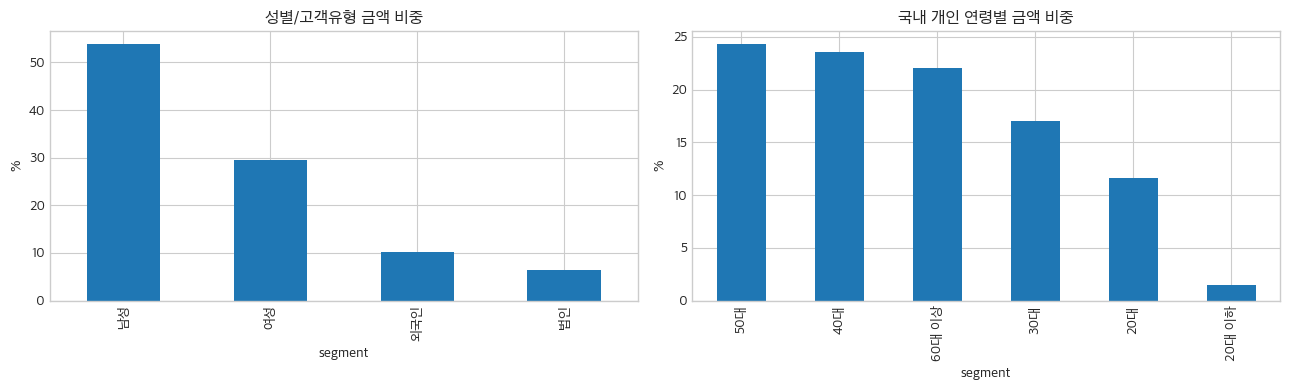

**금액 성장 상위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
102,경상북도,울릉군,23.783,20.277,2.915,112300000
218,전북특별자치도,장수군,23.614,22.937,0.551,257330000
98,경상북도,영양군,17.139,20.053,-2.427,136160000
188,전라남도,곡성군,14.203,13.616,0.516,377290000
115,대구광역시,군위군,13.264,13.911,-0.568,205830000


**금액 성장 하위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
212,전북특별자치도,무주군,-6.162,-4.341,-1.903,311540000
70,경상남도,밀양시,-3.891,-2.796,-1.126,695390000
76,경상남도,창녕군,-3.811,-3.000,-0.836,516310000
73,경상남도,양산시,-3.735,-3.086,-0.670,2205410000
145,서울특별시,강남구,-3.377,-1.989,-1.416,13618130000


{'name': '중국음식',
 'summary': {'amt_growth_pct_m': np.float64(0.03620910090350171),
  'amt_r2': np.float64(0.00013027377191199285),
  'cnt_growth_pct_m': np.float64(1.3576531325833556),
  'cnt_r2': np.float64(0.16553607585510777),
  'ticket_growth_pct_m': np.float64(-1.3037437143016826),
  'ticket_r2': np.float64(0.4591566166096027),
  'amt_fitted_change_pct': np.float64(0.18117666189864365),
  'cnt_fitted_change_pct': np.float64(6.975107355382093),
  'ticket_fitted_change_pct': np.float64(-6.350945431550582),
  'TP_BUZ_NO': 8005,
  'TP_BUZ_NM': '중국음식',
  'total_amt_6m': np.int64(529612890000),
  'total_cnt_6m': np.int64(18567799),
  'avg_ticket_6m': np.float64(28523.191682546756),
  'peak_month': 202605,
  'low_month': 202606,
  'dominant_age': '50대',
  'dominant_age_amt_share_pct': np.float64(24.352361147852704),
  'complete_region_n': 255,
  'growth_pattern': '결제건수 증가·건당금액 감소',
  'current_store_count': 31984,
  'active_business_jan': 28554.0,
  'active_business_jun': 28621.0,
  'acti

In [14]:
show_industry(8005)


### 8006 서양음식

건당금액 수준이 높은 지역일수록 건당금액 성장률도 높은 방어력 후보가 보입니다.


## 8006 서양음식

,업종,금액 성장률/월,건수 성장률/월,건당금액 성장률/월,패턴,주요 연령,현재 공급,가동사업자 변화
0,서양음식,2.547,4.792,-2.143,결제건수 증가·건당금액 감소,40대,23100,None


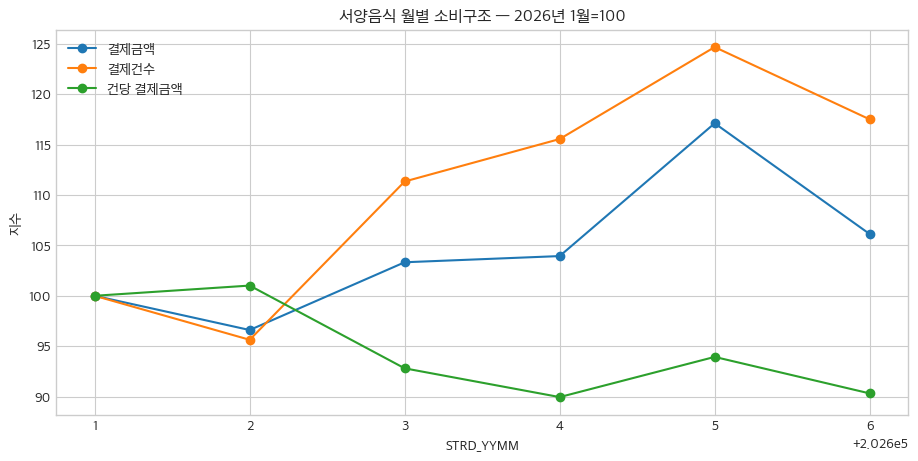

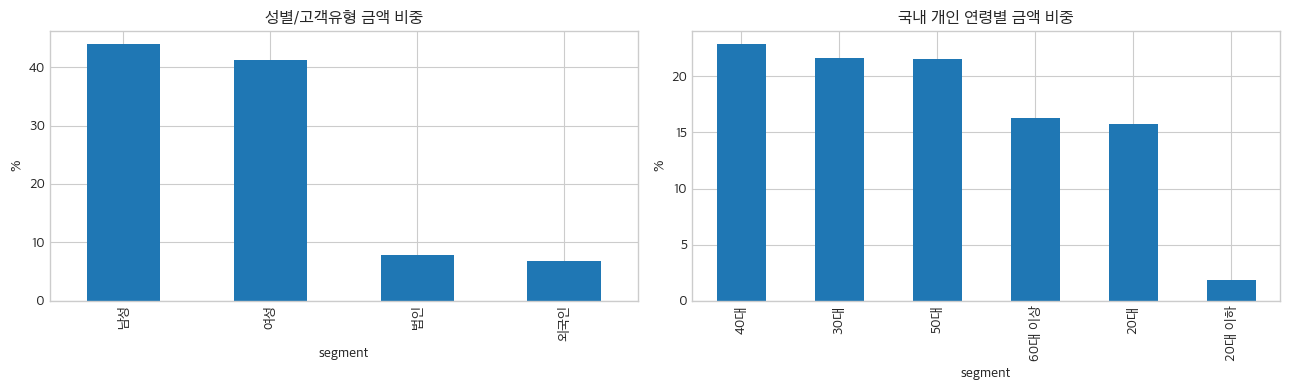

**금액 성장 상위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
102,경상북도,울릉군,42.295,39.896,1.714,312760000
188,전라남도,곡성군,19.310,21.213,-1.571,599310000
98,경상북도,영양군,17.428,14.840,2.253,215700000
218,전북특별자치도,장수군,15.362,17.266,-1.623,430910000
184,인천광역시,옹진군,14.045,15.239,-1.036,653680000


**금액 성장 하위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
212,전북특별자치도,무주군,-10.952,-8.633,-2.539,447010000
14,강원특별자치도,평창군,-9.788,-6.347,-3.674,1364670000
15,강원특별자치도,홍천군,-6.479,-5.253,-1.293,1632690000
10,강원특별자치도,정선군,-4.692,-2.371,-2.378,986330000
185,인천광역시,중구,-3.496,-1.160,-2.363,14451720000


{'name': '서양음식',
 'summary': {'amt_growth_pct_m': np.float64(2.5472521753738766),
  'amt_r2': np.float64(0.516014869955369),
  'cnt_growth_pct_m': np.float64(4.79249543763335),
  'cnt_r2': np.float64(0.7493198297390968),
  'ticket_growth_pct_m': np.float64(-2.1425611184110442),
  'ticket_r2': np.float64(0.6579921937344929),
  'amt_fitted_change_pct': np.float64(13.40184964607214),
  'cnt_fitted_change_pct': np.float64(26.372015465180237),
  'ticket_fitted_change_pct': np.float64(-10.263479435193004),
  'TP_BUZ_NO': 8006,
  'TP_BUZ_NM': '서양음식',
  'total_amt_6m': np.int64(1916074350000),
  'total_cnt_6m': np.int64(174739374),
  'avg_ticket_6m': np.float64(10965.326853007955),
  'peak_month': 202605,
  'low_month': 202602,
  'dominant_age': '40대',
  'dominant_age_amt_share_pct': np.float64(22.925740534009236),
  'complete_region_n': 255,
  'growth_pattern': '결제건수 증가·건당금액 감소',
  'current_store_count': 23100},
 'monthly':    STRD_YYMM           amt       cnt  avg_ticket
 0     202601  30554

In [15]:
show_industry(8006)


### 8021 스넥

편의점 다음으로 안정성장 비율이 높고 시장규모와 성장률의 관계는 거의 없습니다.


## 8021 스넥

,업종,금액 성장률/월,건수 성장률/월,건당금액 성장률/월,패턴,주요 연령,현재 공급,가동사업자 변화
0,스넥,4.563,3.824,0.711,결제건수 증가·건당금액 증가,50대,44410,-2.257


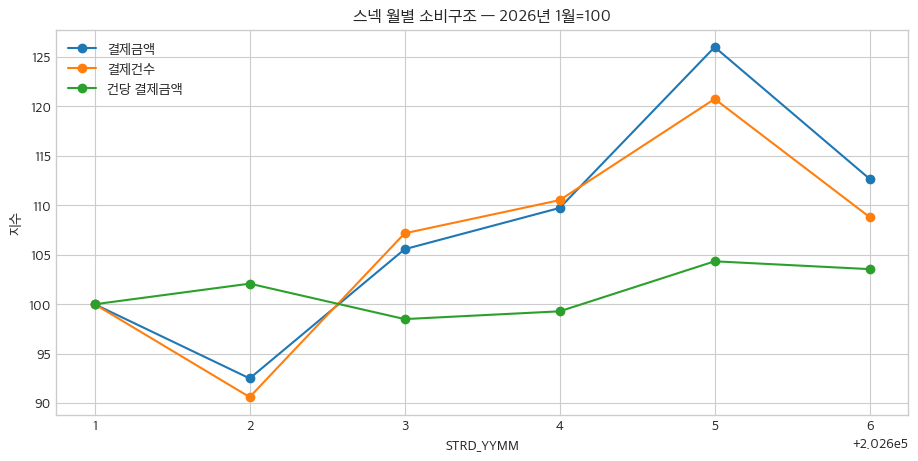

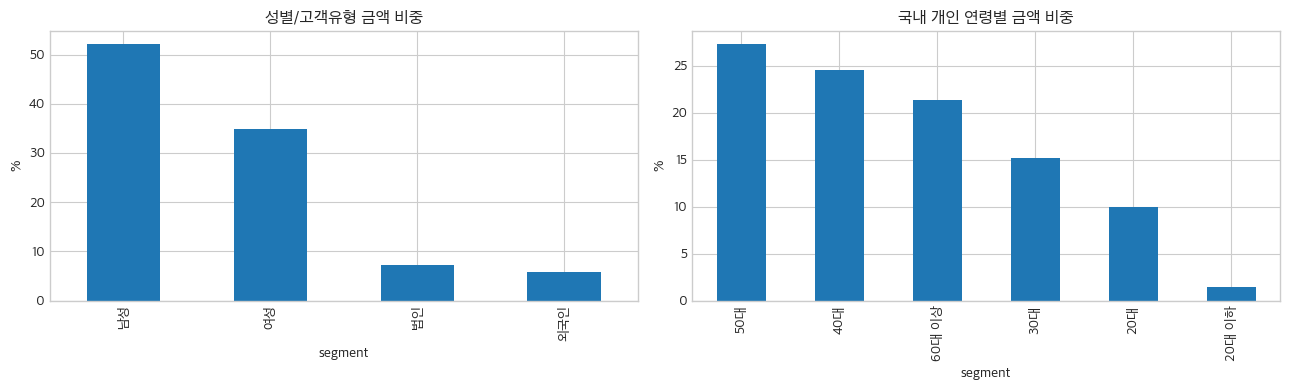

**금액 성장 상위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
102,경상북도,울릉군,29.498,37.438,-5.777,116930000
218,전북특별자치도,장수군,23.556,24.034,-0.385,224740000
115,대구광역시,군위군,21.102,18.684,2.037,94310000
69,경상남도,남해군,18.936,19.081,-0.122,383800000
98,경상북도,영양군,18.125,18.314,-0.159,151060000


**금액 성장 하위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
212,전북특별자치도,무주군,-25.886,-31.351,7.962,377220000
245,충청북도,옥천군,-17.743,-27.720,13.803,254130000
74,경상남도,의령군,-5.800,-4.234,-1.635,111110000
14,강원특별자치도,평창군,-4.115,-5.439,1.400,550930000
16,강원특별자치도,화천군,-2.004,-7.693,6.163,435150000


{'name': '스넥',
 'summary': {'amt_growth_pct_m': np.float64(4.562555220611891),
  'amt_r2': np.float64(0.6233347913340164),
  'cnt_growth_pct_m': np.float64(3.8244572159832417),
  'cnt_r2': np.float64(0.519321655755203),
  'ticket_growth_pct_m': np.float64(0.7109095721955507),
  'ticket_r2': np.float64(0.3170741653358644),
  'amt_fitted_change_pct': np.float64(24.991631909501084),
  'cnt_fitted_change_pct': np.float64(20.641949550167105),
  'ticket_fitted_change_pct': np.float64(3.6054476701939646),
  'TP_BUZ_NO': 8021,
  'TP_BUZ_NM': '스넥',
  'total_amt_6m': np.int64(571506890000),
  'total_cnt_6m': np.int64(35722693),
  'avg_ticket_6m': np.float64(15998.426826331375),
  'peak_month': 202605,
  'low_month': 202602,
  'dominant_age': '50대',
  'dominant_age_amt_share_pct': np.float64(27.351067527995436),
  'complete_region_n': 255,
  'growth_pattern': '결제건수 증가·건당금액 증가',
  'current_store_count': 44410,
  'active_business_jan': 48968.0,
  'active_business_jun': 47863.0,
  'active_business_c

In [16]:
show_industry(8021)


### 8301 제과점

고변동 비율과 법인결제 비중이 가장 높고, 고특화·고폐업압력 지역이 27곳입니다.


## 8301 제과점

,업종,금액 성장률/월,건수 성장률/월,건당금액 성장률/월,패턴,주요 연령,현재 공급,가동사업자 변화
0,제과점,0.392,2.328,-1.893,결제건수 증가·건당금액 감소,60대 이상,31168,2.688


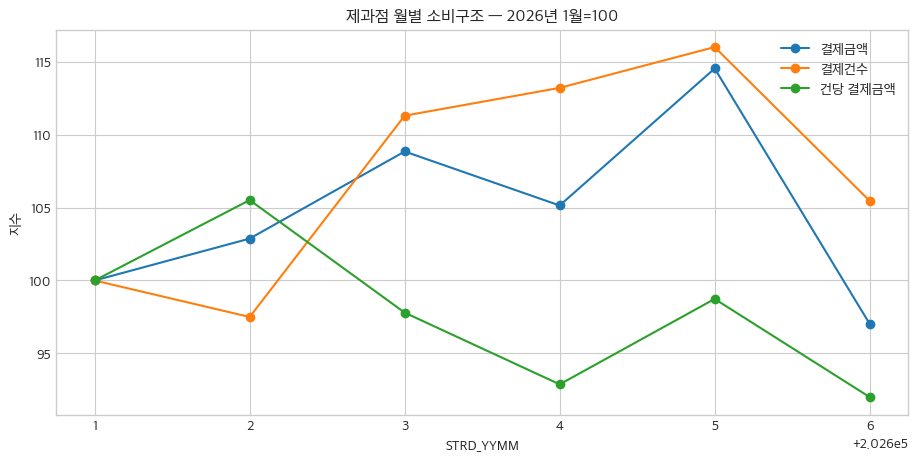

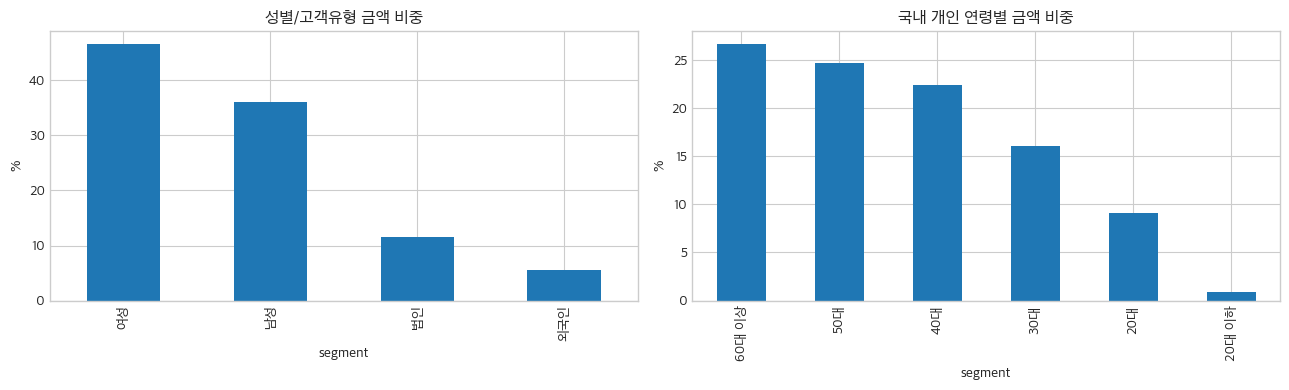

**금액 성장 상위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
217,전북특별자치도,장수군,27.041,26.018,0.812,80090000
187,전라남도,곡성군,22.811,21.700,0.913,116270000
98,경상북도,영양군,17.405,16.059,1.160,158470000
213,전북특별자치도,순창군,14.711,17.226,-2.145,227730000
83,경상남도,하동군,12.880,16.080,-2.757,243430000


**금액 성장 하위 5개 지역**

,SIDO_NM,CCG_NM,amt_growth_pct_m,cnt_growth_pct_m,ticket_growth_pct_m,total_amt_6m
176,인천광역시,계양구,-12.440,-4.273,-8.532,2477150000
15,강원특별자치도,홍천군,-5.186,-1.596,-3.648,411680000
0,강원특별자치도,강릉시,-4.685,-0.668,-4.044,2113000000
184,인천광역시,중구,-4.171,-3.566,-0.627,3469390000
49,경기도,연천군,-4.133,-2.330,-1.846,172950000


{'name': '제과점',
 'summary': {'amt_growth_pct_m': np.float64(0.391724128460208),
  'amt_r2': np.float64(0.014981595498078759),
  'cnt_growth_pct_m': np.float64(2.3283423562017647),
  'cnt_r2': np.float64(0.3740797482357956),
  'ticket_growth_pct_m': np.float64(-1.8925531120206218),
  'ticket_r2': np.float64(0.4994854329146473),
  'amt_fitted_change_pct': np.float64(1.9740256486090981),
  'cnt_fitted_change_pct': np.float64(12.196599582574349),
  'ticket_fitted_change_pct': np.float64(-9.111304595680654),
  'TP_BUZ_NO': 8301,
  'TP_BUZ_NM': '제과점',
  'total_amt_6m': np.int64(498417820000),
  'total_cnt_6m': np.int64(39671152),
  'avg_ticket_6m': np.float64(12563.734473856468),
  'peak_month': 202605,
  'low_month': 202606,
  'dominant_age': '60대 이상',
  'dominant_age_amt_share_pct': np.float64(26.71279997547226),
  'complete_region_n': 254,
  'growth_pattern': '결제건수 증가·건당금액 감소',
  'current_store_count': 31168,
  'active_business_jan': 23994.0,
  'active_business_jun': 24639.0,
  'active_bu

In [17]:
show_industry(8301)


## 5-A. 주제를 먼저 검증하는 핵심 분석

초기 아이디어는 `공실위험 예측과 리밸런싱 업종 추천`이었지만, BC원본에는 개별점포·공실·임대료·영업일·고객수가 없습니다. 따라서 자료가 지지하는 최종 주제는 다음입니다.

> **“같은 매출 변화, 다른 점검” — BC카드 소비구조 분해와 외부 시장맥락을 결합한 지역×업종 경영 의사결정 지원**

이 주제가 성립하려면 ① AMT만 같고 내부 경로가 다른 사례, ② 지역 전체와 개별 업종의 방향 불일치가 충분히 반복되어야 합니다.


In [18]:
def topic_direction(value, band=.25):
    return '상승' if value > band else '감소' if value < -band else '정체'

# 시군구×업종 6개월 완전관측 패널
topic_month = add_ticket(data.groupby(
    ['SIDO_NM','CCG_NM','TP_BUZ_NO','TP_BUZ_NM','STRD_YYMM'], as_index=False
)[['amt','cnt']].sum())
topic_rows = []
for key, g in topic_month.groupby(['SIDO_NM','CCG_NM','TP_BUZ_NO','TP_BUZ_NM']):
    g = g.sort_values('STRD_YYMM')
    if len(g) != 6:
        continue
    r = decompose(g)
    peak = g.amt.idxmax()
    no_peak = log_trend(g.drop(peak).amt)
    r.update(dict(zip(['SIDO_NM','CCG_NM','TP_BUZ_NO','TP_BUZ_NM'], key)))
    r.update(total_amt_6m=g.amt.sum(), total_cnt_6m=g.cnt.sum(),
             peak_month=int(g.loc[peak,'STRD_YYMM']),
             amt_without_peak_growth_pct_m=no_peak['growth_pct_m'])
    topic_rows.append(r)
topic_core = pd.DataFrame(topic_rows)

# 시군구 전체 금액 추세
region_month = data.groupby(['SIDO_NM','CCG_NM','STRD_YYMM'],as_index=False)[['amt','cnt']].sum()
region_rows=[]
for key,g in region_month.groupby(['SIDO_NM','CCG_NM']):
    r=log_trend(g.sort_values('STRD_YYMM').amt)
    region_rows.append({'SIDO_NM':key[0],'CCG_NM':key[1],'region_amt_growth_pct_m':r['growth_pct_m']})
topic_core=topic_core.merge(pd.DataFrame(region_rows),on=['SIDO_NM','CCG_NM'],validate='many_to_one')
topic_core['amt_direction']=topic_core.amt_growth_pct_m.map(topic_direction)
topic_core['cnt_direction']=topic_core.cnt_growth_pct_m.map(topic_direction)
topic_core['ticket_direction']=topic_core.ticket_growth_pct_m.map(topic_direction)
topic_core['region_direction']=topic_core.region_amt_growth_pct_m.map(topic_direction)
topic_core['region_industry_relation']=np.select([
    topic_core.region_direction.eq(topic_core.amt_direction),
    ((topic_core.region_direction.eq('상승')) & topic_core.amt_direction.eq('감소')) |
    ((topic_core.region_direction.eq('감소')) & topic_core.amt_direction.eq('상승'))],
    ['같은방향','정반대'], default='정체포함차이')
topic_core['decomposition_type']=topic_core.cnt_direction+' CNT·'+topic_core.ticket_direction+' 건당금액'
topic_core['peak_dependent']=(topic_core.amt_direction.eq('상승') &
                              ~topic_core.amt_without_peak_growth_pct_m.map(topic_direction).eq('상승'))

topic_facts = pd.DataFrame([
    ['6개월 완전관측 지역×업종',len(topic_core)],
    ['지역전체–개별업종 방향 불일치',(topic_core.region_industry_relation!='같은방향').sum()],
    ['위 불일치 중 정반대',(topic_core.region_industry_relation=='정반대').sum()],
    ['지역전체 상승·개별업종 감소',((topic_core.region_direction=='상승')&(topic_core.amt_direction=='감소')).sum()],
    ['엄격 AMT상승·CNT감소',((topic_core.amt_direction=='상승')&(topic_core.cnt_direction=='감소')).sum()],
    ['CNT상승·건당금액감소',((topic_core.cnt_direction=='상승')&(topic_core.ticket_direction=='감소')).sum()],
    ['피크 제거 후 상승 미유지',topic_core.peak_dependent.sum()],
],columns=['검증항목','조합수'])
display(topic_facts)
topic_core.to_csv(OUTPUT_DIR/'핵심주제_지역업종_검증패널.csv',index=False,encoding='utf-8-sig')


,검증항목,조합수
0,6개월 완전관측 지역×업종,2327
1,지역전체–개별업종 방향 불일치,679
2,위 불일치 중 정반대,496
3,지역전체 상승·개별업종 감소,432
4,엄격 AMT상승·CNT감소,5
5,CNT상승·건당금액감소,1470
6,피크 제거 후 상승 미유지,261


### 핵심 해석

- 지역 전체와 개별 업종의 AMT 방향이 다른 조합은 **679/2,327**, 실제 상승·감소가 반대인 조합은 **496개**입니다.
- 지역 전체는 성장하지만 해당 업종은 감소한 조합이 **432개**입니다.
- 반면 엄격한 AMT상승·CNT감소는 5개뿐입니다. 따라서 `성장착시`를 전체 주제로 삼기보다, 여러 구조를 분해해 점검 순서를 바꾸는 편이 더 강합니다.


In [19]:
# 같은 업종 내에서 AMT 성장률은 가까우면서 CNT·건당금액 경로가 다른 쌍
pair_candidates=[]
eligible=topic_core[topic_core.total_cnt_6m>=100_000]
for (code_no,name),g in eligible.groupby(['TP_BUZ_NO','TP_BUZ_NM']):
    rows=list(g.itertuples())
    for i,a in enumerate(rows):
        for b in rows[i+1:]:
            gap=abs(a.amt_growth_pct_m-b.amt_growth_pct_m)
            if gap<=.02 and a.decomposition_type!=b.decomposition_type:
                contrast=abs(a.cnt_growth_pct_m-b.cnt_growth_pct_m)+abs(a.ticket_growth_pct_m-b.ticket_growth_pct_m)
                pair_candidates.append((gap,-contrast,a,b))
matched=[]; used=set()
for gap,_,a,b in sorted(pair_candidates,key=lambda x:(x[0],x[1])):
    ka=(a.SIDO_NM,a.CCG_NM,a.TP_BUZ_NO); kb=(b.SIDO_NM,b.CCG_NM,b.TP_BUZ_NO)
    if ka in used or kb in used: continue
    used.update([ka,kb])
    matched.append({'업종':a.TP_BUZ_NM,'AMT차이(%p/월)':gap,
      '사례A':f'{a.SIDO_NM} {a.CCG_NM}','A_AMT':a.amt_growth_pct_m,'A_CNT':a.cnt_growth_pct_m,'A_건당':a.ticket_growth_pct_m,
      '사례B':f'{b.SIDO_NM} {b.CCG_NM}','B_AMT':b.amt_growth_pct_m,'B_CNT':b.cnt_growth_pct_m,'B_건당':b.ticket_growth_pct_m})
    if len(matched)==5: break
matched_pairs=pd.DataFrame(matched)
display(matched_pairs.round(3))


,업종,AMT차이(%p/월),사례A,A_AMT,A_CNT,A_건당,사례B,B_AMT,B_CNT,B_건당
0,스넥,0.000,인천광역시 미추홀구,4.470,3.949,0.501,전북특별자치도 익산시,4.470,4.845,-0.358
1,일반한식,0.000,경기도 성남시 수정구,2.478,2.321,0.153,세종특별자치시 세종특별자치시,2.478,3.299,-0.796
2,슈퍼마켓,0.000,경기도 수원시 팔달구,-1.156,1.005,-2.139,서울특별시 강남구,-1.156,-0.296,-0.863
3,편의점,0.000,대구광역시 중구,4.127,3.851,0.265,전북특별자치도 남원시,4.127,4.749,-0.593
4,대형할인점,0.001,경기도 부천시 원미구,-1.678,-1.323,-0.360,전라남도 여수시,-1.678,1.677,-3.300


## 5-B. 주민인구를 제거한 연령별 소비 Gap

단순히 60대 결제비중이 늘었다는 것만으로는 `소비고령화`라고 하기 어렵습니다. 지역의 60대 주민 자체가 늘었을 수 있기 때문입니다.

따라서 국내개인(성별 1·2)의 20대~60대 이상 BC CNT 성장률에서 같은 지역·연령 주민인구 성장률을 제거합니다. 다시 전국 동일업종·동일연령의 공통 Gap도 제거해 지역 특이성을 봅니다.


In [20]:
population_path=EXT/'행정안전부_주민등록인구'/'202601_202606_주민등록_연령인구_분석패널.csv'
pop=pd.read_csv(population_path,dtype={'AGE_CD':'string'})
bc_age=(data[data.GENDER_CD.isin(['1','2']) & data.AGE_CD.isin(['2','3','4','5','6'])]
        .groupby(['SIDO_NM','CCG_NM','TP_BUZ_NO','TP_BUZ_NM','STRD_YYMM','AGE_CD'],as_index=False)[['amt','cnt']].sum())
age_panel=bc_age.merge(pop,on=['SIDO_NM','CCG_NM','STRD_YYMM','AGE_CD'],how='left',validate='many_to_one')

def beta6(values):
    y=np.asarray(values,float)
    if len(y)!=6 or np.isnan(y).any() or (y<=0).any(): return np.nan
    return linregress(np.arange(6),np.log(y)).slope

# 전국 benchmark는 인구가 6개월 모두 있는 지역만 사용
valid=(pop.groupby(['SIDO_NM','CCG_NM','AGE_CD']).population_age.apply(lambda x:len(x)==6 and x.notna().all()))
valid=set(valid[valid].index)
covered=age_panel[age_panel.set_index(['SIDO_NM','CCG_NM','AGE_CD']).index.isin(valid)]
nat=(covered.groupby(['TP_BUZ_NO','AGE_CD','STRD_YYMM'],as_index=False)[['cnt','population_age']].sum())
nat_rows=[]
for key,g in nat.groupby(['TP_BUZ_NO','AGE_CD']):
    g=g.sort_values('STRD_YYMM')
    nat_rows.append({'TP_BUZ_NO':key[0],'AGE_CD':key[1],
                     'national_gap_beta':beta6(g.cnt)-beta6(g.population_age)})

pop_rows=[]
for key,g in age_panel.groupby(['SIDO_NM','CCG_NM','TP_BUZ_NO','TP_BUZ_NM','AGE_CD']):
    g=g.sort_values('STRD_YYMM')
    if len(g)!=6 or g.population_age.isna().any() or (g.population_age<=0).any(): continue
    cb,pb=beta6(g.cnt),beta6(g.population_age)
    pop_rows.append({**dict(zip(['SIDO_NM','CCG_NM','TP_BUZ_NO','TP_BUZ_NM','AGE_CD'],key)),
      'cnt_growth_pct_m':np.expm1(cb)*100,'population_growth_pct_m':np.expm1(pb)*100,
      'cnt_per_resident_growth_pct_m':np.expm1(cb-pb)*100,'gap_beta':cb-pb})
population_gap=pd.DataFrame(pop_rows).merge(pd.DataFrame(nat_rows),on=['TP_BUZ_NO','AGE_CD'],validate='many_to_one')
population_gap['benchmark_adjusted_gap_pct_m']=np.expm1(population_gap.gap_beta-population_gap.national_gap_beta)*100
population_gap['AGE_GROUP']=population_gap.AGE_CD.map(AGE_LABELS)
population_gap.to_csv(OUTPUT_DIR/'핵심_주민인구보정_연령소비Gap.csv',index=False,encoding='utf-8-sig')

pop_summary=population_gap.groupby('TP_BUZ_NM').agg(
    cells=('AGE_CD','size'),
    median_cnt_population_gap_pct_m=('cnt_per_resident_growth_pct_m','median'),
    positive_gap_pct=('cnt_per_resident_growth_pct_m',lambda x:(x>.25).mean()*100),
    median_benchmark_adjusted_gap_pct_m=('benchmark_adjusted_gap_pct_m','median')).sort_index()
display(pop_summary)
print('지역×업종×연령 유효표본:',len(population_gap),
      '| 인구보다 CNT가 +0.25%p/월 이상 빠름:',(population_gap.cnt_per_resident_growth_pct_m>.25).sum())


,cells,median_cnt_population_gap_pct_m,positive_gap_pct,median_benchmark_adjusted_gap_pct_m
TP_BUZ_NM,,,,
갈비전문점,213,1.343,57.746,-0.469
대형할인점,963,-1.808,18.588,0.312
서양음식,1255,4.363,95.219,0.327
슈퍼마켓,1255,1.035,68.048,0.314
스넥,1254,2.920,84.848,0.152
일반한식,1255,2.175,85.020,0.306
일식회집,1100,2.929,77.182,0.455
제과점,1248,0.741,58.413,0.349
중국음식,1253,0.670,57.781,0.402


지역×업종×연령 유효표본: 11083 | 인구보다 CNT가 +0.25%p/월 이상 빠름: 8023


### 인구 보정 해석

- 유효한 11,083개 지역×업종×연령 중 8,023개에서 BC CNT가 주민인구보다 +0.25%p/월 이상 빨리 변했습니다.
- 이는 `주민수 변화만으로 BC 결제변화를 설명할 수 없다`는 뜻입니다.
- `CNT/주민수`는 BC카드만을 분자로 사용하므로 주민 1인당 실제 이용횟수가 아닙니다.


## 5-C. CPI 보정: 명목성장과 실질성장

AMT가 늘어도 업종군 물가가 더 빨리 올랐다면 실질 소비는 약해졌을 수 있습니다. BC 11개 업종을 식료품·빵/곡물·외식 CPI에 근사 매핑해 민감도를 검사합니다. 대부분 매핑이 MEDIUM이므로 핵심 원인판정은 아닙니다.


In [21]:
cpi=pd.read_csv(EXT/'보조_원본'/'kosis'/'202601_202606_detailed_cpi.csv').rename(columns={'year_month':'STRD_YYMM'})
cpi_map=pd.read_csv(EXT/'보조_원본'/'kosis'/'bc_cpi_mapping.csv')
real_month=topic_month.merge(cpi_map[['BC_TP_BUZ_NO','cpi_series','confidence']],left_on='TP_BUZ_NO',right_on='BC_TP_BUZ_NO',validate='many_to_one').merge(cpi,on='STRD_YYMM',validate='many_to_one')
real_month['cpi_value']=real_month.apply(lambda r:r[r.cpi_series],axis=1)
real_month['real_amt']=real_month.amt/(real_month.cpi_value/100)
real_rows=[]
for key,g in real_month.groupby(['SIDO_NM','CCG_NM','TP_BUZ_NO','TP_BUZ_NM']):
    g=g.sort_values('STRD_YYMM')
    if len(g)!=6: continue
    nominal=log_trend(g.amt)['growth_pct_m']; real=log_trend(g.real_amt)['growth_pct_m']
    real_rows.append({**dict(zip(['SIDO_NM','CCG_NM','TP_BUZ_NO','TP_BUZ_NM'],key)),
      'mapping_confidence':g.confidence.iloc[0],'nominal_amt_growth_pct_m':nominal,
      'real_amt_growth_pct_m':real,'nominal_real_type':('명목+' if nominal>=0 else '명목-')+('/실질+' if real>=0 else '/실질-')})
cpi_result=pd.DataFrame(real_rows)
cpi_result.to_csv(OUTPUT_DIR/'보조_CPI_명목실질_민감도.csv',index=False,encoding='utf-8-sig')
display(cpi_result.groupby('TP_BUZ_NM').agg(
    nominal_growth=('nominal_amt_growth_pct_m','median'),real_growth=('real_amt_growth_pct_m','median'),
    nominal_up_real_down=('nominal_real_type',lambda x:(x=='명목+/실질-').sum()),regions=('CCG_NM','size')))
print('명목+·실질- 조합:',(cpi_result.nominal_real_type=='명목+/실질-').sum(),'/',len(cpi_result))


,nominal_growth,real_growth,nominal_up_real_down,regions
TP_BUZ_NM,,,,
갈비전문점,4.997,4.722,0,82
대형할인점,-2.890,-2.554,0,197
서양음식,2.998,2.728,5,255
슈퍼마켓,0.365,0.712,0,255
스넥,4.399,4.125,1,255
일반한식,2.927,2.657,1,255
일식회집,1.421,1.155,5,246
제과점,0.524,0.621,0,254
중국음식,0.548,0.284,11,255


명목+·실질- 조합: 23 / 2327


### CPI 보정 판정

명목+·실질−는 23/2,327로 작습니다. 따라서 물가가 보편적인 핵심현상을 뒤집는다고 보기보다, 경계에 있는 AMT 상승 사례를 재분류하는 민감도로 사용합니다.


## 5-D. 지역 업종 포트폴리오 집중도

특정 업종의 증감만이 아니라 상권 소비기능 전체가 일부 업종으로 집중되는지를 보아야 합니다. 전국 커버리지가 안정적인 7개 업종만 고정해 월별 CNT HHI와 정규화 Entropy를 계산합니다.


In [22]:
CORE7=[4010,4020,8001,8005,8006,8021,8301]
port=data[data.TP_BUZ_NO.isin(CORE7)].groupby(['SIDO_NM','CCG_NM','STRD_YYMM','TP_BUZ_NO'],as_index=False).cnt.sum()
portfolio_rows=[]
for key,g in port.groupby(['SIDO_NM','CCG_NM']):
    mat=g.pivot(index='STRD_YYMM',columns='TP_BUZ_NO',values='cnt').reindex(index=MONTHS,columns=CORE7)
    if mat.isna().any().any(): continue
    share=mat.div(mat.sum(axis=1),axis=0)
    hhi=(share**2).sum(axis=1); entropy=-(share*np.log(share)).sum(axis=1)/np.log(len(CORE7))
    portfolio_rows.append({'SIDO_NM':key[0],'CCG_NM':key[1],
      'hhi_slope':linregress(np.arange(6),hhi).slope,
      'entropy_slope':linregress(np.arange(6),entropy).slope,
      'cnt_js_proxy_l1_first3_last3':abs(share.iloc[:3].mean()-share.iloc[3:].mean()).sum()/2})
portfolio_concentration=pd.DataFrame(portfolio_rows)
portfolio_concentration['concentration_increase']=(portfolio_concentration.hhi_slope>0)&(portfolio_concentration.entropy_slope<0)
portfolio_concentration.to_csv(OUTPUT_DIR/'핵심_7업종_CNT포트폴리오_집중도.csv',index=False,encoding='utf-8-sig')
display(portfolio_concentration.describe().T)
print('CNT 집중도 증가:',portfolio_concentration.concentration_increase.sum(),'/',len(portfolio_concentration))


,count,mean,std,min,25%,50%,75%,max
hhi_slope,254.000,0.001,0.002,-0.010,0.001,0.001,0.002,0.008
entropy_slope,254.000,-0.002,0.003,-0.015,-0.004,-0.002,-0.001,0.015
cnt_js_proxy_l1_first3_last3,254.000,0.022,0.011,0.004,0.015,0.020,0.025,0.083


CNT 집중도 증가: 207 / 254


### 포트폴리오 판정

7개 고정 업종을 사용할 때 CNT 집중도가 커진 지역은 **207/254**입니다. 집중도 증가 자체를 악화로 판정하지 않고, `어느 업종으로 이동했는지`를 15개 분석의 지역 업종 점유율 표와 함께 보아야 합니다.


## 5-E. 왜 폐업 예측을 최종 주제로 삼지 않았나

폐업률·순점포변화를 예측할 수 있다면 공실 조기예보 주제가 가능합니다. 그러나 지역이 섞이면 평가가 과대될 수 있으므로, 같은 시군구가 train/test에 나뉘지 않도록 GroupKFold를 적용합니다. AMT만에서 BC구조·외부변수까지 순차적으로 추가해도 test R²가 0에 가깝습니다.


In [23]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model_data=pd.read_csv(EXT/'재현용_가공패널'/'폐업예측_검증데이터.csv')
specs={
 'A_AMT':['amt_growth_pct_m'],
 'B_AMT_CNT':['amt_growth_pct_m','cnt_growth_pct_m'],
 'C_BC_structure':['amt_growth_pct_m','cnt_growth_pct_m','ticket_growth_pct_m','foreign_share_slope','corp_share_slope','bc_age_hhi_slope','industry_hhi_slope','portfolio_js','cnt_weakened_fraction'],
 'D_BC_external':['amt_growth_pct_m','cnt_growth_pct_m','ticket_growth_pct_m','foreign_share_slope','corp_share_slope','bc_age_hhi_slope','industry_hhi_slope','portfolio_js','cnt_weakened_fraction','real_amt_growth_pct_m','amt_pc_growth_pct_m','cnt_pc_growth_pct_m','commercial_aging_gap_pp_m','population_growth_pct_m','initial_stores','mean_amt_per_initial_store','mean_cnt_per_initial_store']}
groups=model_data.SIDO_NM+'|'+model_data.CCG_NM
cv=GroupKFold(5); model_rows=[]
for outcome in ['closure_rate_6m_pct','net_store_change_pct']:
    for model_name,cols in specs.items():
        dat=model_data[cols+[outcome]].replace([np.inf,-np.inf],np.nan).dropna(); idx=dat.index
        for algorithm,estimator in [
          ('Ridge',make_pipeline(SimpleImputer(strategy='median'),StandardScaler(),Ridge(alpha=10))),
          ('RF',make_pipeline(SimpleImputer(strategy='median'),RandomForestRegressor(n_estimators=500,min_samples_leaf=10,max_features=.8,random_state=42,n_jobs=-1)))]:
            pred=cross_val_predict(estimator,dat[cols],dat[outcome],cv=cv,groups=groups.loc[idx])
            model_rows.append({'outcome':outcome,'model':model_name,'algorithm':algorithm,'n':len(dat),
                               'cv_r2':r2_score(dat[outcome],pred),'cv_mae':mean_absolute_error(dat[outcome],pred)})
closure_models=pd.DataFrame(model_rows)
closure_models.to_csv(OUTPUT_DIR/'핵심_폐업순점포_예측기각_검증.csv',index=False,encoding='utf-8-sig')
display(closure_models)
display(closure_models.groupby('outcome').cv_r2.max().rename('최상_CV_R2'))


,outcome,model,algorithm,n,cv_r2,cv_mae
0,closure_rate_6m_pct,A_AMT,Ridge,1517,-0.002,3.469
1,closure_rate_6m_pct,A_AMT,RF,1517,-0.038,3.647
2,closure_rate_6m_pct,B_AMT_CNT,Ridge,1517,-0.010,3.479
3,closure_rate_6m_pct,B_AMT_CNT,RF,1517,-0.029,3.548
4,closure_rate_6m_pct,C_BC_structure,Ridge,1513,-0.025,3.476
5,closure_rate_6m_pct,C_BC_structure,RF,1513,-0.006,3.425
6,closure_rate_6m_pct,D_BC_external,Ridge,1489,-0.009,3.512
7,closure_rate_6m_pct,D_BC_external,RF,1489,0.020,3.381
8,net_store_change_pct,A_AMT,Ridge,1517,-0.007,2.918
9,net_store_change_pct,A_AMT,RF,1517,-0.057,3.226


outcome
closure_rate_6m_pct    0.020
net_store_change_pct   0.016
Name: 최상_CV_R2, dtype: float64

### 폐업모형 판정

- 폐업률 모형의 최상 교차검증 R²는 약 **0.020**, 순점포변화는 약 **0.016**입니다.
- 예측력이 거의 없으므로 `폐업확률`, `공실 조기예보`, `개선안의 매출효과`를 출력하지 않습니다.
- 대신 폐업정보는 BC 소비구조 분해 후 `경영점검 우선순위`를 조정하는 보조지표로만 사용합니다.


## 5-F. 부록으로만 남길 외부자료

| 자료 | 관찰범위 | 결과 | 최종 역할 |
|---|---|---|---|
| 생활인구 | 2026.01~03, 89개 인구감소지역 | Q1 상관은 크지만 3개월 공통계절성 분리 불가 | 사례용 |
| 기상 | 2026.01~06, BC 직접연결 77/255 | 피크의존 사례에서 반복적 설명력 약함 | 자동판정 제외 |
| 등록외국인 | 2026.03·06 | 월별 6개 관찰이 아님 | 두 시점 민감도 |
| 임대료·공실 | Q1·Q2, 시도·대표상권 | BC 시군구×업종에 직접 귀속 불가 | 맥락·사례용 |

이 자료들을 빼는 것이 아니라, **핵심 의사결정 로직에서 제외했다는 검증결과**를 부록으로 보여줍니다.


In [24]:
# 추가한 핵심 주제 모듈의 재현 검증
topic_validation = {
    '지역×업종_2327': len(topic_core)==2327,
    '지역업종_방향불일치_679': int((topic_core.region_industry_relation!='같은방향').sum())==679,
    '지역상승_업종감소_432': int(((topic_core.region_direction=='상승')&(topic_core.amt_direction=='감소')).sum())==432,
    '인구보정_유효셀_11083': len(population_gap)==11083,
    '인구보다_CNT증가_8023': int((population_gap.cnt_per_resident_growth_pct_m>.25).sum())==8023,
    'CPI_명목플러스_실질마이너스_23': int((cpi_result.nominal_real_type=='명목+/실질-').sum())==23,
    '포트폴리오집중증가_207_254': int(portfolio_concentration.concentration_increase.sum())==207 and len(portfolio_concentration)==254,
    '폐업모형_CV_R2약0020': abs(closure_models.loc[closure_models.outcome=='closure_rate_6m_pct','cv_r2'].max()-.020449)<.0001,
    '순점포모형_CV_R2약0016': abs(closure_models.loc[closure_models.outcome=='net_store_change_pct','cv_r2'].max()-.015894)<.0001,
}
topic_validation_table=pd.DataFrame({'check':topic_validation.keys(),'passed':topic_validation.values()})
topic_validation_table.to_json(OUTPUT_DIR/'topic_core_validation.json',orient='records',force_ascii=False,indent=2)
display(topic_validation_table)
assert all(topic_validation.values())
print('주제 핵심 보강모듈 재현 검증을 모두 통과했습니다.')


,check,passed
0,지역×업종_2327,True
1,지역업종_방향불일치_679,True
2,지역상승_업종감소_432,True
3,인구보정_유효셀_11083,True
4,인구보다_CNT증가_8023,True
5,CPI_명목플러스_실질마이너스_23,True
6,포트폴리오집중증가_207_254,True
7,폐업모형_CV_R2약0020,True
8,순점포모형_CV_R2약0016,True


주제 핵심 보강모듈 재현 검증을 모두 통과했습니다.


## 6. 15개 심화분석의 입력 준비

이제 시군구×업종을 기본 단위로 두고 소비성장, 소비층, 현재 공급 LQ, 월별 정확공급, 개·폐업, 등록외국인을 결합합니다. 분석 1·15의 함수는 아래 셀에 모두 공개됩니다.


In [25]:
OUT = OUTPUT_DIR
DATA = BC_PATH
SUPPLY = EXT/'재현용_가공패널'/'소진공_현재공급_BC수요_지역패널.csv'
EXACT_SUPPLY = EXT/'재현용_가공패널'/'정확업종_수요공급_검증기준.csv'
CLOSURE = EXT/'폐업_전국'/'processed'/'202601_202606_national_closure_panel_bc_mapping.csv'
POPULATION = EXT/'행정안전부_주민등록인구'/'202601_202606_주민등록_연령인구_분석패널.csv'
FOREIGNERS = EXT/'법무부_등록외국인'/'202603_202606_등록외국인_시군구_분기스냅샷.csv'
NEUTRAL = 0.25
AGE_LABELS = {'1':'20대 이하','2':'20대','3':'30대','4':'40대','5':'50대','6':'60대 이상'}
GENDER_LABELS = {'1':'남성','2':'여성','3':'외국인','x':'법인'}
for p in [DATA, SUPPLY, EXACT_SUPPLY, CLOSURE, POPULATION, FOREIGNERS]:
    assert p.exists(), f'필수 입력 누락: {p}'


### 6-1. 공통 계산과 기본 패널

성장률, Spearman 상관, 증가/감소/정체 밴드를 정의하고 BC·공급·폐업 패널을 로딩합니다.


In [26]:
def growth(values) -> tuple[float, float]:
    values = np.asarray(values, dtype=float)
    if len(values) < 2 or np.isnan(values).any() or (values <= 0).any():
        return np.nan, np.nan
    fit = linregress(np.arange(len(values)), np.log(values))
    return float(np.expm1(fit.slope) * 100), float(fit.rvalue**2)

def rho(x, y, min_n=8) -> tuple[float, float, int]:
    z = pd.DataFrame({"x": x, "y": y}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(z) < min_n or z.x.nunique() < 2 or z.y.nunique() < 2:
        return np.nan, np.nan, len(z)
    result = spearmanr(z.x, z.y)
    return float(result.statistic), float(result.pvalue), len(z)

def direction(x: pd.Series, band=NEUTRAL) -> pd.Series:
    return pd.Series(np.select([x > band, x < -band], ["증가", "감소"], default="정체"), index=x.index)

def load_data():
    d = pd.read_csv(DATA, dtype={"GENDER_CD": "string", "AGE_CD": "string"})
    d["TP_BUZ_NM"] = d.TP_BUZ_NM.astype(str).str.replace(" ", "", regex=False)
    rim = d.groupby(["TP_BUZ_NO", "TP_BUZ_NM", "SIDO_NM", "CCG_NM", "STRD_YYMM"], as_index=False)[["amt", "cnt"]].sum()
    rim["avg_ticket"] = rim.amt / rim.cnt
    rows = []
    for key, g in rim.groupby(["TP_BUZ_NO", "TP_BUZ_NM", "SIDO_NM", "CCG_NM"]):
        g = g.sort_values("STRD_YYMM")
        if len(g) != 6:
            continue
        ag, ar = growth(g.amt); cg, cr = growth(g.cnt); tg, tr = growth(g.avg_ticket)
        peak_idx = g.amt.idxmax()
        without_peak = g.drop(peak_idx)
        pg, _ = growth(without_peak.amt)
        rows.append([*key, g.amt.sum(), g.cnt.sum(), g.amt.sum()/g.cnt.sum(), ag, ar, cg, cr, tg, tr,
                     int(g.loc[peak_idx, "STRD_YYMM"]), pg])
    region = pd.DataFrame(rows, columns=["TP_BUZ_NO", "TP_BUZ_NM", "SIDO_NM", "CCG_NM", "total_amt_6m", "total_cnt_6m",
        "avg_ticket_6m", "amt_growth_pct_m", "amt_r2", "cnt_growth_pct_m", "cnt_r2", "ticket_growth_pct_m", "ticket_r2",
        "peak_month", "amt_growth_without_peak_pct_m"])
    region["peak_dependency"] = (region.amt_growth_pct_m > NEUTRAL) & (region.amt_growth_without_peak_pct_m <= NEUTRAL)
    supply = pd.read_csv(SUPPLY)
    supply = supply[supply.TP_BUZ_NO.notna()].copy(); supply["TP_BUZ_NO"] = supply.TP_BUZ_NO.astype(int)
    exact = pd.read_csv(EXACT_SUPPLY)
    closure = pd.read_csv(CLOSURE)
    return d, rim, region, supply, exact, closure

def segment_shift(d):
    z = d[d.STRD_YYMM.isin([202601, 202606])].copy()
    rows = []
    for dim, labels in [("AGE_CD", AGE_LABELS), ("GENDER_CD", GENDER_LABELS)]:
        base = z[z[dim].isin(labels)].copy()
        if dim == "AGE_CD":
            base = base[base.GENDER_CD.isin(["1", "2"])]
        q = base.groupby(["TP_BUZ_NO", "TP_BUZ_NM", "SIDO_NM", "CCG_NM", "STRD_YYMM", dim], as_index=False)[["amt", "cnt"]].sum()
        den = q.groupby(["TP_BUZ_NO", "SIDO_NM", "CCG_NM", "STRD_YYMM"])[["amt", "cnt"]].transform("sum")
        q["amt_share"] = q.amt/den.amt*100; q["cnt_share"] = q.cnt/den.cnt*100
        for key, g in q.groupby(["TP_BUZ_NO", "TP_BUZ_NM", "SIDO_NM", "CCG_NM", dim]):
            if set(g.STRD_YYMM) != {202601, 202606}:
                continue
            g = g.set_index("STRD_YYMM")
            rows.append([dim, str(key[-1]), labels.get(str(key[-1]), str(key[-1])), *key[:-1],
                         g.loc[202601, "amt_share"], g.loc[202606, "amt_share"],
                         g.loc[202606, "amt_share"]-g.loc[202601, "amt_share"],
                         g.loc[202601, "cnt_share"], g.loc[202606, "cnt_share"],
                         g.loc[202606, "cnt_share"]-g.loc[202601, "cnt_share"]])
    return pd.DataFrame(rows, columns=["dimension", "segment_code", "segment", "TP_BUZ_NO", "TP_BUZ_NM", "SIDO_NM", "CCG_NM",
        "amt_share_jan", "amt_share_jun", "amt_share_change_pp", "cnt_share_jan", "cnt_share_jun", "cnt_share_change_pp"])

def closure_region_panel(closure, region):
    c = closure.groupby(["TPBUZ_NO", "TPBUZ_NM", "source", "mapping_confidence", "SIDO_NM", "CCG_NM"], as_index=False).agg(
        exposure_active_start=("active_count_at_start", "sum"), mean_active=("active_store_count", "mean"),
        openings_6m=("opening_store_count", "sum"), closures_6m=("closure_store_count", "sum"),
        active_start_jan=("active_count_at_start", "first"), active_end_jun=("active_count_at_end", "last"))
    c["closure_rate_exposure_pct"] = c.closures_6m/c.exposure_active_start.replace(0, np.nan)*100
    c["opening_rate_exposure_pct"] = c.openings_6m/c.exposure_active_start.replace(0, np.nan)*100
    c["churn_rate_exposure_pct"] = (c.openings_6m+c.closures_6m)/c.exposure_active_start.replace(0, np.nan)*100
    c["net_change_6m"] = c.openings_6m-c.closures_6m
    c["net_change_pct_initial"] = c.net_change_6m/c.active_start_jan.replace(0, np.nan)*100
    c["TP_BUZ_NO"] = c.TPBUZ_NO
    return c.merge(region, on=["TP_BUZ_NO", "SIDO_NM", "CCG_NM"], how="left", suffixes=("", "_bc"))


### 6-2. 분석 1~5 함수

수요×공급 4분면, 연령×공급특화, 객단가 하락 유형, 공급특화×폐업압력, 소비–폐업 래그를 계산합니다.


In [27]:
def analysis_01(exact):
    out = exact.copy()
    out["quadrant"] = out.cnt_direction + " 소비·" + out.supply_direction + " 공급"
    return out

def analysis_02(d, supply):
    h = d[d.GENDER_CD.isin(["1", "2"]) & d.AGE_CD.isin(["2", "3", "4", "5", "6"])].copy()
    a = h.groupby(["TP_BUZ_NO", "TP_BUZ_NM", "SIDO_NM", "CCG_NM", "AGE_CD"], as_index=False)[["amt", "cnt"]].sum()
    den = a.groupby(["TP_BUZ_NO", "SIDO_NM", "CCG_NM"])[["amt", "cnt"]].transform("sum")
    a["bc_age_amt_share_pct"] = a.amt / den.amt * 100
    a["bc_age_cnt_share_pct"] = a.cnt / den.cnt * 100
    p = pd.read_csv(POPULATION, dtype={"AGE_CD": "string"})
    p = p[p.AGE_CD.isin(["2", "3", "4", "5", "6"])].groupby(
        ["SIDO_NM", "CCG_NM", "AGE_CD"], as_index=False
    )[["population_age", "population_total"]].mean()
    p["population_age_share_pct"] = p.population_age / p.population_total * 100
    a = a.merge(p[["SIDO_NM", "CCG_NM", "AGE_CD", "population_age_share_pct"]], on=["SIDO_NM", "CCG_NM", "AGE_CD"], how="left")
    s = supply[["TP_BUZ_NO", "SIDO_NM", "CCG_NM", "store_lq", "stores_per_10k_residents", "store_observed"]]
    a = a.merge(s, on=["TP_BUZ_NO", "SIDO_NM", "CCG_NM"], how="left")
    a["age_consumption_index"] = a.bc_age_cnt_share_pct / a.population_age_share_pct
    a["AGE_GROUP"] = a.AGE_CD.map(AGE_LABELS)
    a["age_supply_type"] = np.select([
        (a.store_lq >= 1) & (a.age_consumption_index >= 1),
        (a.store_lq >= 1) & (a.age_consumption_index < 1),
        (a.store_lq < 1) & (a.age_consumption_index >= 1)],
        ["고특화·연령소비과대", "고특화·연령소비과소", "저특화·연령소비과대"], default="저특화·연령소비과소")
    return a

def analysis_03(region, exact, shifts):
    age = shifts[shifts.dimension == "AGE_CD"].groupby(["TP_BUZ_NO", "SIDO_NM", "CCG_NM"], as_index=False).agg(
        max_age_share_shift_pp=("cnt_share_change_pp", lambda x: x.abs().max()))
    out = region.merge(age, on=["TP_BUZ_NO", "SIDO_NM", "CCG_NM"], how="left")
    out = out.merge(exact[["TP_BUZ_NO", "SIDO_NM", "CCG_NM", "supply_growth_pct_m"]], on=["TP_BUZ_NO", "SIDO_NM", "CCG_NM"], how="left")
    cond_ticket = out.ticket_growth_pct_m < -NEUTRAL
    cond_cnt = out.cnt_growth_pct_m > NEUTRAL
    out["ticket_decline_type"] = np.select([
        ~cond_ticket,
        cond_ticket & ~cond_cnt,
        cond_ticket & cond_cnt & (out.supply_growth_pct_m > NEUTRAL),
        cond_ticket & cond_cnt & (out.max_age_share_shift_pp >= 3),
        cond_ticket & cond_cnt & out.peak_dependency],
        ["건당금액 하락 아님", "수요위축 동반형", "공급확대·소액화 후보", "소비층이동 후보", "피크의존 후보"], default="거래분절·소액화 원인미확인")
    return out

def analysis_04(closure_region, supply):
    s = supply[["TP_BUZ_NO", "SIDO_NM", "CCG_NM", "store_lq", "stores_per_10k_residents", "current_supply_position"]]
    out = closure_region.merge(s, on=["TP_BUZ_NO", "SIDO_NM", "CCG_NM"], how="left")
    out["lq_high_threshold"] = out.groupby(["TPBUZ_NO", "source"]).store_lq.transform(lambda x: x.quantile(.75))
    out["closure_high_threshold"] = out.groupby(["TPBUZ_NO", "source"]).closure_rate_exposure_pct.transform(lambda x: x.quantile(.75))
    out["high_lq"] = out.store_lq.notna() & (out.store_lq >= out.lq_high_threshold)
    out["high_closure_pressure"] = (out.closure_rate_exposure_pct > 0) & (out.closure_rate_exposure_pct >= out.closure_high_threshold)
    out["supply_closure_type"] = np.select([
        out.high_lq & out.high_closure_pressure, out.high_lq & ~out.high_closure_pressure,
        ~out.high_lq & out.high_closure_pressure], ["고특화·고폐업압력", "고특화·낮은폐업압력", "저특화·고폐업압력"], default="저특화·낮은폐업압력")
    return out

def analysis_05(rim, closure):
    b = rim.sort_values(["TP_BUZ_NO", "SIDO_NM", "CCG_NM", "STRD_YYMM"]).copy()
    group = ["TP_BUZ_NO", "SIDO_NM", "CCG_NM"]
    b["amt_mom_pct"] = b.groupby(group).amt.pct_change(fill_method=None)*100
    b["cnt_mom_pct"] = b.groupby(group).cnt.pct_change(fill_method=None)*100
    c = closure.rename(columns={"TPBUZ_NO": "TP_BUZ_NO"})
    z = c.merge(b[["TP_BUZ_NO", "SIDO_NM", "CCG_NM", "STRD_YYMM", "amt_mom_pct", "cnt_mom_pct"]], on=["TP_BUZ_NO", "SIDO_NM", "CCG_NM", "STRD_YYMM"], how="inner")
    z = z.sort_values(["TP_BUZ_NO", "source", "SIDO_NM", "CCG_NM", "STRD_YYMM"])
    keys = ["TP_BUZ_NO", "source", "SIDO_NM", "CCG_NM"]
    for lag in [0, 1, 2]:
        z[f"amt_mom_lag{lag}"] = z.groupby(keys).amt_mom_pct.shift(lag)
        z[f"cnt_mom_lag{lag}"] = z.groupby(keys).cnt_mom_pct.shift(lag)
    rows = []
    for (code, name, source, conf), g in z.groupby(["TP_BUZ_NO", "TPBUZ_NM", "source", "mapping_confidence"]):
        for lag in [0, 1, 2]:
            ar, ap, an = rho(g[f"amt_mom_lag{lag}"], g.closure_rate_avg)
            cr, cp, cn = rho(g[f"cnt_mom_lag{lag}"], g.closure_rate_avg)
            rows.append([code, name, source, conf, lag, an, ar, ap, cr, cp])
    out = pd.DataFrame(rows, columns=["TP_BUZ_NO", "TP_BUZ_NM", "source", "mapping_confidence", "demand_lag_months", "n", "amt_closure_rho", "amt_p", "cnt_closure_rho", "cnt_p"])
    out["interpretation"] = np.where(out.demand_lag_months == 0, "동시관계", "탐색적 선행관계·예측검증 불가")
    return out


### 6-3. 분석 6~10 함수

소비층 이동, 외국인 소비특화, 법인결제 의존, 성장 안정성, 지역 업종 포트폴리오를 계산합니다.


In [28]:
def analysis_07(d, supply):
    g = d.groupby(["TP_BUZ_NO", "TP_BUZ_NM", "SIDO_NM", "CCG_NM", "GENDER_CD", "STRD_YYMM"], as_index=False)[["amt", "cnt"]].sum()
    f = g[g.GENDER_CD == "3"].copy()
    totals = d.groupby(["TP_BUZ_NO", "SIDO_NM", "CCG_NM"])[["amt", "cnt"]].sum().rename(columns={"amt":"all_amt", "cnt":"all_cnt"})
    rows = []
    for key, q in f.groupby(["TP_BUZ_NO", "TP_BUZ_NM", "SIDO_NM", "CCG_NM"]):
        q = q.sort_values("STRD_YYMM")
        if len(q) != 6: continue
        ag, _ = growth(q.amt); cg, _ = growth(q.cnt)
        qm = q.set_index("STRD_YYMM")
        mar_jun_amt = qm.loc[202606, "amt"] / qm.loc[202603, "amt"] * 100 - 100
        mar_jun_cnt = qm.loc[202606, "cnt"] / qm.loc[202603, "cnt"] * 100 - 100
        rows.append([*key, q.amt.sum(), q.cnt.sum(), ag, cg, mar_jun_amt, mar_jun_cnt])
    out = pd.DataFrame(rows, columns=["TP_BUZ_NO", "TP_BUZ_NM", "SIDO_NM", "CCG_NM", "foreign_amt_6m", "foreign_cnt_6m", "foreign_amt_growth_pct_m", "foreign_cnt_growth_pct_m", "foreign_amt_change_mar_jun_pct", "foreign_cnt_change_mar_jun_pct"])
    out = out.merge(totals, on=["TP_BUZ_NO", "SIDO_NM", "CCG_NM"])
    out["foreign_amt_share_pct"] = out.foreign_amt_6m/out.all_amt*100
    out["foreign_cnt_share_pct"] = out.foreign_cnt_6m/out.all_cnt*100
    fp = pd.read_csv(FOREIGNERS).pivot_table(index=["SIDO_NM", "CCG_NM"], columns="STRD_YYMM", values="registered_foreigners").dropna().reset_index()
    fp["registered_foreigner_change_pct"] = fp[202606]/fp[202603]*100-100
    out = out.merge(fp[["SIDO_NM", "CCG_NM", "registered_foreigner_change_pct"]], on=["SIDO_NM", "CCG_NM"], how="left")
    out = out.merge(supply[["TP_BUZ_NO", "SIDO_NM", "CCG_NM", "store_lq"]], on=["TP_BUZ_NO", "SIDO_NM", "CCG_NM"], how="left")
    return out

def analysis_08(d):
    allm = d.groupby(["TP_BUZ_NO", "TP_BUZ_NM", "SIDO_NM", "CCG_NM", "STRD_YYMM"], as_index=False)[["amt", "cnt"]].sum()
    corp = d[d.GENDER_CD == "x"].groupby(["TP_BUZ_NO", "TP_BUZ_NM", "SIDO_NM", "CCG_NM", "STRD_YYMM"], as_index=False)[["amt", "cnt"]].sum()
    non = d[d.GENDER_CD != "x"].groupby(["TP_BUZ_NO", "TP_BUZ_NM", "SIDO_NM", "CCG_NM", "STRD_YYMM"], as_index=False)[["amt", "cnt"]].sum()
    keys = ["TP_BUZ_NO", "TP_BUZ_NM", "SIDO_NM", "CCG_NM"]
    month_keys = keys + ["STRD_YYMM"]
    panel = allm.merge(corp, on=month_keys, how="left", suffixes=("_all", "_corp"))
    panel = panel.merge(non.rename(columns={"amt": "amt_noncorp", "cnt": "cnt_noncorp"}), on=month_keys, how="left")
    panel[["amt_corp", "cnt_corp"]] = panel[["amt_corp", "cnt_corp"]].fillna(0)
    rows=[]
    for key, q in panel.groupby(keys):
        q=q.sort_values("STRD_YYMM")
        if len(q)!=6 or q.amt_noncorp.isna().any(): continue
        ag,_=growth(q.amt_all); ng,_=growth(q.amt_noncorp)
        camt=float(q.amt_corp.sum()); ccnt=float(q.cnt_corp.sum())
        cg,_=growth(q.amt_corp) if (q.amt_corp>0).all() else (np.nan,np.nan)
        rows.append([*key,q.amt_all.sum(),q.cnt_all.sum(),camt,ccnt,camt/q.amt_all.sum()*100,ccnt/q.cnt_all.sum()*100,ag,ng,cg,ag-ng])
    return pd.DataFrame(rows,columns=[*keys,"all_amt_6m","all_cnt_6m","corp_amt_6m","corp_cnt_6m","corp_amt_share_pct","corp_cnt_share_pct","all_amt_growth_pct_m","noncorp_amt_growth_pct_m","corp_amt_growth_pct_m","corporate_growth_contribution_gap_pp_m"])

def analysis_09(region):
    out=region.copy()
    out["stability_type"] = np.select([
        (out.amt_growth_pct_m>NEUTRAL)&(out.amt_r2>=.6)&~out.peak_dependency,
        (out.amt_growth_pct_m>NEUTRAL)&out.peak_dependency,
        (out.amt_growth_pct_m<-NEUTRAL)&(out.amt_r2>=.6),
        out.amt_r2<.2], ["안정성장", "피크의존성장", "안정감소", "고변동·저설명력"], default="혼합·완만추세")
    return out

def analysis_10(d):
    q=d[d.STRD_YYMM.isin([202601,202606])].groupby(["SIDO_NM","CCG_NM","STRD_YYMM","TP_BUZ_NO","TP_BUZ_NM"],as_index=False)[["amt","cnt"]].sum()
    den=q.groupby(["SIDO_NM","CCG_NM","STRD_YYMM"])[["amt","cnt"]].transform("sum")
    q["amt_share_pct"]=q.amt/den.amt*100;q["cnt_share_pct"]=q.cnt/den.cnt*100
    w=q.pivot_table(index=["SIDO_NM","CCG_NM","TP_BUZ_NO","TP_BUZ_NM"],columns="STRD_YYMM",values=["amt_share_pct","cnt_share_pct"]).reset_index()
    w.columns=[a if b=="" else f"{a}_{b}" for a,b in w.columns]
    w["amt_share_change_pp"]=w["amt_share_pct_202606"]-w["amt_share_pct_202601"]
    w["cnt_share_change_pp"]=w["cnt_share_pct_202606"]-w["cnt_share_pct_202601"]
    return w


### 6-4. 분석 11~15 함수

대체·경쟁 업종쌍, 객단가 수준×성장, 시장규모×성장, 동일 시도 peer 대리검정, 개·폐업 회전률을 계산합니다.


In [29]:
def analysis_11(portfolio):
    pairs=[(4004,4010),(4004,4020),(4010,4020),(4010,8301),(4010,8021),(8001,8005),(8001,8006),(8001,8004),(8005,8006),(8021,8301)]
    rows=[]
    for a,b in pairs:
        x=portfolio[portfolio.TP_BUZ_NO==a][["SIDO_NM","CCG_NM","TP_BUZ_NM","amt_share_change_pp","cnt_share_change_pp"]].rename(columns={"TP_BUZ_NM":"industry_a","amt_share_change_pp":"a_amt_share_change","cnt_share_change_pp":"a_cnt_share_change"})
        y=portfolio[portfolio.TP_BUZ_NO==b][["SIDO_NM","CCG_NM","TP_BUZ_NM","amt_share_change_pp","cnt_share_change_pp"]].rename(columns={"TP_BUZ_NM":"industry_b","amt_share_change_pp":"b_amt_share_change","cnt_share_change_pp":"b_cnt_share_change"})
        z=x.merge(y,on=["SIDO_NM","CCG_NM"])
        ar,ap,n=rho(z.a_amt_share_change,z.b_amt_share_change)
        cr,cp,_=rho(z.a_cnt_share_change,z.b_cnt_share_change)
        opposite=((z.a_amt_share_change*z.b_amt_share_change)<0).mean()*100
        rows.append([a,z.industry_a.iloc[0],b,z.industry_b.iloc[0],n,ar,ap,cr,cp,opposite])
    return pd.DataFrame(rows,columns=["industry_a_code","industry_a","industry_b_code","industry_b","n","amt_share_change_rho","amt_p","cnt_share_change_rho","cnt_p","opposite_amt_share_direction_pct"])

def analysis_12(region):
    out=region.copy()
    out["ticket_level_quartile"]=out.groupby("TP_BUZ_NO").avg_ticket_6m.transform(lambda x: pd.qcut(x.rank(method="first"),4,labels=["Q1_low","Q2","Q3","Q4_high"]))
    return out

def analysis_13(region):
    out=region.copy()
    out["market_size_quartile"]=out.groupby("TP_BUZ_NO").total_cnt_6m.transform(lambda x: pd.qcut(x.rank(method="first"),4,labels=["Q1_small","Q2","Q3","Q4_large"]))
    return out

def analysis_14(region):
    out=region.copy()
    group=["TP_BUZ_NO","SIDO_NM"]
    count=out.groupby(group).amt_growth_pct_m.transform("count")
    total=out.groupby(group).amt_growth_pct_m.transform("sum")
    out["same_sido_peer_amt_growth_pct_m"]=(total-out.amt_growth_pct_m)/(count-1).replace(0,np.nan)
    totalc=out.groupby(group).cnt_growth_pct_m.transform("sum")
    out["same_sido_peer_cnt_growth_pct_m"]=(totalc-out.cnt_growth_pct_m)/(count-1).replace(0,np.nan)
    out["amt_peer_gap_pp_m"]=out.amt_growth_pct_m-out.same_sido_peer_amt_growth_pct_m
    out["opposite_to_province_peers"]=(out.amt_growth_pct_m*out.same_sido_peer_amt_growth_pct_m)<0
    out["spatial_definition"]="실제 인접경계 아님: 같은 시도 내 다른 시군구 평균 대리검정"
    return out

def analysis_15(closure_region):
    out=closure_region.copy()
    out["churn_q75"]=out.groupby(["TPBUZ_NO","source"]).churn_rate_exposure_pct.transform(lambda x:x.quantile(.75))
    out["high_churn"]=(out.churn_rate_exposure_pct>0)&(out.churn_rate_exposure_pct>=out.churn_q75)
    out["churn_type"]=np.select([
        out.high_churn&(out.net_change_6m>0),out.high_churn&(out.net_change_6m<0),
        ~out.high_churn&(out.net_change_6m>0),~out.high_churn&(out.net_change_6m<0)],
        ["고회전·순증","고회전·순감","저회전·순증","저회전·순감"],default="저회전·정체")
    return out

def summarize(outputs):
    rows=[]
    for num,(name,df) in enumerate(outputs.items(),1):
        rows.append({"analysis_no":num,"analysis":name,"rows":len(df),"columns":len(df.columns),"status":"EXECUTED"})
    status=pd.DataFrame(rows)
    status.loc[status.analysis_no==5,"status"]="EXECUTED_EXPLORATORY_SHORT_WINDOW"
    status.loc[status.analysis_no==14,"status"]="EXECUTED_WITH_PROVINCIAL_PEER_PROXY"
    return status


## 7. 15개 분석 전체 실행

공통 입력을 한 번만 로딩한 뒤 15개 분석을 같은 기준으로 실행하고 각각 CSV로 저장합니다. 5번은 6개월 래그라 탐색적, 14번은 실제 인접행렬이 아닌 동일 시도 peer 평균입니다.


In [30]:
d, rim, region, supply, exact, closure = load_data()
shifts = segment_shift(d)
closure_region = closure_region_panel(closure, region)
portfolio = analysis_10(d)
outputs = {
 '01_demand_supply_quadrants': analysis_01(exact),
 '02_age_supply_specialization': analysis_02(d, supply),
 '03_ticket_decline_typology': analysis_03(region, exact, shifts),
 '04_supply_specialization_closure_pressure': analysis_04(closure_region, supply),
 '05_demand_closure_lead_lag': analysis_05(rim, closure),
 '06_consumer_segment_shift': shifts,
 '07_foreign_consumption_specialization': analysis_07(d, supply),
 '08_corporate_payment_dependency': analysis_08(d),
 '09_growth_stability': analysis_09(region),
 '10_regional_industry_portfolio': portfolio,
 '11_substitute_competition_pairs': analysis_11(portfolio),
 '12_ticket_level_growth_relation': analysis_12(region),
 '13_market_size_growth_polarization': analysis_13(region),
 '14_spatial_peer_spillover_proxy': analysis_14(region),
 '15_open_close_churn': analysis_15(closure_region),
}
for name, frame in outputs.items():
    frame.to_csv(OUT/f'{name}.csv', index=False, encoding='utf-8-sig')
status = summarize(outputs)
status.to_csv(OUT/'00_execution_status.csv', index=False, encoding='utf-8-sig')
checks = {'analysis_count':len(outputs), 'all_nonempty':all(len(x)>0 for x in outputs.values()),
          'output_rows':{k:len(v) for k,v in outputs.items()}, 'bc_rows':len(d), 'months':MONTHS}
(OUT/'validation.json').write_text(json.dumps(checks, ensure_ascii=False, indent=2), encoding='utf-8')
display(status)
print('total output rows:', sum(len(x) for x in outputs.values()))


,analysis_no,analysis,rows,columns,status
0,1,01_demand_supply_quadrants,1009,23,EXECUTED
1,2,02_age_supply_specialization,11552,16,EXECUTED
2,3,03_ticket_decline_typology,2327,19,EXECUTED
3,4,04_supply_specialization_closure_pressure,2388,39,EXECUTED
4,5,05_demand_closure_lead_lag,30,11,EXECUTED_EXPLORATORY_SHORT_WINDOW
5,6,06_consumer_segment_shift,22254,13,EXECUTED
6,7,07_foreign_consumption_specialization,2133,16,EXECUTED
7,8,08_corporate_payment_dependency,2323,14,EXECUTED
8,9,09_growth_stability,2327,17,EXECUTED
9,10,10_regional_industry_portfolio,2366,10,EXECUTED


total output rows: 58088


## 8-1. 수요×공급 4분면

`CNT` 증감과 정확매핑 월별 공급 증감을 ±0.25%/월 밴드로 분류합니다. 수요·공급이 같이 늘었는지, 반대로 움직였는지를 가장 먼저 보는 표입니다.


In [31]:
display(outputs['01_demand_supply_quadrants'].groupby(['TP_BUZ_NM_CLEAN','quadrant']).size().rename('region_n').reset_index())


,TP_BUZ_NM_CLEAN,quadrant,region_n
0,슈퍼마켓,감소 소비·감소 공급,5
1,슈퍼마켓,감소 소비·정체 공급,3
2,슈퍼마켓,감소 소비·증가 공급,9
3,슈퍼마켓,정체 소비·감소 공급,4
4,슈퍼마켓,정체 소비·정체 공급,3
5,슈퍼마켓,정체 소비·증가 공급,4
6,슈퍼마켓,증가 소비·감소 공급,88
7,슈퍼마켓,증가 소비·정체 공급,64
8,슈퍼마켓,증가 소비·증가 공급,70
9,제과점,감소 소비·감소 공급,8


## 8-2. 연령×공급특화

지역 연령별 BC 결제건수 비중을 주민 연령비중으로 나눈 `연령소비지수`와 점포 LQ를 결합합니다. 1보다 크면 인구비중 대비 결제비중이 큰 연령층입니다.


In [32]:
display(outputs['02_age_supply_specialization'].groupby(['TP_BUZ_NM','AGE_GROUP','age_supply_type']).size().rename('region_n').reset_index().sort_values('region_n',ascending=False).head(30))


,TP_BUZ_NM,AGE_GROUP,age_supply_type,region_n
23,대형할인점,60대 이상,저특화·연령소비과소,198
22,대형할인점,50대,저특화·연령소비과소,198
21,대형할인점,40대,저특화·연령소비과소,198
20,대형할인점,30대,저특화·연령소비과소,198
19,대형할인점,20대,저특화·연령소비과소,198
38,서양음식,60대 이상,저특화·연령소비과소,197
31,서양음식,40대,저특화·연령소비과대,194
28,서양음식,30대,저특화·연령소비과대,194
35,서양음식,50대,저특화·연령소비과대,194
25,서양음식,20대,저특화·연령소비과대,190


## 8-3. 건당금액 하락 유형

건당금액이 하락한 지역을 수요위축, 공급확대, 소비층이동, 피크의존, 원인미확인 소액화로 분기합니다. 원인 확정이 아닌 추가 질문 분기입니다.


In [33]:
display(outputs['03_ticket_decline_typology']['ticket_decline_type'].value_counts().rename_axis('type').reset_index(name='region_n'))


,type,region_n
0,거래분절·소액화 원인미확인,735
1,건당금액 하락 아님,523
2,소비층이동 후보,362
3,수요위축 동반형,334
4,공급확대·소액화 후보,247
5,피크의존 후보,126


## 8-4. 공급특화×폐업압력

소진공 LQ와 같은 업종·원천 내 폐업률 75분위를 결합합니다. HIGH 매핑의 중국음식·제과점이 핵심입니다.


In [34]:
q=outputs['04_supply_specialization_closure_pressure']; display(q[q.mapping_confidence.eq('HIGH')].groupby(['TPBUZ_NM','supply_closure_type']).size().rename('region_n').reset_index())


,TPBUZ_NM,supply_closure_type,region_n
0,대형할인점,저특화·낮은폐업압력,158
1,제과점,고특화·고폐업압력,27
2,제과점,고특화·낮은폐업압력,36
3,제과점,저특화·고폐업압력,37
4,제과점,저특화·낮은폐업압력,155
5,중국음식,고특화·고폐업압력,14
6,중국음식,고특화·낮은폐업압력,49
7,중국음식,저특화·고폐업압력,50
8,중국음식,저특화·낮은폐업압력,142


## 8-5. 소비–폐업 선행·후행

월별 BC 증감과 동시·1개월·2개월 후 폐업률의 Spearman 상관을 계산합니다. 시계열이 6개월이라 예측은 불가합니다.


In [35]:
display(outputs['05_demand_closure_lead_lag'].sort_values('amt_closure_rho',key=lambda s:s.abs(),ascending=False).head(15))


,TP_BUZ_NO,TP_BUZ_NM,source,mapping_confidence,demand_lag_months,n,amt_closure_rho,amt_p,cnt_closure_rho,cnt_p,interpretation
14,8001,일반한식,LOCALDATA 일반음식점,MEDIUM,2,765,-0.168,0.000,-0.149,0.000,탐색적 선행관계·예측검증 불가
5,4010,편의점,LOCALDATA 안전상비의약품판매업소,MEDIUM,2,765,-0.121,0.001,-0.092,0.011,탐색적 선행관계·예측검증 불가
26,8021,스넥,LOCALDATA 일반음식점,MEDIUM,2,765,-0.074,0.041,-0.093,0.010,탐색적 선행관계·예측검증 불가
8,4010,편의점,LOCALDATA 휴게음식점,MEDIUM,2,765,-0.071,0.049,-0.047,0.195,탐색적 선행관계·예측검증 불가
3,4010,편의점,LOCALDATA 안전상비의약품판매업소,MEDIUM,0,1275,-0.066,0.019,-0.051,0.071,동시관계
29,8301,제과점,LOCALDATA 제과점영업,HIGH,2,763,-0.064,0.076,-0.032,0.372,탐색적 선행관계·예측검증 불가
23,8006,서양음식,LOCALDATA 일반음식점,MEDIUM,2,765,-0.058,0.106,-0.023,0.517,탐색적 선행관계·예측검증 불가
19,8005,중국음식,LOCALDATA 일반음식점,HIGH,1,1020,-0.054,0.087,-0.043,0.168,탐색적 선행관계·예측검증 불가
27,8301,제과점,LOCALDATA 제과점영업,HIGH,0,1273,-0.053,0.060,-0.030,0.278,동시관계
28,8301,제과점,LOCALDATA 제과점영업,HIGH,1,1018,-0.052,0.095,-0.051,0.104,탐색적 선행관계·예측검증 불가


## 8-6. 소비층 이동

1월과 6월의 연령·성별/고객유형 점유율 차이를 %p로 계산합니다. 국내개인 연령은 성별 1·2만 사용합니다.


In [36]:
q=outputs['06_consumer_segment_shift']; display(q[q.dimension.eq('AGE_CD')].groupby(['TP_BUZ_NM','segment']).amt_share_change_pp.median().unstack().round(2))


segment,20대,20대 이하,30대,40대,50대,60대 이상
TP_BUZ_NM,,,,,,
갈비전문점,-0.540,NaN,-1.290,-0.530,-1.950,3.460
대형할인점,-0.250,-0.040,-0.530,-1.440,-0.540,2.970
서양음식,-0.700,0.000,-0.600,-0.930,0.260,1.790
슈퍼마켓,-0.170,-0.010,-0.520,-1.510,-0.930,3.170
스넥,-0.250,-0.160,-0.240,-1.360,-0.300,2.420
일반한식,-0.400,-0.120,-0.640,-1.370,-0.530,3.100
일식회집,-0.690,-0.130,-0.470,-0.730,-0.160,2.270
제과점,-0.510,-0.030,-0.680,-1.120,-0.310,2.900
중국음식,0.010,0.100,-0.220,-1.270,-0.490,1.830


## 8-7. 외국인 소비특화

업종별 외국인 AMT·CNT 비중과 3→6월 등록외국인 변화의 동행성을 봅니다. 등록외국인은 관광객이 아니며 두 시점 민감도입니다.


In [37]:
q=outputs['07_foreign_consumption_specialization']; display(q.groupby('TP_BUZ_NM').agg(foreign_amt_share_pct=('foreign_amt_share_pct','median'), region_n=('CCG_NM','count')).sort_values('foreign_amt_share_pct',ascending=False))


,foreign_amt_share_pct,region_n
TP_BUZ_NM,,
한정식,72.271,1
슈퍼마켓,9.127,255
편의점,8.886,255
대형할인점,5.663,196
중국음식,5.492,245
서양음식,5.430,254
스넥,5.415,247
제과점,4.615,247
일반한식,4.216,254


## 8-8. 법인결제 의존

전체에서 법인결제가 차지하는 비중과 법인 포함·제외 성장률 갩을 계산합니다.


In [38]:
q=outputs['08_corporate_payment_dependency']; display(q.groupby('TP_BUZ_NM').agg(corp_amt_share_pct=('corp_amt_share_pct','median'),growth_gap_pp_m=('corporate_growth_contribution_gap_pp_m','median')).sort_values('corp_amt_share_pct',ascending=False))


,corp_amt_share_pct,growth_gap_pp_m
TP_BUZ_NM,,
제과점,8.432,0.951
서양음식,5.174,0.257
일식회집,3.206,0.056
편의점,3.179,0.106
스넥,3.086,0.056
중국음식,2.862,0.053
일반한식,2.608,0.065
대형할인점,2.542,0.061
슈퍼마켓,1.761,0.012


## 8-9. 성장 안정성

성장률의 방향만이 아니라 로그선형 적합도 R²와 최대월 제거 후 방향을 결합합니다.


In [39]:
q=outputs['09_growth_stability']; display(pd.crosstab(q.TP_BUZ_NM,q.stability_type,normalize='index').mul(100).round(1))


stability_type,고변동·저설명력,안정감소,안정성장,피크의존성장,혼합·완만추세
TP_BUZ_NM,,,,,
갈비전문점,26.800,2.400,9.800,19.500,41.500
대형할인점,17.800,43.100,0.500,4.100,34.500
서양음식,9.800,0.000,23.500,9.800,56.900
슈퍼마켓,25.500,14.100,11.000,9.800,39.600
스넥,8.600,0.000,35.300,6.300,49.800
일반한식,19.600,0.000,11.800,15.700,52.900
일식회집,29.300,2.400,9.300,18.300,40.700
제과점,46.500,1.600,5.100,10.200,36.600
중국음식,46.300,0.800,6.700,22.700,23.500


## 8-10. 지역 업종 포트폴리오

각 지역의 11개 업종 AMT·CNT 점유율이 1→6월 얼마나 이동했는지 계산합니다.


In [40]:
q=outputs['10_regional_industry_portfolio']; display(q.groupby('TP_BUZ_NM').amt_share_change_pp.agg(['median','mean',lambda x:x.abs().median()]).sort_values('<lambda_0>',ascending=False))


,median,mean,<lambda_0>
TP_BUZ_NM,,,
대형할인점,-1.825,-2.052,1.825
편의점,1.688,1.553,1.709
슈퍼마켓,-0.253,-0.198,0.923
일반한식,-0.006,-0.005,0.893
서양음식,0.440,0.460,0.572
스넥,0.269,0.205,0.319
중국음식,-0.230,-0.229,0.249
일식회집,-0.084,-0.109,0.189
제과점,-0.088,-0.104,0.150


## 8-11. 대체·경쟁 업종쌍

사전 정의한 관련 업종쌍의 지역별 점유율 변화가 반대로 움직였는지 검정합니다. 음의 상관은 대체 후보이지 인과 증거가 아닙니다.


In [41]:
display(outputs['11_substitute_competition_pairs'].sort_values('amt_share_change_rho'))


,industry_a_code,industry_a,industry_b_code,industry_b,n,amt_share_change_rho,amt_p,cnt_share_change_rho,cnt_p,opposite_amt_share_direction_pct
1,4004,대형할인점,4020,슈퍼마켓,197,-0.274,0.000,-0.249,0.000,43.434
0,4004,대형할인점,4010,편의점,197,-0.188,0.008,0.079,0.270,94.444
2,4010,편의점,4020,슈퍼마켓,255,-0.147,0.019,-0.457,0.000,59.608
8,8005,중국음식,8006,서양음식,255,-0.119,0.057,-0.034,0.584,69.412
5,8001,일반한식,8005,중국음식,255,-0.092,0.144,0.038,0.548,50.196
3,4010,편의점,8301,제과점,254,-0.056,0.375,-0.329,0.000,68.235
6,8001,일반한식,8006,서양음식,255,-0.030,0.633,-0.044,0.485,50.588
7,8001,일반한식,8004,일식회집,248,-0.001,0.993,0.022,0.732,48.207
9,8021,스넥,8301,제과점,254,0.150,0.017,0.148,0.019,63.529
4,4010,편의점,8021,스넥,255,0.251,0.000,-0.298,0.000,16.078


## 8-12. 건당금액 수준×성장

같은 업종 내 지역 건당금액 수준과 그 후 6개월 건당금액 성장률의 관계를 검사합니다.


In [42]:
q=outputs['12_ticket_level_growth_relation']; display(pd.DataFrame([{'industry':n,'rho':rho(g.avg_ticket_6m,g.ticket_growth_pct_m)[0],'n':len(g)} for n,g in q.groupby('TP_BUZ_NM')]).sort_values('rho'))


,industry,rho,n
4,스넥,-0.309,255
3,슈퍼마켓,-0.145,255
0,갈비전문점,-0.080,82
5,일반한식,-0.079,255
9,편의점,-0.019,255
8,중국음식,0.014,255
7,제과점,0.078,254
6,일식회집,0.131,246
10,한정식,0.185,18
1,대형할인점,0.212,197


## 8-13. 시장규모×성장

6개월 결제건수 규모와 AMT 성장률을 비교해 대규모 성숙시장과 소규모 기저효과를 찾습니다.


In [43]:
q=outputs['13_market_size_growth_polarization']; display(pd.DataFrame([{'industry':n,'rho':rho(g.total_cnt_6m,g.amt_growth_pct_m)[0],'Q1_growth':g[g.market_size_quartile.eq('Q1_small')].amt_growth_pct_m.median(),'Q4_growth':g[g.market_size_quartile.eq('Q4_large')].amt_growth_pct_m.median()} for n,g in q.groupby('TP_BUZ_NM')]).sort_values('rho'))


,industry,rho,Q1_growth,Q4_growth
5,일반한식,-0.527,5.888,1.863
8,중국음식,-0.372,1.945,-0.261
9,편의점,-0.372,6.138,3.344
2,서양음식,-0.271,4.479,2.841
3,슈퍼마켓,-0.255,2.434,-0.268
7,제과점,-0.239,1.737,-0.190
10,한정식,-0.212,8.944,0.845
6,일식회집,-0.172,2.340,1.110
0,갈비전문점,-0.169,10.981,4.519
1,대형할인점,-0.029,-2.462,-2.890


## 8-14. 동일 시도 peer 파급 대리검정

행정경계가 없어 실제 인접지역 대신 같은 시도의 다른 시군구 평균을 peer로 사용합니다. 공간파급 확정이 아닙니다.


In [44]:
q=outputs['14_spatial_peer_spillover_proxy']; display(pd.DataFrame([{'industry':n,'rho':rho(g.amt_growth_pct_m,g.same_sido_peer_amt_growth_pct_m)[0],'opposite_pct':g.opposite_to_province_peers.mean()*100} for n,g in q.groupby('TP_BUZ_NM')]).sort_values('rho',ascending=False))


,industry,rho,opposite_pct
3,슈퍼마켓,0.508,25.490
9,편의점,0.441,1.176
7,제과점,0.367,27.953
4,스넥,0.332,5.098
5,일반한식,0.330,8.627
8,중국음식,0.272,32.941
2,서양음식,0.139,6.275
6,일식회집,0.061,29.268
10,한정식,-0.096,27.778
1,대형할인점,-0.121,8.629


## 8-15. 개·폐업 회전률

6개월 신규+폐업을 월초 노출 영업수로 나눈 회전률과 순증감을 결합합니다. HIGH 매핑의 중국음식·제과점을 우선 해석합니다.


In [45]:
q=outputs['15_open_close_churn']; display(q[q.mapping_confidence.eq('HIGH')].groupby('TPBUZ_NM').agg(openings=('openings_6m','sum'),closures=('closures_6m','sum'),high_churn_regions=('high_churn','sum'),median_churn_pct=('churn_rate_exposure_pct','median')))


,openings,closures,high_churn_regions,median_churn_pct
TPBUZ_NM,,,,
대형할인점,2,0,2,0.000
제과점,1953,1685,64,1.961
중국음식,1030,988,64,1.060


## 9. 폐업정보를 언제 쓸 것인가

폐업정보는 첫 화면에 놓지 않고 다음 순서로 사용합니다.

1. BC AMT를 CNT×건당금액으로 분해합니다.
2. 해당 지역을 전국 동일업종·동일 시도와 비교합니다.
3. 연령·성별·법인·외국인 구성변화를 확인합니다.
4. 소진공 LQ로 현재 공급특화를 확인합니다.
5. 마지막에 개업률·폐업률·회전률·순증감을 붙여 점검 우선순위를 정합니다.

현재 핵심 폐업 적용 업종은 **중국음식과 제과점**입니다. 대형할인점은 HIGH 매핑이지만 관찰 폐업사건이 0건이라 폐업률 비교에 쓰지 않습니다. MEDIUM 매핑은 민감도로만 사용합니다.


## 9-A. 업종별 트렌드와 장사 건강도

이 절에서 `장사가 잘 된다`는 개별 점포의 이익이 아니라 **해당 지역×업종의 BC 수요가 넓게·지속적으로 성장하는 상태**를 뜻합니다. 업종별 규모 차이를 성공으로 착각하지 않기 위해 지역×업종 셀에서 다음 5개 조건을 각 20점으로 평가합니다.

1. CPI를 제거한 실질 AMT 증가
2. CNT 증가
3. 최고월을 제외해도 AMT 증가
4. 주민인구·전국 동일업종 연령 벤치마크 보정 후 우위
5. 6개월 안정성장 패턴

결측 조건은 0점으로 대체하지 않고, `health_evidence_count`로 사용 근거 수를 같이 저장합니다.

In [46]:
# 점수 산식을 노트북에서 다시 계산합니다.
trend_panel = pd.read_csv(OUTPUT_DIR/'22_region_industry_trend_health.csv')
health_conditions=['real_amt_positive','cnt_positive','positive_without_peak',
                   'population_adjusted_positive','persistent_positive']
recalculated = trend_panel[health_conditions].mean(axis=1,skipna=True)*100
assert np.allclose(recalculated,trend_panel.business_health_score,equal_nan=True)

industry_trends = pd.read_csv(OUTPUT_DIR/'23_industry_trend_scorecard.csv')
marketing_cards = pd.read_csv(OUTPUT_DIR/'24_industry_marketing_trend_cards.csv')
closure_support = pd.read_csv(OUTPUT_DIR/'25_closure_risk_support_targets.csv')
display(industry_trends)

,TP_BUZ_NO,TP_BUZ_NM,regions,weighted_business_health_score,structural_strength_region_pct,healthy_or_strong_region_pct,stable_growth_region_pct,real_amt_positive_region_pct,cnt_positive_region_pct,population_adjusted_positive_region_pct,dominant_trend_type,dominant_trend_region_pct,fastest_growing_age_mode,fastest_age_mode_region_pct
0,4010,편의점,255,81.525,75.686,98.039,70.196,99.216,99.216,56.078,가성비·빈도성장,83.922,60대 이상,72.941
1,8021,스넥,255,73.345,58.039,89.412,35.294,94.510,94.118,51.373,수요·객단가 동반성장,54.902,60대 이상,80.392
2,8006,서양음식,255,68.289,62.745,85.490,23.529,91.765,96.863,61.569,가성비·빈도성장,87.451,60대 이상,64.314
3,8001,일반한식,255,62.380,54.510,83.529,11.765,91.373,94.902,54.510,가성비·빈도성장,69.804,60대 이상,94.902
4,8003,한정식,18,59.632,50.000,72.222,16.667,72.222,83.333,50.000,수요·객단가 동반성장,44.444,60대 이상,64.706
5,8002,갈비전문점,82,59.543,39.024,64.634,9.756,79.268,79.268,46.341,가성비·빈도성장,48.780,60대 이상,65.854
6,8004,일식회집,246,54.432,46.748,64.228,9.350,69.512,86.585,58.537,가성비·빈도성장,60.163,60대 이상,67.073
7,8301,제과점,254,48.838,43.701,57.874,5.118,61.417,85.827,57.874,가성비·빈도성장,55.512,60대 이상,84.646
8,4020,슈퍼마켓,255,46.989,36.078,60.000,10.980,61.176,92.157,56.863,가성비·빈도성장,52.157,60대 이상,95.294
9,8005,중국음식,255,37.536,32.941,51.765,6.667,56.078,78.824,60.000,가성비·빈도성장,50.588,60대 이상,67.843


### 업종 점수는 수익성 순위가 아니다

업종 요약점수는 지역별 점수를 6개월 AMT로 가중평균한 값입니다. 편의점은 81.5로 가장 강하고 대형할인점은 18.1로 가장 약하게 관찰됩니다. 이는 편의점의 이익률이 더 높다는 뜻이 아니라, 2026H1 BC 소비 흐름의 범위·지속성이 더 강했다는 뜻입니다.

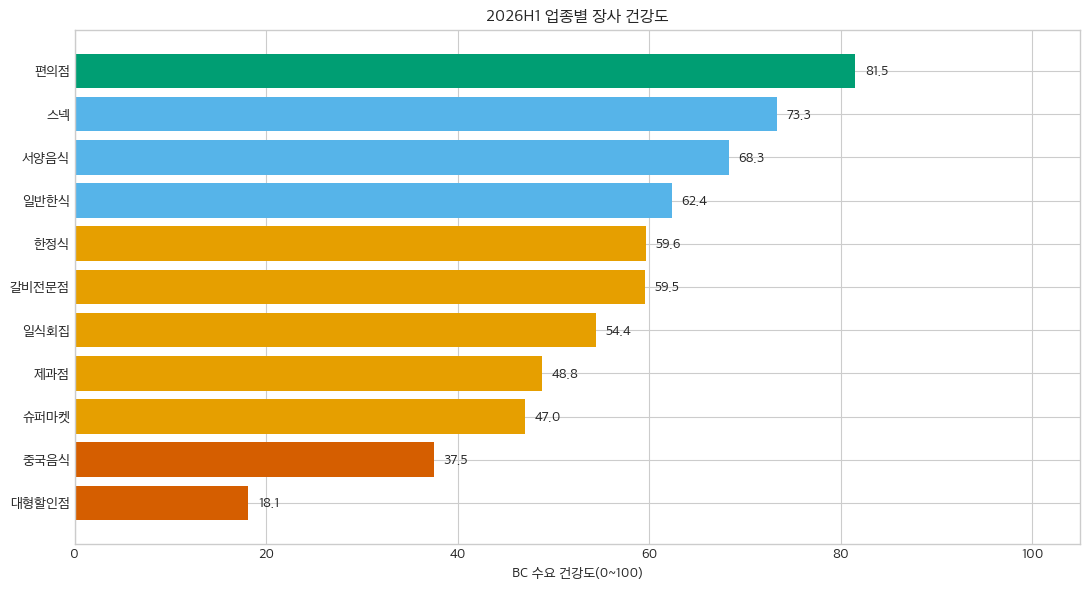

In [47]:
fig,ax=plt.subplots(figsize=(11,6))
plot=industry_trends.sort_values('weighted_business_health_score')
colors=['#d55e00' if v<40 else '#e69f00' if v<60 else '#56b4e9' if v<80 else '#009e73'
        for v in plot.weighted_business_health_score]
ax.barh(plot.TP_BUZ_NM,plot.weighted_business_health_score,color=colors)
for y,v in enumerate(plot.weighted_business_health_score): ax.text(v+1,y,f'{v:.1f}',va='center')
ax.set(xlim=(0,105),xlabel='BC 수요 건강도(0~100)',ylabel='',title='2026H1 업종별 장사 건강도')
plt.tight_layout(); plt.show()

### 성장을 `어떤 방식의 성장인가`로 나눈다

실질 AMT, CNT, 실질 건당금액의 방향을 결합해 수요·객단가 동반성장, 가성비·빈도성장, 프리미엄, 빈도증가·매출압력, 수요수축, 물가착시, 혼합으로 분류합니다. 건강도가 같아도 마케팅 행동은 달라야 합니다.

trend_type,ud504리미엄·고객단가,가성비·빈도성장,빈도증가·매출압력,수요·객단가 동반성장,수요수축
TP_BUZ_NM,,,,,
갈비전문점,3.700,48.800,3.700,26.800,17.100
대형할인점,0.000,7.600,15.700,2.500,74.100
서양음식,0.000,87.500,5.100,4.300,3.100
슈퍼마켓,0.000,52.200,31.000,9.000,7.800
스넥,1.200,38.400,0.800,54.900,4.700
일반한식,0.000,69.800,3.500,21.600,5.100
일식회집,0.400,60.200,17.500,8.900,13.000
제과점,0.000,55.500,24.400,5.900,14.200
중국음식,0.000,50.600,22.700,5.500,21.200


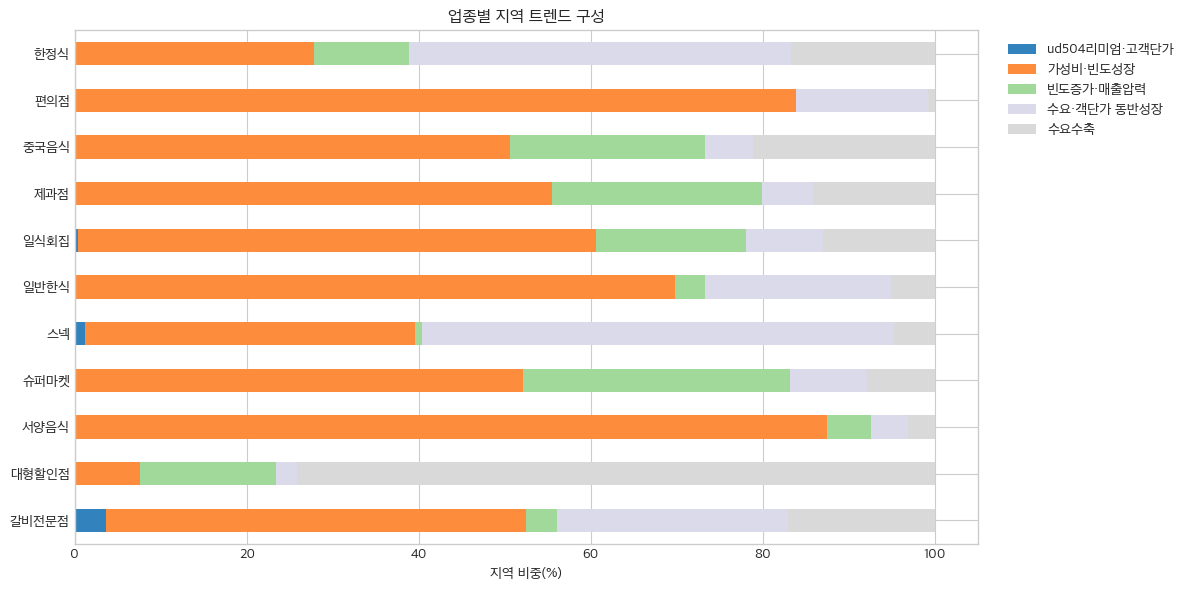

In [48]:
trend_mix=trend_panel.groupby(['TP_BUZ_NM','trend_type']).size().rename('n').reset_index()
trend_mix['region_pct']=trend_mix.n/trend_mix.groupby('TP_BUZ_NM').n.transform('sum')*100
display(trend_mix.pivot(index='TP_BUZ_NM',columns='trend_type',values='region_pct').fillna(0).round(1))

fig,ax=plt.subplots(figsize=(12,6))
trend_mix.pivot(index='TP_BUZ_NM',columns='trend_type',values='region_pct').fillna(0).plot.barh(stacked=True,ax=ax,colormap='tab20c')
ax.set(xlabel='지역 비중(%)',ylabel='',title='업종별 지역 트렌드 구성')
ax.legend(bbox_to_anchor=(1.02,1),loc='upper left'); plt.tight_layout(); plt.show()

### 11개 업종 트렌드 카드

외부 트렌드는 농림축산식품부·aT 보고서와 기업 공식 판매신호에서 가설을 가져오고, BC 결과와 분리해 저장합니다. 상품·메뉴·시간대 데이터가 없는 가설은 `검증필요`로 남겨 두었습니다.

In [49]:
display(marketing_cards[['TP_BUZ_NM','weighted_business_health_score','dominant_trend_type',
                         'fastest_growing_age_mode','external_trend','marketing_hypothesis',
                         'bc_verification_status']].sort_values('weighted_business_health_score',ascending=False))

,TP_BUZ_NM,weighted_business_health_score,dominant_trend_type,fastest_growing_age_mode,external_trend,marketing_hypothesis,bc_verification_status
0,편의점,81.525,가성비·빈도성장,60대 이상,근거리 식사·차별화 HMR·가성비 품질,식사대용·제과·협업상품 테스트,상품데이터 필요
1,스넥,73.345,수요·객단가 동반성장,60대 이상,초가성비·집밥경제,소액 다빈도·포장 묶음 가설,배달·포장 필요
2,서양음식,68.289,가성비·빈도성장,60대 이상,가치비·진정성 미식,시그니처 메뉴+입문가 메뉴 이중전략 가설,메뉴·가격 필요
3,일반한식,62.380,가성비·빈도성장,60대 이상,서바이벌 다이닝·K-푸드 투어,1인·가성비 정식과 외국인 메뉴 가설,BC외국인비중 검증가능
4,한정식,59.632,수요·객단가 동반성장,60대 이상,진정성 미식·K-푸드 체험,지역성·스토리·외국인 체험상품 가설,BC외국인비중 검증가능
5,갈비전문점,59.543,가성비·빈도성장,60대 이상,가성비&가치비·진정성 미식,세트가격과 원산지·품질 메시지 A/B 가설,메뉴·가격 필요
6,일식회집,54.432,가성비·빈도성장,60대 이상,가치비·진정성 미식,점심 가성비와 저녁 프리미엄 이중전략 가설,시간대·메뉴 필요
7,제과점,48.838,가성비·빈도성장,60대 이상,가성비+전문점 품질·편의점 제과 경쟁,베스트셀러 재해석·소용량·차별화 가설,외부채널 경쟁신호
8,슈퍼마켓,46.989,가성비·빈도성장,60대 이상,집밥경제·소용량 장보기,신선·반조리·소포장 묶음 가설,부분검증
9,중국음식,37.536,가성비·빈도성장,60대 이상,서바이벌 다이닝·올데이 올라운더,1인식·세트·포장 빈도 회복 가설,시간대·배달 필요


### 외부에서 확인한 `실제 마케팅 사례`를 연결한다

아래 전략은 만든 예시가 아니라 기업 공식 보도자료·보고서에서 실제 실행과 공개 성과를 확인한 사례입니다. 다만 다른 기업의 성과가 BC 표본 소상공인에서도 그대로 나온다고 단정하지 않습니다.

- `2026 직접`: BC 관찰기간과 같은 2026년에 공개된 실행·성과
- `2026 선행`: 2025년 말 실적으로 2026 전략 설계에 사용
- `선행 참고`: 이전 사례의 작동 방식만 참고

즉, `외부 사례 = 전략 가설`, `BC 추세 = 대상 선정`, `A/B 테스트 = 실제 효과 확인` 순서로 사용합니다.

In [50]:
actual_cases = pd.read_csv(EXT/'시장트렌드_2026'/'실제_마케팅_사례_근거표.csv')
actual_playbook = pd.read_csv(OUTPUT_DIR/'26_region_industry_actual_marketing_playbook.csv')

display(actual_cases[['case_id','case_period','evidence_period','brand','situation',
                      'actual_action','reported_result','source_type','caution']])
print('실제 사례:', len(actual_cases), '건 / 2026 직접:',
      actual_cases.evidence_period.eq('2026 직접').sum(), '건')

,case_id,case_period,evidence_period,brand,situation,actual_action,reported_result,source_type,caution
0,M01,2026-01,2026 직접,CU,가성비 수요는 있지만 저가 경쟁만으로는 차별화가 어려움,제과제빵 명장 협업·합리적 가격·전문점 수준 품질을 결합한 차별화 베이커리,2026년 1월 차별화 빵 매출 전년 동기 대비 30.5% 증가; 협업시리즈 10만...,기업 공식 성과수치,CU 자사 집계이며 전체 시장 성과는 아님
1,M02,2026-01,2026 직접,CU,SNS·방송에서 메뉴 관심이 급증했지만 유행 주기가 짧음,요리 경연프로그램 화제 메뉴를 셰프 협업 HMR로 빠르게 상품화,"선행 화제상품 밤 티라미수 예약판매 완판, 누적 250만개 판매",기업 공식 성과수치,기존 히트상품 성과와 신제품 성과를 구분해야 함
2,M03,2026-02,2026 직접,애슐리퀸즈,결제빈도가 정체되어 매월 재방문할 이유가 필요,매년 기다리는 대표 시즌 콘텐츠인 딸기축제를 시작하고 시즌별 메뉴·콘텐츠를 교체,2026년 딸기축제 시작 15일 만에 누적 방문객 약 120만 명,기업 공식 성과수치,대형 체인 성과를 소규모 점포에 그대로 적용하지 말 것
3,M04,2026-02,2026 직접,애슐리퀸즈,상권별 선호가 달라 전국 동일메뉴 확장이 위험,성수 상권에서 팝업 검증 후 시즌메뉴 선출시·평일 저녁/주말 주류 구성의 테스트베드...,"선행 팝업을 확장한 2026년 신규매장을 열고, 신메뉴·서비스 테스트베드로 운영",기업 공식 실행사례,실행 사례이며 신규매장의 장기 수익성 수치는 미공개
4,M05,2026-01~05,2026 직접,애슐리퀸즈,일회성 행사보다 지속적인 재방문 이유가 필요,"1월 체리, 2월 딸기, 3월 토마토, 4월 루비레드키위, 5월 썬골드키위로 월별 ...",공식 자료에서 월별 시즌을 방문 이유로 설계; 개별 월 매출은 미공개,기업 공식 실행사례,성과수치가 아니라 실행메커니즘 근거임
5,M06,2025-11,2026 선행,CU,매장 방문 한계로 고객접점과 구매빈도 확장이 필요,"쿠팡이츠 장보기에 배달·픽업 연결, 첫 구매 구간별 할인","2025년 1~11월 배달 매출 49.8%, 픽업 매출 48.5% 증가",기업 공식 성과수치,배달 매출 증가와 매장 이익 증가는 다름; 수수료를 반드시 반영
6,M07,2024-05,선행 참고,CU,가성비·다빈도 성장을 일회성 할인이 아닌 재방문으로 바꿔야 함,식단관리·실속한끼·간편식사·음료·커피 품목별 구독할인,"구독 이용건수가 2022년 119%, 2023년 143% 증가; 2개 이상 구독자 31%",기업 공식 성과수치,2026 직접 사례가 아닌 메커니즘 참고
7,M08,2023-02,선행 참고,CU,전국 일괄 캠페인보다 개별 점포의 단골·재고 상황에 맞는 CRM이 필요,점주가 스탬프·마감세일·타깃쿠폰·상품요청을 직접 운영하는 스토어플러스,포켓CU 리빌딩 후 활성회원 250만 명에서 350만 명으로 증가,기업 공식 실행·성과수치,플랫폼 회원 증가를 개별 캠페인 인과효과로 단정할 수 없음
8,M09,2024 실적/2025 보고,선행 참고,파리바게뜨,상품 만족도 문제가 재구매를 막지만 신제품 광고에 집중하고 있음,SNS 부정 피드백이 3회 이상 누적된 품목의 레시피·주입량·진열·취식가이드 개선,빵·케이크·샌드위치 11개 품목 개선 완료,기업 공식 보고서,개선 완료 건수이며 매출 증가 효과는 미공개
9,M10,2025-10,2026 선행,CU,건강 지향 고객을 잡으려는 광고는 있지만 구체적 제품 근거가 부족,파로·통밀·현미·저당소스 등 구체 원료로 구성한 건강 간편식 라인업,해당 연도 건강 간편식 시리즈 80만개 판매 후 하반기 추가 출시,기업 공식 성과수치,건강 메시지는 영양정보·표시 근거와 함께 사용


실제 사례: 10 건 / 2026 직접: 5 건


### BC 상황별로 `무엇을 마케팅할지`를 배정한다

지역×업종의 실질금액·건수·건당금액 방향으로 판별한 `trend_type`에 따라 실제 사례의 **작동 방식**을 연결했습니다. 예를 들어 가성비·빈도성장은 단순 쿠폰보다 `품질 근거가 있는 가격제안+재방문 제도`를, 수요수축은 `점포별 CRM+불만상품 개선`을 우선 실험합니다.

In [51]:
playbook_summary = (actual_playbook
    .groupby(['TP_BUZ_NM','trend_type','recommended_case_ids','case_selection_reason'], dropna=False)
    .agg(region_count=('CCG_NM','size'), median_health=('business_health_score','median'))
    .reset_index()
    .sort_values(['TP_BUZ_NM','region_count'], ascending=[True,False]))
display(playbook_summary)

# 실제 집행 대상은 상위/하위 구간을 보고 선정할 수 있습니다.
display(actual_playbook.sort_values('business_health_score').loc[:, [
    'SIDO_NM','CCG_NM','TP_BUZ_NM','trend_type','business_health_score',
    'recommended_case_ids','actual_case_actions','test_kpis','evidence_periods'
]].head(20))

assert len(actual_cases) == 10
assert actual_cases.source_url.str.startswith('https://').all()
assert len(actual_playbook) == len(trend_panel) == 2327
assert actual_playbook.recommended_case_ids.notna().all()
print('실제 마케팅 사례·BC 상황별 연결 검증을 통과했습니다.')

,TP_BUZ_NM,trend_type,recommended_case_ids,case_selection_reason,region_count,median_health
0,갈비전문점,가성비·빈도성장,M01|M07,가격할인만이 아닌 품질차별화·다빈도 제도화,40,60.000
2,갈비전문점,수요·객단가 동반성장,M03|M05,재방문 이유를 시즌화하고 상권별로 검증,22,80.000
3,갈비전문점,수요수축,M08|M09,점포별 CRM으로 재방문을 회복하고 품질문제를 개선,14,0.000
1,갈비전문점,빈도증가·매출압력,M07|M09,할인원가를 통제하고 부정피드백을 먼저 제거,3,40.000
4,갈비전문점,프리미엄·고객단가,M03|M04,시즌·체험으로 가치근거를 만들고 소규모 테스트,3,40.000
8,대형할인점,수요수축,M08|M09,점포별 CRM으로 재방문을 회복하고 품질문제를 개선,146,0.000
6,대형할인점,빈도증가·매출압력,M07|M09,할인원가를 통제하고 부정피드백을 먼저 제거,31,40.000
5,대형할인점,가성비·빈도성장,M01|M07,가격할인만이 아닌 품질차별화·다빈도 제도화,15,60.000
7,대형할인점,수요·객단가 동반성장,M03|M05,재방문 이유를 시즌화하고 상권별로 검증,5,80.000
9,서양음식,가성비·빈도성장,M01|M07,가격할인만이 아닌 품질차별화·다빈도 제도화,223,80.000


,SIDO_NM,CCG_NM,TP_BUZ_NM,trend_type,business_health_score,recommended_case_ids,actual_case_actions,test_kpis,evidence_periods
0,강원특별자치도,강릉시,대형할인점,수요수축,0.000,M08|M09,점주가 스탬프·마감세일·타깃쿠폰·상품요청을 직접 운영하는 스토어플러스 / SNS 부...,쿠폰 순증분효과|마감폐기율|재방문|단골 전환|부정리뷰 재발률|개선품 재구매|반품·폐...,선행 참고
1285,부산광역시,서구,대형할인점,수요수축,0.000,M08|M09,점주가 스탬프·마감세일·타깃쿠폰·상품요청을 직접 운영하는 스토어플러스 / SNS 부...,쿠폰 순증분효과|마감폐기율|재방문|단골 전환|부정리뷰 재발률|개선품 재구매|반품·폐...,선행 참고
1224,부산광역시,동구,대형할인점,수요수축,0.000,M08|M09,점주가 스탬프·마감세일·타깃쿠폰·상품요청을 직접 운영하는 스토어플러스 / SNS 부...,쿠폰 순증분효과|마감폐기율|재방문|단골 전환|부정리뷰 재발률|개선품 재구매|반품·폐...,선행 참고
1214,부산광역시,남구,대형할인점,수요수축,0.000,M08|M09,점주가 스탬프·마감세일·타깃쿠폰·상품요청을 직접 운영하는 스토어플러스 / SNS 부...,쿠폰 순증분효과|마감폐기율|재방문|단골 전환|부정리뷰 재발률|개선품 재구매|반품·폐...,선행 참고
1185,부산광역시,강서구,슈퍼마켓,수요수축,0.000,M08|M09,점주가 스탬프·마감세일·타깃쿠폰·상품요청을 직접 운영하는 스토어플러스 / SNS 부...,쿠폰 순증분효과|마감폐기율|재방문|단골 전환|부정리뷰 재발률|개선품 재구매|반품·폐...,선행 참고
1173,대전광역시,중구,대형할인점,수요수축,0.000,M08|M09,점주가 스탬프·마감세일·타깃쿠폰·상품요청을 직접 운영하는 스토어플러스 / SNS 부...,쿠폰 순증분효과|마감폐기율|재방문|단골 전환|부정리뷰 재발률|개선품 재구매|반품·폐...,선행 참고
1144,대전광역시,동구,대형할인점,수요수축,0.000,M08|M09,점주가 스탬프·마감세일·타깃쿠폰·상품요청을 직접 운영하는 스토어플러스 / SNS 부...,쿠폰 순증분효과|마감폐기율|재방문|단골 전환|부정리뷰 재발률|개선품 재구매|반품·폐...,선행 참고
1138,대전광역시,대덕구,갈비전문점,수요수축,0.000,M08|M09,점주가 스탬프·마감세일·타깃쿠폰·상품요청을 직접 운영하는 스토어플러스 / SNS 부...,쿠폰 순증분효과|마감폐기율|재방문|단골 전환|부정리뷰 재발률|개선품 재구매|반품·폐...,선행 참고
1134,대전광역시,대덕구,대형할인점,수요수축,0.000,M08|M09,점주가 스탬프·마감세일·타깃쿠폰·상품요청을 직접 운영하는 스토어플러스 / SNS 부...,쿠폰 순증분효과|마감폐기율|재방문|단골 전환|부정리뷰 재발률|개선품 재구매|반품·폐...,선행 참고
1096,대구광역시,북구,대형할인점,수요수축,0.000,M08|M09,점주가 스탬프·마감세일·타깃쿠폰·상품요청을 직접 운영하는 스토어플러스 / SNS 부...,쿠폰 순증분효과|마감폐기율|재방문|단골 전환|부정리뷰 재발률|개선품 재구매|반품·폐...,선행 참고


실제 마케팅 사례·BC 상황별 연결 검증을 통과했습니다.


### 폐업 위기 정보는 `확장 가드레일`로 사용한다

점수가 높은 지역에서도 개업·폐업이 동시에 높으면 무조건적 출점은 위험합니다. 폐업매핑이 정확한 제과점·중국음식의 고폐업 128개 지역만 별도 지원표로 만들었습니다.

- 고회전+수요취약: 신규출점 경고, 존속점 재방문·원가·임차료 진단
- 수요취약: 이탈 고객층 확인, 재방문 캠페인
- 고회전 교체시장: 0~3년차 점포 멘토링, 출점 시뮬레이션
- 고밀도 경쟁: 500m 경쟁도 공개, 시그니처·가격대 차별화
- 미설명: 알고리즘 판정보다 폐업자 직접 설문

In [52]:
display(closure_support.groupby(['연결업종','support_priority','closure_mechanism_candidate']).size()
        .rename('지역수').reset_index())
display(closure_support.head(20))

assert len(trend_panel)==2327 and len(industry_trends)==11 and len(marketing_cards)==11
assert len(closure_support)==128 and trend_panel.health_evidence_count.between(1,5).all()
assert round(industry_trends.set_index('TP_BUZ_NM').loc['편의점','weighted_business_health_score'],1)==81.5
print('업종별 트렌드·장사 건강도·폐업지원표 검증을 통과했습니다.')

,연결업종,support_priority,closure_mechanism_candidate,지역수
0,제과점,1_즉시진단,고회전+수요취약 후보,11
1,제과점,1_즉시진단,수요취약 후보,3
2,제과점,2_차별화지원,고밀도 경쟁 후보,5
3,제과점,2_초기점포지원,고회전 교체시장 후보,31
4,제과점,3_원인조사,관측변수로 미설명,14
5,중국음식,1_즉시진단,고회전+수요취약 후보,9
6,중국음식,1_즉시진단,수요취약 후보,15
7,중국음식,2_차별화지원,고밀도 경쟁 후보,2
8,중국음식,2_초기점포지원,고회전 교체시장 후보,21
9,중국음식,3_원인조사,관측변수로 미설명,17


,SIDO_NM,CCG_NM,TP_BUZ_NO,연결업종,closure_rate_6m_pct,opening_rate_6m_pct,amt_growth_pct_m,cnt_growth_pct_m,closure_mechanism_candidate,business_health_score,business_health_grade,trend_type,fastest_growing_age,support_priority,recommended_support
0,인천광역시,미추홀구,8301,제과점,22.430,22.430,-2.086,-0.153,고회전+수요취약 후보,0.000,위축·즉시점검,수요수축,20대,1_즉시진단,신규출점 경고+존속점 재방문·원가·임차료 진단
1,서울특별시,중구,8301,제과점,18.239,21.384,-2.583,-1.561,고회전+수요취약 후보,0.000,위축·즉시점검,수요수축,50대,1_즉시진단,신규출점 경고+존속점 재방문·원가·임차료 진단
2,서울특별시,용산구,8301,제과점,17.722,14.557,-1.726,0.283,고회전+수요취약 후보,20.000,위축·즉시점검,빈도증가·매출압력,60대 이상,1_즉시진단,신규출점 경고+존속점 재방문·원가·임차료 진단
3,서울특별시,서초구,8301,제과점,16.598,16.183,-1.025,0.848,고회전+수요취약 후보,40.000,관찰·선별개선,빈도증가·매출압력,60대 이상,1_즉시진단,신규출점 경고+존속점 재방문·원가·임차료 진단
4,경기도,파주시,8301,제과점,15.607,17.341,-1.368,0.326,고회전+수요취약 후보,20.000,위축·즉시점검,빈도증가·매출압력,60대 이상,1_즉시진단,신규출점 경고+존속점 재방문·원가·임차료 진단
5,서울특별시,강남구,8301,제과점,15.466,13.983,-1.057,0.538,고회전+수요취약 후보,20.000,위축·즉시점검,빈도증가·매출압력,60대 이상,1_즉시진단,신규출점 경고+존속점 재방문·원가·임차료 진단
6,전북특별자치도,김제시,8301,제과점,14.286,4.762,-2.345,-0.796,수요취약 후보,0.000,위축·즉시점검,수요수축,60대 이상,1_즉시진단,고객이탈 세그먼트 확인+재방문 캠페인
7,경기도,고양시 일산서구,8301,제과점,13.095,17.857,-1.497,0.673,고회전+수요취약 후보,20.000,위축·즉시점검,빈도증가·매출압력,60대 이상,1_즉시진단,신규출점 경고+존속점 재방문·원가·임차료 진단
8,경기도,수원시 장안구,8301,제과점,13.095,19.048,-1.232,0.766,고회전+수요취약 후보,20.000,위축·즉시점검,빈도증가·매출압력,60대 이상,1_즉시진단,신규출점 경고+존속점 재방문·원가·임차료 진단
9,경기도,의정부시,8301,제과점,12.048,13.855,-1.802,0.372,고회전+수요취약 후보,20.000,위축·즉시점검,빈도증가·매출압력,60대 이상,1_즉시진단,신규출점 경고+존속점 재방문·원가·임차료 진단


업종별 트렌드·장사 건강도·폐업지원표 검증을 통과했습니다.


## 10. 점포단위 폐업 압력: 업력·규모·경쟁·지역맥락

여기서부터는 BC 업종과 행정 인허업종이 **HIGH 신뢰도로 정확히 연결되는 제과점과 중국음식**만 분석합니다. 2026년 1월 1일 직전 영업중이던 점포를 위험집합으로 고정하고, 6월 30일까지 폐업 여부를 봅니다.

이 분석이 답하는 것은 `어떤 특성의 점포군에서 폐업이 더 자주 관찰됐는가?`입니다. 사업자 설문·재무제표가 없으므로 `왜 폐업했는가?`를 인과적으로 답하지는 않습니다.

In [53]:
# 비식별화된 고정 캐시 로딩: 대용량 CP949 원본을 매번 읽지 않습니다.
STORE_CACHE = EXT/'재현용_가공패널'/'폐업원인_정확업종_점포이벤트패널.csv'
RISK_CACHE = EXT/'재현용_가공패널'/'폐업원인_정확업종_2026H1위험집합.csv'

stores = pd.read_csv(STORE_CACHE, parse_dates=['open_date','close_date'])
store_risk = pd.read_csv(RISK_CACHE, parse_dates=['open_date','close_date'])
store_risk['closed_h1'] = store_risk.closed_h1.astype(str).str.lower().eq('true')

coverage = pd.DataFrame({
    '검증항목':['점포이벤트','2026-01-01 영업중 위험집합','2026H1 폐업','시군구 연결률','좌표 입력률'],
    '결과':[len(stores),len(store_risk),int(store_risk.closed_h1.sum()),
          f"{store_risk.SIDO_NM.notna().mean()*100:.1f}%",f"{store_risk.x.notna().mean()*100:.1f}%"]})
display(coverage)
display(store_risk.groupby('industry').agg(위험집합=('store_id','size'),폐업=('closed_h1','sum')).reset_index())

,검증항목,결과
0,점포이벤트,143116
1,2026-01-01 영업중 위험집합,45904
2,2026H1 폐업,1974
3,시군구 연결률,100.0%
4,좌표 입력률,96.4%


,industry,위험집합,폐업
0,제과점,19667,1034
1,중국음식,26237,940


### 10-1. 업력이 짧은 점포에서 폐업 압력이 더 크다

분모를 `상반기 중 한 번이라도 영업한 점포`로 잡으면 중도진입 편향이 생깁니다. 따라서 1월 1일의 영업점만 먼저 고정합니다. 비율에는 Wilson 95% 구간을 붙여 작은 표본의 과대해석을 막습니다.

,industry,tenure_band,at_risk_jan1,closures_h1,closure_rate_6m_pct,wilson95_low,wilson95_high
0,제과점,1년미만,2278,184,8.077,7.028,9.268
1,제과점,1~3년,3251,251,7.721,6.852,8.689
2,제과점,3~5년,2498,154,6.165,5.287,7.177
3,제과점,5~10년,4068,196,4.818,4.202,5.520
4,제과점,10년+,7572,249,3.288,2.910,3.714
5,중국음식,1년미만,1748,100,5.721,4.726,6.910
6,중국음식,1~3년,3513,197,5.608,4.894,6.418
7,중국음식,3~5년,3273,168,5.133,4.428,5.943
8,중국음식,5~10년,5055,177,3.501,3.029,4.045
9,중국음식,10년+,12648,298,2.356,2.106,2.635


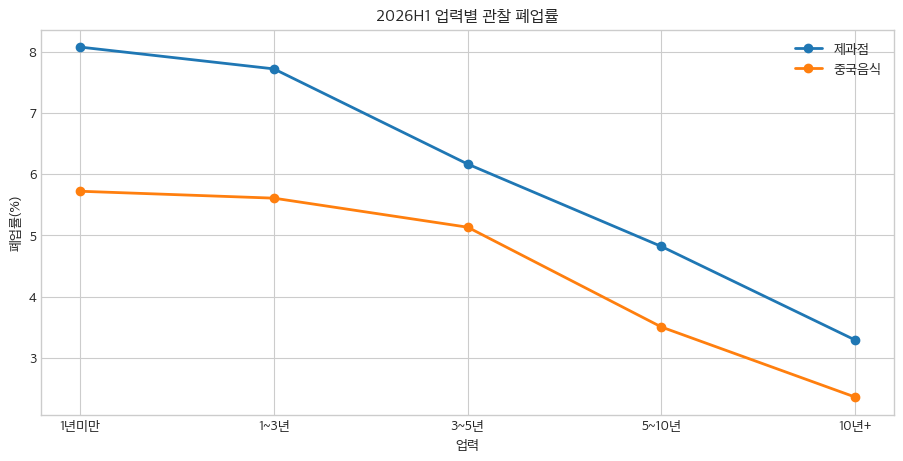

In [54]:
def wilson_interval(events, n, z=1.96):
    p=events/n; den=1+z*z/n
    center=(p+z*z/(2*n))/den
    half=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/den
    return (center-half)*100,(center+half)*100

tenure_order=['1년미만','1~3년','3~5년','5~10년','10년+']
store_risk['tenure_band']=pd.cut(store_risk.tenure_start_years,[-1,1,3,5,10,np.inf],
                                 labels=tenure_order,right=False)
rows=[]
for (industry,band),g in store_risk.groupby(['industry','tenure_band'],observed=False):
    n=len(g); e=int(g.closed_h1.sum()); lo,hi=wilson_interval(e,n)
    rows.append({'industry':industry,'tenure_band':str(band),'at_risk_jan1':n,
                 'closures_h1':e,'closure_rate_6m_pct':e/n*100,
                 'wilson95_low':lo,'wilson95_high':hi})
tenure_result=pd.DataFrame(rows)
tenure_result.to_csv(OUTPUT_DIR/'16_exact_industry_tenure_closure_rate.csv',index=False,encoding='utf-8-sig')
display(tenure_result)

fig,ax=plt.subplots()
for industry,g in tenure_result.groupby('industry'):
    g=g.set_index('tenure_band').loc[tenure_order].reset_index()
    ax.plot(g.tenure_band,g.closure_rate_6m_pct,marker='o',linewidth=2,label=industry)
ax.set(title='2026H1 업력별 관찰 폐업률',xlabel='업력',ylabel='폐업률(%)')
ax.legend(); plt.show()

**결과:** 제과점은 1년 미만 8.08%에서 10년 이상 3.29%로, 중국음식은 5.72%에서 2.36%로 낮아집니다. 두 업종 모두 초기 1~3년 구간의 생존관리가 우선이라는 현상은 붤명합니다. 다만 업력이 짧은 점포의 규모·자본·입지가 다를 수 있으므로 업력 자체의 인과효과는 아닙니다.

### 10-2. 작은 점포와 진입이 많은 근거리에서 폐업이 더 자주 관찰된다

시설규모와 500m 내 동종점 수를 각 업종 내 4분위로 나눅니다. 이는 절대 임계치가 아니라 동일업종 내 상대비교입니다.

,industry,metric,quartile,n,closures,metric_median,closure_rate_6m_pct,wilson95_low,wilson95_high
0,제과점,시설규모,Q1,4924,424,21.675,8.611,7.859,9.427
1,제과점,시설규모,Q2,4910,280,41.960,5.703,5.088,6.387
2,제과점,시설규모,Q3,4916,182,70.625,3.702,3.209,4.267
3,제과점,시설규모,Q4,4917,148,122.600,3.010,2.568,3.525
4,제과점,500m동종점,Q1,4898,219,1.000,4.471,3.927,5.087
5,제과점,500m동종점,Q2,4776,237,4.000,4.962,4.382,5.615
6,제과점,500m동종점,Q3,5124,258,7.000,5.035,4.469,5.668
7,제과점,500m동종점,Q4,4133,270,15.000,6.533,5.819,7.327
8,중국음식,시설규모,Q1,6561,316,33.700,4.816,4.324,5.361
9,중국음식,시설규모,Q2,6581,246,62.000,3.738,3.306,4.224


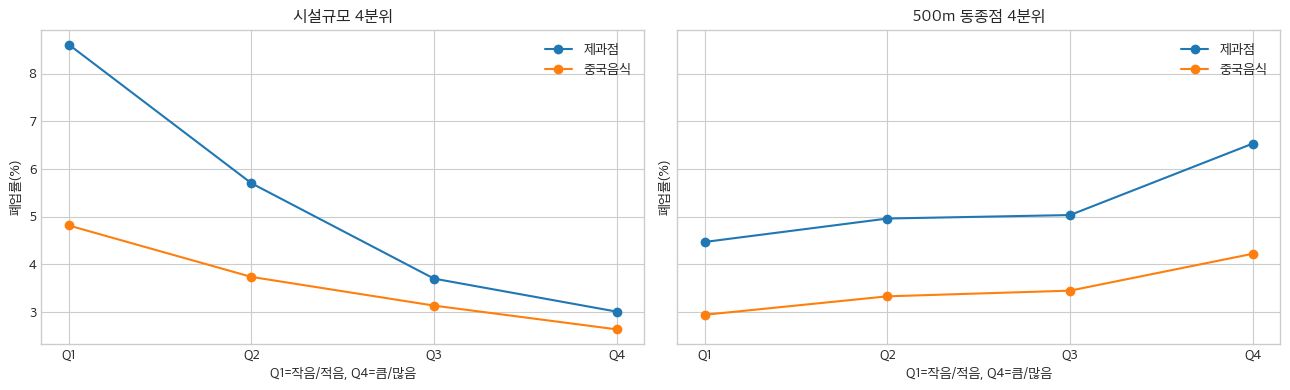

In [55]:
def structure_quartiles(frame):
    rows=[]
    specs={'facility_area_m2':'시설규모','competitors_500m':'500m동종점','entrants_500m_h1':'500m신규점'}
    for industry,part in frame.groupby('industry'):
        for col,label in specs.items():
            q=part[[col,'closed_h1']].dropna().query(f'{col} >= 0').copy()
            try:
                q['quartile']=pd.qcut(q[col],4,labels=['Q1','Q2','Q3','Q4'],duplicates='drop')
            except ValueError:
                # 예: 신규점수가 대부분 0이면 4개 구간이 만들어지지 않음
                continue
            for quartile,g in q.groupby('quartile',observed=True):
                n=len(g); e=int(g.closed_h1.sum()); lo,hi=wilson_interval(e,n)
                rows.append({'industry':industry,'metric':label,'quartile':str(quartile),'n':n,
                             'closures':e,'metric_median':g[col].median(),
                             'closure_rate_6m_pct':e/n*100,'wilson95_low':lo,'wilson95_high':hi})
    return pd.DataFrame(rows)

structure_result=structure_quartiles(store_risk)
structure_result.to_csv(OUTPUT_DIR/'18_store_structure_closure_rate.csv',index=False,encoding='utf-8-sig')
display(structure_result)

fig,axes=plt.subplots(1,2,figsize=(13,4),sharey=True)
for ax,(metric,title) in zip(axes,[('시설규모','시설규모 4분위'),('500m동종점','500m 동종점 4분위')]):
    for industry,g in structure_result[structure_result.metric.eq(metric)].groupby('industry'):
        ax.plot(g.quartile,g.closure_rate_6m_pct,marker='o',label=industry)
    ax.set(title=title,xlabel='Q1=작음/적음, Q4=큼/많음',ylabel='폐업률(%)'); ax.legend()
plt.tight_layout(); plt.show()

**결과:** 시설규모 Q1→Q4의 폐업률은 제과점 8.61%→3.01%, 중국음식 4.82%→2.64%입니다. 500m 동종점 Q1→Q4는 제과점 4.47%→6.53%, 중국음식 2.94%→4.22%입니다. 규모가 작고 근거리 동종점이 많은 점포군을 점검 우선으로 볼 수 있지만, 매출·원가·자본금이 없어 원인은 단정할 수 없습니다.

### 10-3. 신규 인허는 팝업·단기영업을 분리해서 본다

2026H1 제과점 신규 인허에는 0~3.3m² 규모의 백화점 팝업·단기 판매 인허가 다수 섞여 있습니다. 따라서 전체 인허의 생존곡선과, 사전적 기준인 `시설 10m² 이상` 민감도를 같이 계산합니다. 10m² 기준은 임시점을 완벽히 구분하지는 못합니다.

,industry,cohort,horizon_days,entrants_h1,observed_events_h1,at_risk_at_horizon,km_survival_pct,km_closure_pct
0,제과점,전체 인허가,30,1957,651,1137,67.951,32.049
2,제과점,전체 인허가,90,1957,651,648,63.941,36.059
4,제과점,전체 인허가,150,1957,651,185,63.031,36.969
5,제과점,시설 10m2 이상,30,1262,90,989,93.870,6.130
7,제과점,시설 10m2 이상,90,1262,90,596,92.271,7.729
9,제과점,시설 10m2 이상,150,1262,90,174,91.292,8.708
10,중국음식,전체 인허가,30,1030,48,839,96.387,3.613
12,중국음식,전체 인허가,90,1030,48,486,94.953,5.047
14,중국음식,전체 인허가,150,1030,48,144,94.396,5.604
15,중국음식,시설 10m2 이상,30,934,26,777,97.840,2.160


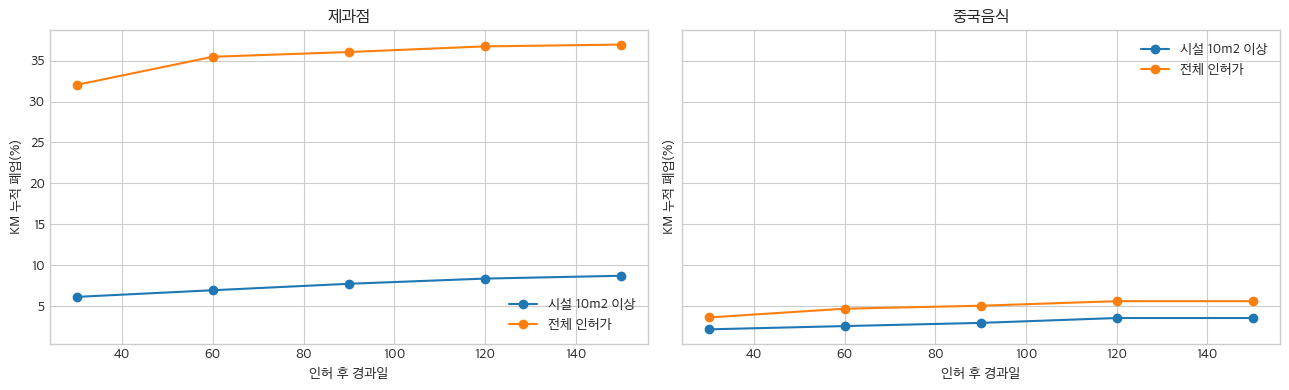

In [56]:
def entrant_km(frame):
    end=pd.Timestamp('2026-06-30'); entrants=frame[frame.open_date.between('2026-01-01',end)]
    rows=[]; cohorts={'전체 인허가':lambda x:pd.Series(True,index=x.index),
                     '시설 10m2 이상':lambda x:x.facility_area_m2.ge(10)}
    for industry,source in entrants.groupby('industry'):
        for cohort,selector in cohorts.items():
            g=source.loc[selector(source)].copy(); event=g.close_date.notna()&g.close_date.le(end)
            duration=(g.close_date.where(event,end)-g.open_date).dt.days.clip(lower=0)
            survival=1.; curve=[]
            for t in sorted(duration[event].unique()):
                n=int((duration>=t).sum()); e=int(((duration==t)&event).sum())
                survival*=1-e/n; curve.append((t,survival))
            for horizon in [30,60,90,120,150]:
                values=[s for t,s in curve if t<=horizon]; s=values[-1] if values else 1.
                rows.append({'industry':industry,'cohort':cohort,'horizon_days':horizon,
                             'entrants_h1':len(g),'observed_events_h1':int(event.sum()),
                             'at_risk_at_horizon':int((duration>=horizon).sum()),
                             'km_survival_pct':s*100,'km_closure_pct':(1-s)*100})
    return pd.DataFrame(rows)

km_result=entrant_km(stores)
km_result.to_csv(OUTPUT_DIR/'17_new_store_km_survival.csv',index=False,encoding='utf-8-sig')
display(km_result[km_result.horizon_days.isin([30,90,150])])

fig,axes=plt.subplots(1,2,figsize=(13,4),sharey=True)
for ax,(industry,g0) in zip(axes,km_result.groupby('industry')):
    for cohort,g in g0.groupby('cohort'):
        ax.plot(g.horizon_days,g.km_closure_pct,marker='o',label=cohort)
    ax.set(title=industry,xlabel='인허 후 경과일',ylabel='KM 누적 폐업(%)'); ax.legend()
plt.tight_layout(); plt.show()

**중요한 품질 판정:** 제과점 전체 인허의 30일 KM 누적 폐업은 32.05%이지만, 10m² 이상으로 제한하면 6.13%로 낮아집니다. 이는 신규 제과점이 모두 실패한 것이 아니라, LOCALDATA 인허에 단기영업이 다수 포함된다는 뜻입니다. 발표에서는 전체 수치 하나만 떼어내서 사용하면 안 됩니다.

### 10-4. 고폐업 지역을 고회전·수요취약·고밀도로 나눈다

업종 내 폐업률 상위 25%를 먼저 고르고, 동시에 개업률 상위 25%인지, AMT 성장이 하위 25%인지, 기초점포수가 상위 25%인지로 후보 유형을 분리합니다. 절대적 진단이 아니라 업종 내 상대 우선순위입니다.

In [57]:
typology = pd.read_csv(EXT/'재현용_가공패널'/'폐업예측_검증데이터.csv')
typology = typology[typology.confidence.eq('HIGH') & typology['연결업종'].isin(['제과점','중국음식'])].copy()
by_industry=typology.groupby('연결업종')
for col in ['closure_rate_6m_pct','opening_rate_6m_pct','amt_growth_pct_m','cnt_growth_pct_m','initial_stores']:
    typology[col+'_pctile']=by_industry[col].rank(pct=True)
typology['high_closure']=typology.closure_rate_6m_pct_pctile.ge(.75)
typology['high_entry']=typology.opening_rate_6m_pct_pctile.ge(.75)
typology['weak_amt']=typology.amt_growth_pct_m_pctile.le(.25)
typology['weak_cnt']=typology.cnt_growth_pct_m_pctile.le(.25)
typology['dense_market']=typology.initial_stores_pctile.ge(.75)
typology['closure_mechanism_candidate']=np.select([
    typology.high_closure&typology.high_entry&typology.weak_amt,
    typology.high_closure&typology.high_entry&~typology.weak_amt,
    typology.high_closure&~typology.high_entry&typology.weak_amt,
    typology.high_closure&~typology.high_entry&~typology.weak_amt&typology.dense_market,
    typology.high_closure],
    ['고회전+수요취약 후보','고회전 교체시장 후보','수요취약 후보','고밀도 경쟁 후보','관측변수로 미설명'],default='일반 관찰지역')
typology.to_csv(OUTPUT_DIR/'19_exact_industry_closure_mechanism_typology.csv',index=False,encoding='utf-8-sig')
high_typology=(typology[typology.high_closure]
               .groupby(['연결업종','closure_mechanism_candidate']).size()
               .unstack(fill_value=0))
display(high_typology)

closure_mechanism_candidate,고밀도 경쟁 후보,고회전 교체시장 후보,고회전+수요취약 후보,관측변수로 미설명,수요취약 후보
연결업종,,,,,
제과점,5,31,11,14,3
중국음식,2,21,9,17,15


### 10-5. 소비·임대료가 점포 폐업을 추가로 설명하는지 지역분리 검증

같은 시군구가 train과 test에 동시에 들어가지 않도록 GroupKFold를 적용합니다. 모형 A는 업력, B는 업력+시설규모+근거리 경쟁+신규진입, C는 B+지역 BC소비+주민인구 보정, D는 C+시도 소규모상가 임대료·공실률입니다.

,industry,model,n,closures,group_cv_roc_auc,group_cv_average_precision,baseline_closure_rate
0,제과점,A_업력,19667,1034,0.611,0.077,0.053
1,제과점,B_점포구조,19667,1034,0.656,0.119,0.053
2,제과점,C_점포+소비,19667,1034,0.652,0.117,0.053
3,제과점,D_점포+소비+시도임대,19667,1034,0.649,0.115,0.053
4,중국음식,A_업력,26237,940,0.615,0.051,0.036
5,중국음식,B_점포구조,26237,940,0.628,0.061,0.036
6,중국음식,C_점포+소비,26237,940,0.632,0.062,0.036
7,중국음식,D_점포+소비+시도임대,26237,940,0.632,0.063,0.036


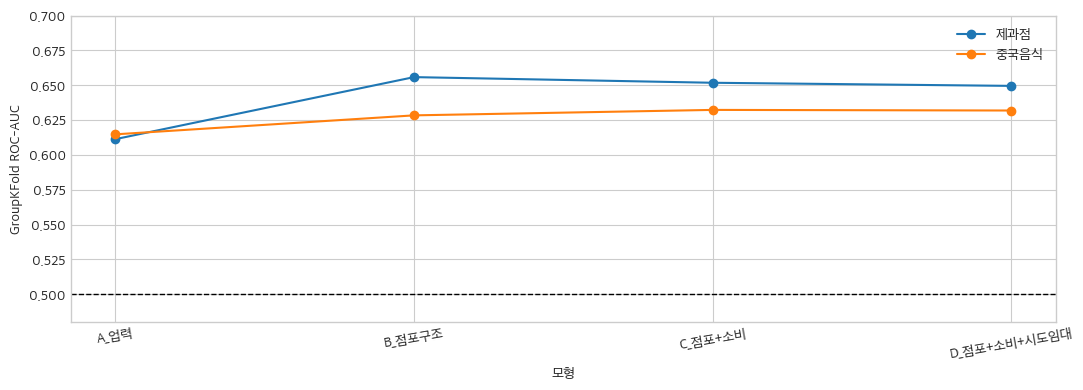

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
warnings.filterwarnings('ignore',category=RuntimeWarning,module=r'sklearn\..*')

model_frame=store_risk.copy()
for source,target in {'tenure_start_years':'log_tenure_start_years','facility_area_m2':'log_facility_area_m2',
                      'competitors_500m':'log_competitors_500m','entrants_500m_h1':'log_entrants_500m_h1'}.items():
    model_frame[target]=np.log1p(pd.to_numeric(model_frame[source],errors='coerce').clip(lower=0))
feature_sets={
 'A_업력':['log_tenure_start_years'],
 'B_점포구조':['log_tenure_start_years','log_facility_area_m2','log_competitors_500m','log_entrants_500m_h1'],
 'C_점포+소비':['log_tenure_start_years','log_facility_area_m2','log_competitors_500m','log_entrants_500m_h1',
             'amt_growth_pct_m','cnt_growth_pct_m','ticket_growth_pct_m','benchmark_adjusted_gap_pct_m'],
 'D_점포+소비+시도임대':['log_tenure_start_years','log_facility_area_m2','log_competitors_500m','log_entrants_500m_h1',
             'amt_growth_pct_m','cnt_growth_pct_m','ticket_growth_pct_m','benchmark_adjusted_gap_pct_m',
             'reb_rent_1000won_m2_2026Q2','reb_rent_1000won_m2_qoq_change',
             'reb_vacancy_rate_pct_2026Q2','reb_vacancy_rate_pct_qoq_change']}

metric_rows=[]; coefficient_rows=[]
for industry,part in model_frame.groupby('industry'):
    valid=part.SIDO_NM.notna()&part.CCG_NM.notna(); y=part.loc[valid,'closed_h1'].astype(int)
    groups=part.loc[valid,'SIDO_NM'].astype(str)+'|'+part.loc[valid,'CCG_NM'].astype(str)
    for model_name,cols in feature_sets.items():
        x=part.loc[valid,cols].replace([np.inf,-np.inf],np.nan)
        pipe=make_pipeline(SimpleImputer(strategy='median'),StandardScaler(),
                           LogisticRegression(max_iter=2000,class_weight='balanced',solver='liblinear',random_state=42))
        pred=cross_val_predict(pipe,x,y,groups=groups,cv=GroupKFold(5),method='predict_proba')[:,1]
        metric_rows.append({'industry':industry,'model':model_name,'n':len(x),'closures':int(y.sum()),
                            'group_cv_roc_auc':roc_auc_score(y,pred),
                            'group_cv_average_precision':average_precision_score(y,pred),
                            'baseline_closure_rate':y.mean()})
        pipe.fit(x,y)
        for feature,beta in zip(cols,pipe.named_steps['logisticregression'].coef_[0]):
            coefficient_rows.append({'industry':industry,'model':model_name,'feature':feature,
                                     'standardized_log_odds':beta,'odds_ratio_per_1sd':np.exp(beta)})

store_model_metrics=pd.DataFrame(metric_rows)
store_model_coefficients=pd.DataFrame(coefficient_rows)
store_model_metrics.to_csv(OUTPUT_DIR/'20_store_closure_groupcv_metrics.csv',index=False,encoding='utf-8-sig')
store_model_coefficients.to_csv(OUTPUT_DIR/'21_store_closure_association_coefficients.csv',index=False,encoding='utf-8-sig')
display(store_model_metrics)

fig,ax=plt.subplots(figsize=(11,4))
for industry,g in store_model_metrics.groupby('industry'):
    ax.plot(g.model,g.group_cv_roc_auc,marker='o',label=industry)
ax.axhline(.5,color='black',linestyle='--',linewidth=1); ax.set(ylabel='GroupKFold ROC-AUC',xlabel='모형',ylim=(.48,.70))
ax.tick_params(axis='x',rotation=10); ax.legend(); plt.tight_layout(); plt.show()

**결론:** 제과점은 업력 AUC 0.611에서 점포구조 0.656으로 개선되지만, 소비를 더하면 0.652, 시도 임대맥락까지 더하면 0.649로 낮아집니다. 중국음식은 0.615→0.628→0.632→0.632입니다. 즉 **업력·규모·근거리 진입은 연관 신호가 있지만, 지역 BC소비와 시도 임대료는 폐업사유를 뚜렷하게 복원하지 못했습니다.**

따라서 발표에서 사용할 수 있는 표현은 `초기·소규모·진입압력 점포군에서 폐업 압력이 높게 관찰됐다`까지입니다. `소비감소 또는 임대료가 폐업을 유발했다`는 표현은 사용하지 않습니다.

### 명확한 폐업사유를 밝히려면 추가로 필요한 정보

1. 폐업자 직접 설문: 중복응답 가능한 폐업사유·최종 영업월·이전·업종전환 여부
2. 점포별 재무: 매출, 매출총이익, 원가, 인건비, 임차료, 대출·체납
3. 가게 계약·입지: 임대차 갱신일, 실제 월세·보증금, 층·전용면적, 유동인구·배달비중
4. 정책·상권 충격: 재개발, 공사, 프랜차이즈 계약해지, 지역별 지원금 수혜

이 자료가 추가되면 `점포×월` 패널을 만들고 폐업 직전 3~12개월의 변화를 비폐업 매칭점과 비교하는 생존분석·이벤트 스터디로 넘어갈 수 있습니다.

In [59]:
# 추가 분석 재현 검증
assert len(stores)==143116 and len(store_risk)==45904
assert int(store_risk.closed_h1.sum())==1974
assert len(tenure_result)==10 and len(km_result)==20 and len(structure_result)==16
assert len(typology)==509 and len(store_model_metrics)==8

key=tenure_result.set_index(['industry','tenure_band']).closure_rate_6m_pct
assert round(key['제과점','1년미만'],2)==8.08 and round(key['제과점','10년+'],2)==3.29
assert round(key['중국음식','1년미만'],2)==5.72 and round(key['중국음식','10년+'],2)==2.36
best=store_model_metrics.groupby('industry').group_cv_roc_auc.max()
assert round(best['제과점'],3)==.656 and round(best['중국음식'],3)==.632
print('점포단위 폐업 압력 분석 재현 검증을 통과했습니다.')

점포단위 폐업 압력 분석 재현 검증을 통과했습니다.


## 11. 재현 검증과 최종 결론

다음 셀은 단순히 에러 없이 돌았는지만 보지 않습니다. 15개 표의 행 수, 핵심 업종 결과, 상관계수, 소비층 이동이 기준 결과와 일치하는지 assert로 검증합니다.


In [60]:
expected_rows = [1009,11552,2327,2388,30,22254,2133,2323,2327,2366,10,2327,2327,2327,2388]
actual_rows = [len(v) for v in outputs.values()]
assert actual_rows == expected_rows, (actual_rows, expected_rows)
assert sum(actual_rows) == 58088

stability = outputs['09_growth_stability']
conv = stability[stability.TP_BUZ_NM.eq('편의점')]
discount = stability[stability.TP_BUZ_NM.eq('대형할인점')]
assert round((conv.stability_type.eq('안정성장')).mean()*100,1) == 70.2
assert round((discount.stability_type.eq('안정감소')).mean()*100,1) == 43.1

sc = outputs['04_supply_specialization_closure_pressure']
high = sc[(sc.mapping_confidence.eq('HIGH')) & sc.supply_closure_type.eq('고특화·고폐업압력')].groupby('TPBUZ_NM').size()
assert int(high['제과점']) == 27 and int(high['중국음식']) == 14

age60 = outputs['06_consumer_segment_shift']
age60 = age60[(age60.dimension.eq('AGE_CD')) & age60.segment.eq('60대 이상')].groupby('TP_BUZ_NM').cnt_share_change_pp.median()
assert round(age60['슈퍼마켓'],2) == 2.55 and round(age60['일반한식'],2) == 2.54

display(pd.DataFrame({'check':['15개 분석','출력 58,088행','편의점 안정성장 70.2%','대형할인점 안정감소 43.1%','제과점/중국음식 폐업압력','60대 이상 소비비중 이동'],
                      'passed':[len(outputs)==15,sum(actual_rows)==58088,True,True,True,True]}))
print('모든 재현 검증을 통과했습니다.')


,check,passed
0,15개 분석,True
1,"출력 58,088행",True
2,편의점 안정성장 70.2%,True
3,대형할인점 안정감소 43.1%,True
4,제과점/중국음식 폐업압력,True
5,60대 이상 소비비중 이동,True


모든 재현 검증을 통과했습니다.


### 발표용 핵심 메시지

1. **편의점은 가장 안정적인 성장형**, **대형할인점은 가장 분명한 안정감소형**입니다.
2. 다수 업종에서 국내개인 소비구성이 **60대 이상으로 이동**했습니다.
3. **제과점과 중국음식**은 현재 공급특화도와 폐업압력을 함께 봐야 하는 핵심 업종입니다.
4. 제과점은 고변동이면서 법인결제 비중도 가장 높아 개인소비만으로 설명하면 안 됩니다.
5. 대형할인점–슈퍼마켓–편의점은 지역 점유율 이동이 반대로 나타나는 대체관계 후보입니다.
6. 폐업은 소비 원인을 증명하거나 점포를 예측하는 값이 아니라, **소비 진단 후 경영점검 우선순위를 정하는 외부 압력지표**입니다.

이 분석의 가능한 주장은 “해당 지역×업종에서 소비약화와 폐업압력이 동시에 관찰됐다”까지입니다. “소비감소가 폐업을 유발했다”나 “특정 점포가 폐업할 것이다”는 주장하지 않습니다.
